# Overview

Downloading Paper:

In [ ]:
!wget https://arxiv.org/pdf/1705.01613

In [ ]:
!pip install PyPDF2

In [ ]:
import PyPDF2

with open('1705.01613', 'rb') as pdf_file:
    pdf_reader = PyPDF2.PdfReader(pdf_file)
    text = ''
    for page_num in range(len(pdf_reader.pages)):
        page = pdf_reader.pages[page_num]
        text += page.extract_text()

print(text)



**CREDBANK dataset**

Will be used for training.

[Kaggle](https://www.kaggle.com/datasets/fabliha6459345398/credbank-dataset)

**PHEME dataset**

Will be used for training.

[Figshare](https://figshare.com/articles/dataset/PHEME_dataset_of_rumours_and_non-rumours/4010619?file=6453753)

**BuzzFeed-Webis Fake News Corpus 2016 dataset**

Will be used for testing.

[Zenodo](https://zenodo.org/records/1239675)

# Installing Requirements

Downloading requirements

In [1]:
!pip install sweetviz emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 590.6/590.6 kB 31.1 MB/s eta 0:00:00


# Setting Up Google Drive

We need 13GB of free space (or use "**Loading Features**" cells to load CSV files from google drive directly, skipping "Loading", "Reading" and "Saving Features")

In [2]:
import os

In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


The folders that this notebook uses:

In [4]:
# Define the output directory in Google Drive
gdrive_pheme_dir = '/content/drive/MyDrive/fake_news/data/pheme'
gdrive_credbank_dir = '/content/drive/MyDrive/fake_news/data/credbank'
gdrive_buzzfeed_dir = '/content/drive/MyDrive/fake_news/data/buzzfeed'
gdrive_output_dir = '/content/drive/MyDrive/fake_news/output'

# Create directory in Google Drive
os.makedirs(gdrive_pheme_dir, exist_ok=True)
os.makedirs(gdrive_credbank_dir, exist_ok=True)
os.makedirs(gdrive_buzzfeed_dir, exist_ok=True)
os.makedirs(gdrive_output_dir, exist_ok=True)

# Loading Utils (from Google Drive)

For extracting features (45 features of the paper or 60 features), we need the functions in the utils

Setting up utils:

In [5]:
import sys
import os

# Assuming 'utils' is in the same directory as your current notebook
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), 'utils')))
# or if utils is in the root folder
sys.path.append('/content/utils')

If the file couldn't be found in the google drive, user could upload it:

In [6]:
def setup_utils():
    """Setup utils package in Google Colab environment."""
    import os
    import sys
    import shutil
    import argparse

    # Handle Jupyter/Colab argument parsing
    try:
        parser = argparse.ArgumentParser(description='Setup utils package')
        parser.add_argument('--f', help=argparse.SUPPRESS)  # Hide Jupyter's internal argument
        args, unknown = parser.parse_known_args()
    except:
        pass  # Ignore argument parsing errors

    # Check if we're running in Google Colab
    try:
        import google.colab
        from google.colab import drive
        is_colab = True
    except ImportError:
        is_colab = False
        print("Not running in Google Colab. Assuming utils package is available.")
        return

    # Check if utils directory already exists locally
    if os.path.exists('utils') and 'utils' in sys.modules:
        print("utils package already available locally.")
        return

    # Mount Google Drive if not already mounted
    if not os.path.exists('/content/drive'):
        print("Mounting Google Drive...")
        drive.mount('/content/drive')

    drive_utils_path = '/content/drive/MyDrive/fake_news/utils'
    drive_utils_zip = '/content/drive/MyDrive/fake_news/utils.zip'

    # Check if utils exists in Drive (either as directory or zip)
    if os.path.exists(drive_utils_path):
        print("Found utils in Google Drive, copying to local directory...")
        shutil.copytree(drive_utils_path, 'utils')
    elif os.path.exists(drive_utils_zip):
        print("Found utils.zip in Google Drive, extracting...")
        import zipfile
        with zipfile.ZipFile(drive_utils_zip, 'r') as zip_ref:
            zip_ref.extractall('.')
    else:
        # If not in Drive, prompt for upload
        from google.colab import files
        print("utils not found in Google Drive. Please upload utils.zip file...")
        uploaded = files.upload()

        if 'utils.zip' not in uploaded:
            raise FileNotFoundError("utils.zip was not uploaded. Please run this cell again and upload utils.zip when prompted.")

        # Extract uploaded utils.zip
        print("Extracting utils.zip...")
        with zipfile.ZipFile('utils.zip', 'r') as zip_ref:
            zip_ref.extractall('.')

        # Save to Google Drive for future use
        os.makedirs(os.path.dirname(drive_utils_zip), exist_ok=True)
        shutil.copy('utils.zip', drive_utils_zip)
        print("Saved utils.zip to Google Drive for future use.")

    # Add current directory to Python path if not already there
    if '' not in sys.path:
        sys.path.insert(0, '')

    print("utils package is now ready to use!")

In [7]:
# Run setup
setup_utils()

Found utils.zip in Google Drive, extracting...
utils package is now ready to use!


# PHEME dataset: Loading

In [ ]:
import requests
import os
from tqdm import tqdm

Dataset details:

In [ ]:
# URL for the dataset
pheme_url = "https://figshare.com/ndownloader/files/6453753"

# File name to save the dataset
pheme_dataset_path = "data/pheme/phemernrdataset.tar.bz2"

Loading:

In [ ]:
# PHEME dataset: Loading
def backup_and_download_pheme():
    """Download PHEME dataset if not already in Google Drive"""
    gdrive_backup = os.path.join(gdrive_pheme_dir, 'phemernrdataset.tar.bz2')

    # Check if backup exists in Google Drive
    if os.path.exists(gdrive_backup):
        print("Using existing PHEME backup from Google Drive")
        dataset_path = "data/pheme/phemernrdataset.tar.bz2"
        os.makedirs(os.path.dirname(dataset_path), exist_ok=True)
        !cp "{gdrive_backup}" "{dataset_path}"
        return True

    # If no backup exists, download and create backup

    # URL for the dataset
    url = pheme_url

    # File name to save the dataset
    dataset_path = pheme_dataset_path

    # Create directories
    os.makedirs(os.path.dirname(dataset_path), exist_ok=True)

    # Download file with progress bar
    response = requests.get(url, stream=True)
    total_size = int(response.headers.get('content-length', 0))

    with open(dataset_path, "wb") as file, tqdm(
        desc="Downloading PHEME dataset",
        total=total_size,
        unit="iB",
        unit_scale=True,
        unit_divisor=1024,
    ) as bar:
        for chunk in response.iter_content(chunk_size=1024):
            size = file.write(chunk)
            bar.update(size)

    # Create backup in Google Drive
    !cp "{dataset_path}" "{gdrive_backup}"
    print("Created backup in Google Drive")
    return True

Downloading from the source or using the backup:

In [ ]:
# Download and process
if backup_and_download_pheme():
    # Proceed with PHEME dataset processing
    pass

Using existing PHEME backup from Google Drive


Unzipping:

In [ ]:
# Unzip PHEME dataset
!tar -xjf data/pheme/phemernrdataset.tar.bz2 -C data/pheme
print("PHEME dataset extracted successfully!")

PHEME dataset extracted successfully!


Deleting archive files:

In [ ]:
# Delete PHEME archive
archive_path = 'data/pheme/phemernrdataset.tar.bz2'
if os.path.exists(archive_path):
    os.remove(archive_path)
    print(f"Deleted archive file: {archive_path}")

Deleted archive file: data/pheme/phemernrdataset.tar.bz2


# PHEME dataset: Requirements

In [8]:
import json
import os
import pandas as pd
import sweetviz as sv
from typing import Dict, List, Tuple, Any, Union
from collections import defaultdict
import warnings
from utils.features import (
    PhemeStructuralFeatureExtractor,
    PhemeUserFeatureExtractor,
    PhemeContentFeatureExtractor,
    PhemeTemporalFeatureExtractor
)
from utils.dataset_alignment import save_feature_sets

In [9]:
# Loads a single tweet's data from its JSON file
def load_tweet(file_path: str) -> Dict:
    """Load a single tweet from a JSON file"""
    with open(file_path, 'r', encoding='utf-8') as f:
        return json.load(f)

In [10]:
# Loads a source tweet and its reaction tweets from a conversation thread directory
def load_thread(thread_path: str) -> Tuple[Dict, List[Dict]]:
    """Load a source tweet and its associated reaction tweets from a thread directory"""
    # Get the source tweet from source-tweet directory
    source_tweet_path = os.path.join(thread_path, 'source-tweet')
    source_tweet_file = os.listdir(source_tweet_path)[0]
    source_tweet = load_tweet(os.path.join(source_tweet_path, source_tweet_file))

    # Get all reaction tweets if they exist
    reactions = []
    reactions_path = os.path.join(thread_path, 'reactions')
    if os.path.exists(reactions_path):
        for reaction_file in os.listdir(reactions_path):
            reaction = load_tweet(os.path.join(reactions_path, reaction_file))
            reactions.append(reaction)

    return source_tweet, reactions

In [11]:
# Converts nested PHEME dataset structure into a flat DataFrame format
def create_flattened_dataframe(pheme_dataset_raw: Dict) -> pd.DataFrame:
    """Convert the raw PHEME dataset into a flattened DataFrame structure"""
    flattened_data = []

    for event in pheme_dataset_raw:
        for category in ['rumours', 'non-rumours']:
            if category not in pheme_dataset_raw[event]:
                continue

            for thread in pheme_dataset_raw[event][category]:
                # Extract source tweet data
                source_tweet = thread['source_tweet']

                # Create base row with thread info
                row = {
                    'event': event,
                    'category': category,
                    'thread_id': str(thread['thread_id']),
                    'num_reactions': len(thread['reactions'])
                }

                # Process source tweet fields
                for key, value in source_tweet.items():
                    if isinstance(value, dict):
                        # Handle nested dictionaries
                        for sub_key, sub_value in value.items():
                            field_key = f'source_tweet_{key}_{sub_key}'
                            row[field_key] = process_field_value(sub_value)
                    else:
                        field_key = f'source_tweet_{key}'
                        row[field_key] = process_field_value(value)

                # Process reaction data
                reaction_data = process_reactions(thread['reactions'])
                row.update(reaction_data)
                flattened_data.append(row)

    return pd.DataFrame(flattened_data)

In [12]:
# PHEME dataset processor for rumor detection using social media conversation threads
def load_pheme_dataset_raw(base_path: str = 'data/pheme/pheme-rnr-dataset', output_dir: str = None, save_csv: bool = False) -> pd.DataFrame:
    """Load and process the raw PHEME dataset from the given path.
    Returns the raw dataset structure as a flattened DataFrame.

    Args:
        base_path: Path to the PHEME dataset directory
        output_dir: Directory to save output files (defaults to base_path if None)
        save_csv: Whether to save intermediate CSV files

    Returns:
        DataFrame containing the raw dataset structure
    """
    # Use base_path as output_dir if not specified
    output_dir = output_dir or base_path

    # List of event categories in PHEME dataset
    events = ['charliehebdo', 'ferguson', 'germanwings-crash', 'ottawashooting', 'sydneysiege']
    dataset = defaultdict(lambda: {'rumours': [], 'non-rumours': []})

    # Verify dataset path exists
    abs_base_path = os.path.abspath(base_path)
    print(f"Loading dataset from: {abs_base_path}")

    if not os.path.exists(base_path):
        raise FileNotFoundError(f"Dataset directory not found at: {abs_base_path}")

    # Process each event category
    for event in events:
        event_path = os.path.join(base_path, event)
        if not os.path.exists(event_path):
            print(f"Warning: Event directory not found: {event_path}")
            continue

        # Process rumours and non-rumours separately
        for category in ['rumours', 'non-rumours']:
            category_path = os.path.join(event_path, category)
            if not os.path.exists(category_path):
                print(f"Warning: Category directory not found: {category_path}")
                continue

            print(f"Processing {event}/{category}...")
            for thread_id in os.listdir(category_path):
                # Skip hidden files
                if thread_id.startswith('.'):
                    continue

                thread_path = os.path.join(category_path, thread_id)
                try:
                    source_tweet, reactions = load_thread(thread_path)
                    dataset[event][category].append({
                        'source_tweet': source_tweet,
                        'reactions': reactions,
                        'thread_id': thread_id
                    })
                except Exception as e:
                    print(f"Error processing thread {thread_id}: {str(e)}")

    # Convert to DataFrame
    df = create_flattened_dataframe(dataset)

    # Save if requested
    if save_csv:
        os.makedirs(output_dir, exist_ok=True)
        output_path = os.path.join(output_dir, 'pheme_raw_dataset.csv')
        df.to_csv(output_path, index=False)
        print(f"Saved raw dataset to: {output_path}")

    return df

In [13]:
# Processes raw PHEME data into a structured DataFrame with basic conversation features
def load_pheme_dataset_extended(raw_dataset: Union[pd.DataFrame, str, None] = None, base_path: str = 'data/pheme/pheme-rnr-dataset', output_dir: str = None, save_csv: bool = False) -> pd.DataFrame:
    """Load and process the PHEME dataset with basic features but without the feature extractors.
    Can either take a raw dataset DataFrame or load from a CSV file.

    Args:
        raw_dataset: Either a DataFrame from load_pheme_dataset_raw or a path to a CSV file
        base_path: Path to the PHEME dataset directory (used if raw_dataset is None)
        output_dir: Directory to save output files (defaults to base_path if None)
        save_csv: Whether to save intermediate CSV files

    Returns:
        DataFrame containing the processed dataset with basic features
    """
    # Use base_path as output_dir if not specified
    output_dir = output_dir or base_path

    if isinstance(raw_dataset, str) and os.path.exists(raw_dataset):
        # Load from specified CSV path
        print(f"Loading extended dataset from CSV: {raw_dataset}")
        return pd.read_csv(raw_dataset)

    if raw_dataset is None:
        raw_dataset = load_pheme_dataset_raw(base_path)

    # Process the raw DataFrame
    df = raw_dataset.copy()

    # Add binary label (1 for rumours, 0 for non-rumours)
    df['label'] = (df['category'] == 'rumours').astype(int)

    # Save if requested
    if save_csv:
        os.makedirs(output_dir, exist_ok=True)
        output_path = os.path.join(output_dir, 'pheme_extended_dataset.csv')
        df.to_csv(output_path, index=False)
        print(f"Saved extended dataset to: {output_path}")

    return df

In [14]:
# Extracts advanced features from PHEME conversations using specialized feature extractors
def load_pheme_features_dataset(extended_dataset: Union[pd.DataFrame, str, None] = None, base_path: str = 'data/pheme/pheme-rnr-dataset', output_dir: str = None, save_csv: bool = False, include_additional_features: bool = False) -> pd.DataFrame:
    """Load or create the PHEME features dataset with all feature extractors applied.
    Can either take an extended dataset DataFrame or load from a CSV file.

    Args:
        extended_dataset: Either a DataFrame from load_pheme_dataset_extended or a path to a CSV file
        base_path: Path to the PHEME dataset directory (used if extended_dataset is None)
        output_dir: Directory to save output files (defaults to base_path if None)
        save_csv: Whether to save intermediate CSV files
        include_additional_features: Whether to include additional features

    Returns:
        DataFrame containing only the extracted features, source, and label
    """
    # Use base_path as output_dir if not specified
    output_dir = output_dir or base_path

    if isinstance(extended_dataset, str) and os.path.exists(extended_dataset):
        # Load from specified CSV path
        print(f"Loading features dataset from CSV: {extended_dataset}")
        return pd.read_csv(extended_dataset)

    if extended_dataset is None:
        extended_dataset = load_pheme_dataset_extended(base_path=base_path, output_dir=output_dir, save_csv=save_csv)

    # Extract all features
    df_with_features = extract_all_features(extended_dataset, include_additional_features)

    # Get feature columns
    feature_columns = [col for col in df_with_features.columns if any(
        col.startswith(prefix) for prefix in
        ['structural_', 'user_', 'content_', 'temporal_']
    )]

    # Create features DataFrame
    features_df = df_with_features[feature_columns].copy()
    features_df.insert(0, 'source', 'pheme')
    features_df['label'] = df_with_features['label']

    # Save if requested
    if save_csv:
        os.makedirs(output_dir, exist_ok=True)
        save_feature_sets(features_df, output_dir, 'pheme')

    return features_df

In [15]:
def load_pheme_dataset(base_path: str = 'dataset') -> Dict:
    """Load the complete PHEME dataset"""
    events = ['charliehebdo', 'ferguson', 'germanwings-crash', 'ottawashooting', 'sydneysiege']
    dataset = defaultdict(lambda: {'rumours': [], 'non-rumours': []})

    # Debug: Print the full path we're looking at
    abs_base_path = os.path.abspath(base_path)
    print(f"Looking for dataset in: {abs_base_path}")

    if not os.path.exists(base_path):
        raise FileNotFoundError(f"Dataset directory not found at: {abs_base_path}")

    for event in events:
        event_path = os.path.join(base_path, event)
        if not os.path.exists(event_path):
            print(f"Warning: Event directory not found: {event_path}")
            continue

        # Process rumours and non-rumours
        for category in ['rumours', 'non-rumours']:
            category_path = os.path.join(event_path, category)
            if not os.path.exists(category_path):
                print(f"Warning: Category directory not found: {category_path}")
                continue

            print(f"Processing {event}/{category}...")
            for thread_id in os.listdir(category_path):
                # Skip .DS_Store and other hidden files
                if thread_id.startswith('.'):
                    continue

                thread_path = os.path.join(category_path, thread_id)
                try:
                    source_tweet, reactions = load_thread(thread_path)
                    dataset[event][category].append({
                        'source_tweet': source_tweet,
                        'reactions': reactions,
                        'thread_id': thread_id
                    })
                except Exception as e:
                    print(f"Error processing thread {thread_id}: {str(e)}")

    return dataset

In [16]:
# Processes field values while preserving their data types and handling edge cases
def process_field_value(value: Any) -> Any:
    """Process a field value maintaining its appropriate type"""
    if value is None:
        return None
    elif value == "":
        return ""
    elif isinstance(value, (bool, int, float)):
        return value
    return str(value)

In [17]:
# Extracts relevant metrics from reaction tweets into a structured dictionary
def process_reactions(reactions: List[Dict]) -> Dict:
    """Extract and process reaction data from a list of reactions"""
    return {
        'reaction_texts': [reaction.get('text', '') for reaction in reactions],
        'reaction_favorite_counts': [int(reaction.get('favorite_count', 0)) for reaction in reactions],
        'reaction_retweet_counts': [int(reaction.get('retweet_count', 0)) for reaction in reactions],
        'reaction_created_at': [reaction.get('created_at', '') for reaction in reactions],
        'reaction_user_ids': [reaction.get('user', {}).get('id_str', '') for reaction in reactions]
    }

In [18]:
# Applies all PHEME-specific feature extractors to generate the complete feature set
def extract_all_features(df: pd.DataFrame, include_additional_features: bool = False) -> pd.DataFrame:
    """Extract all PHEME-specific features from the dataset.

    Args:
        df: Input DataFrame
        include_additional_features: Whether to include additional features not in the paper

    Returns:
        DataFrame with all extracted features
    """
    # Make a copy of the input DataFrame to avoid modifying the original
    result_df = df.copy()

    # Initialize feature extractors
    extractors = [
        PhemeStructuralFeatureExtractor(result_df),
        PhemeUserFeatureExtractor(result_df, include_additional_features),
        PhemeContentFeatureExtractor(result_df, include_additional_features),
        PhemeTemporalFeatureExtractor(result_df, include_additional_features)
    ]

    # Apply each extractor and update the DataFrame
    for extractor in extractors:
        # Get features from the current extractor
        updated_df = extractor.extract_features()

        # Add any new columns from the updated DataFrame
        new_columns = set(updated_df.columns) - set(result_df.columns)
        for col in new_columns:
            result_df[col] = updated_df[col]

    return result_df

In [19]:
# Prepares DataFrame for Sweetviz analysis by converting complex data types to simple ones
def prepare_df_for_analysis(df: pd.DataFrame) -> pd.DataFrame:
    """Prepare DataFrame for Sweetviz analysis by handling complex data types"""
    analysis_df = df.copy()
    for column in analysis_df.columns:
        # Convert list columns to their lengths
        if analysis_df[column].apply(lambda x: isinstance(x, list)).any():
            analysis_df[column] = analysis_df[column].apply(lambda x: len(x) if isinstance(x, list) else x)
        # Convert unhashable types to strings
        elif analysis_df[column].apply(lambda x: isinstance(x, (dict, set))).any():
            analysis_df[column] = analysis_df[column].apply(str)
    return analysis_df

# PHEME dataset: Reading

In [ ]:
# Save and analyze results
output_dir = 'data/pheme'
os.makedirs(output_dir, exist_ok=True)

# Define the output directory in Google Drive
gdrive_pheme_dir = '/content/drive/MyDrive/fake_news/data/pheme'

Reading:

In [ ]:
# Load raw dataset
print("Loading raw dataset...")
raw_df = load_pheme_dataset_raw(output_dir=output_dir, save_csv=True)

Loading raw dataset...
Loading dataset from: /content/data/pheme/pheme-rnr-dataset
Processing charliehebdo/rumours...
Processing charliehebdo/non-rumours...
Processing ferguson/rumours...
Processing ferguson/non-rumours...
Processing germanwings-crash/rumours...
Processing germanwings-crash/non-rumours...
Processing ottawashooting/rumours...
Processing ottawashooting/non-rumours...
Processing sydneysiege/rumours...
Processing sydneysiege/non-rumours...


In [ ]:
# Load extended dataset
print("\nCreating extended dataset...")
extended_df = load_pheme_dataset_extended(raw_df, output_dir=output_dir, save_csv=True)


Creating extended dataset...
Saved extended dataset to: data/pheme/pheme_dataset.csv


In [ ]:
# Extract all features once
print("\nExtracting features...")
all_features_df = load_pheme_features_dataset(extended_df, output_dir=output_dir, save_csv=False, include_additional_features=True)


Extracting features...


In [ ]:
# Split into paper and all features using dataset_alignment.save_feature_sets
paper_features_df, all_features_df = save_feature_sets(all_features_df, output_dir, 'pheme')

Saved paper features (45 features) to: data/pheme/pheme_paper_features.csv
Saved all features (60 features) to: data/pheme/pheme_all_features.csv


Saving backups:

In [ ]:
# Save backups to Google Drive
print("\nSaving backups to Google Drive...")

raw_df.to_csv(f"{gdrive_pheme_dir}/pheme_raw_dataset.csv", index=False)
extended_df.to_csv(f"{gdrive_pheme_dir}/pheme_extended_dataset.csv", index=False)
paper_features_df.to_csv(f"{gdrive_pheme_dir}/pheme_paper_features.csv", index=False)
all_features_df.to_csv(f"{gdrive_pheme_dir}/pheme_all_features.csv", index=False)
print(f"Features saved to: {gdrive_pheme_dir}")


Saving backups to Google Drive...
Features saved to: /content/drive/MyDrive/fake_news/data/pheme


Preparing dataset for Sweetviz analysis:

In [ ]:
# Prepare dataset for Sweetviz analysis
analysis_df = prepare_df_for_analysis(all_features_df)

                                             |          | [  0%]   00:00 -> (? left)


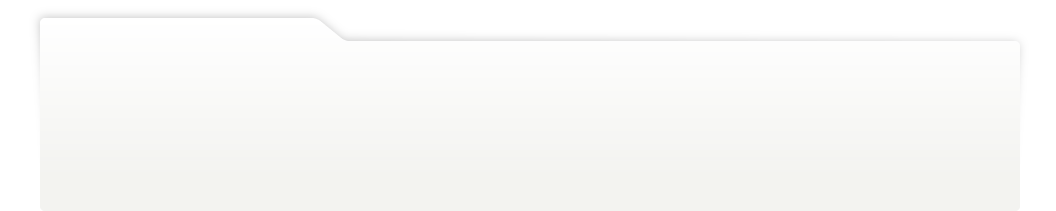
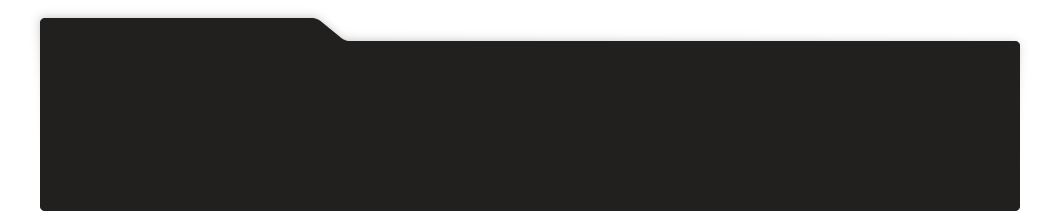
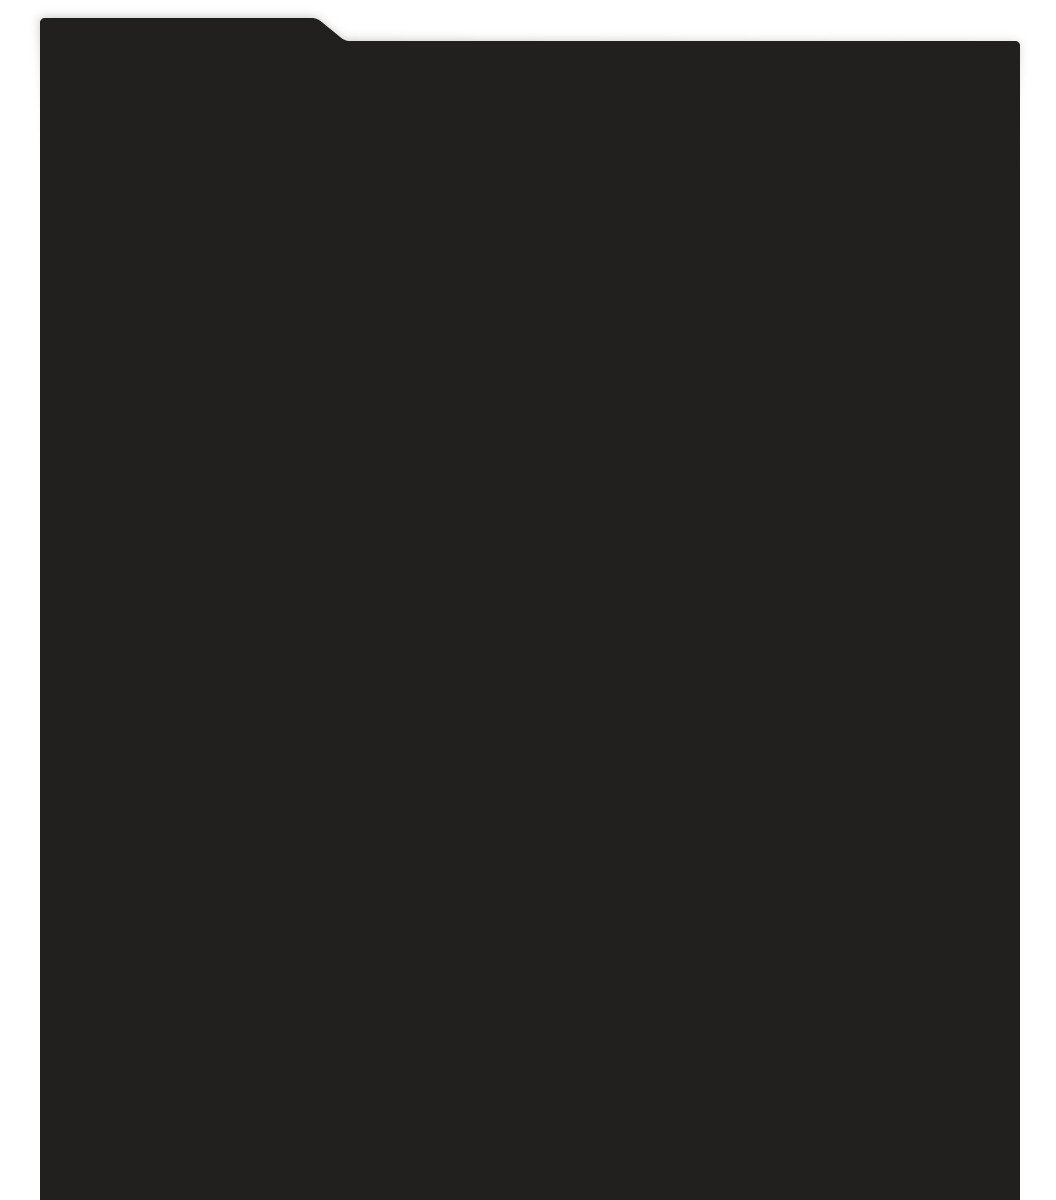
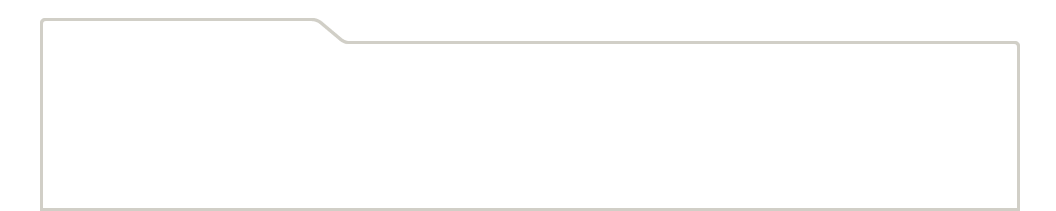
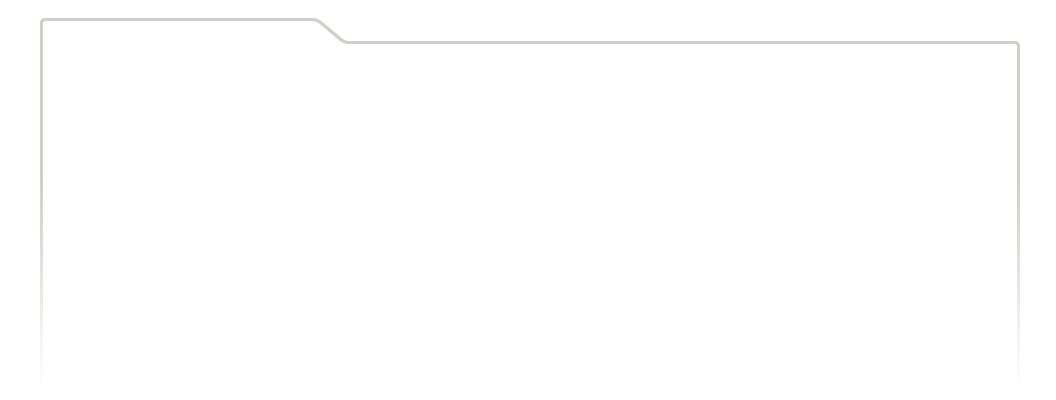
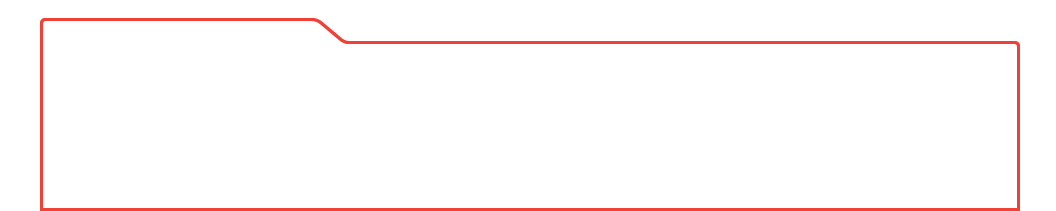
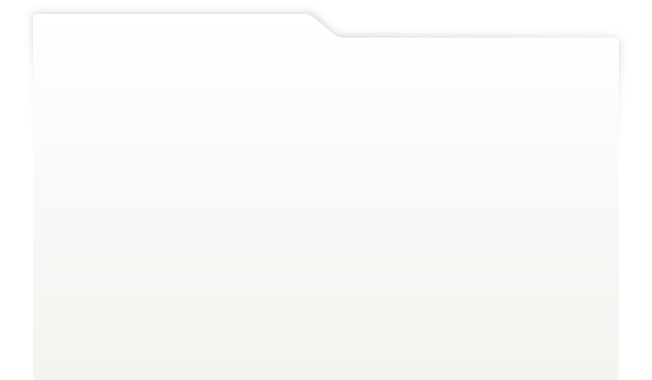
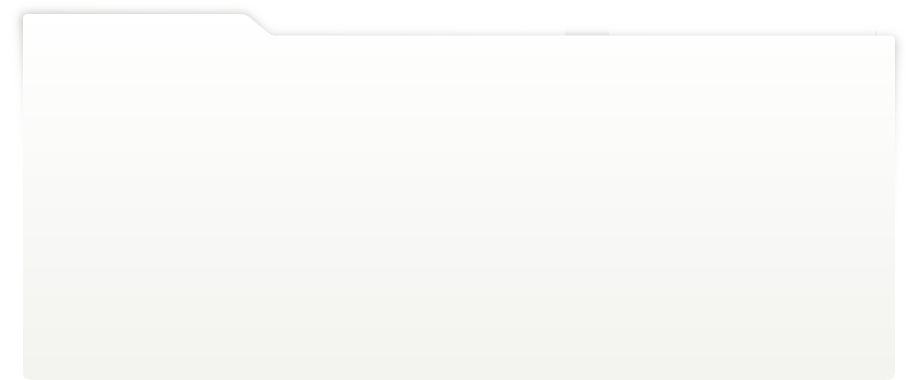
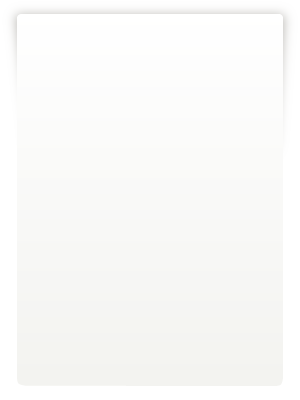
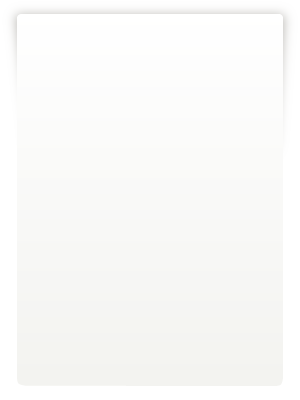
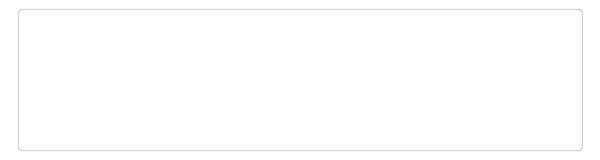
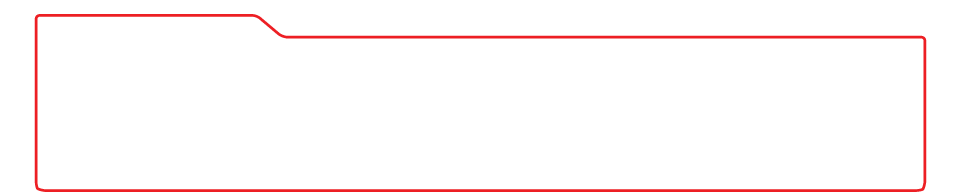
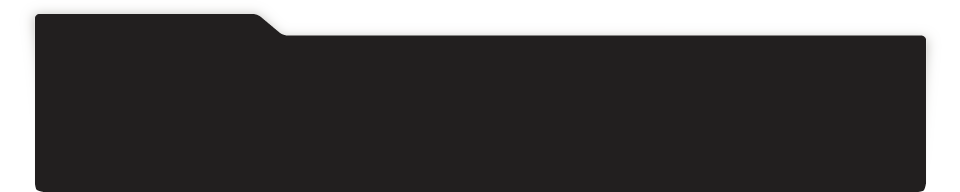
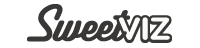
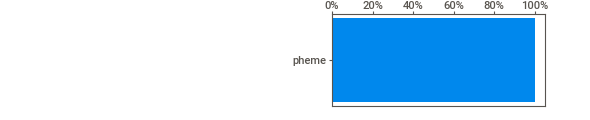
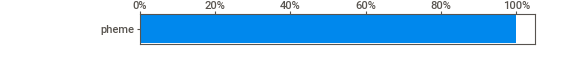
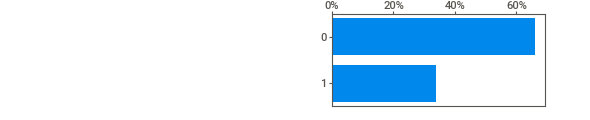
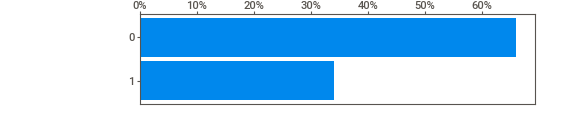
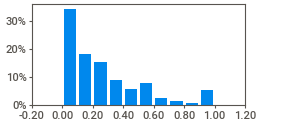
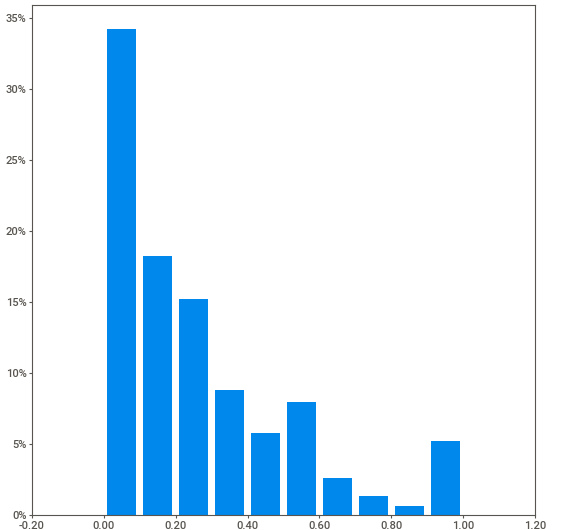
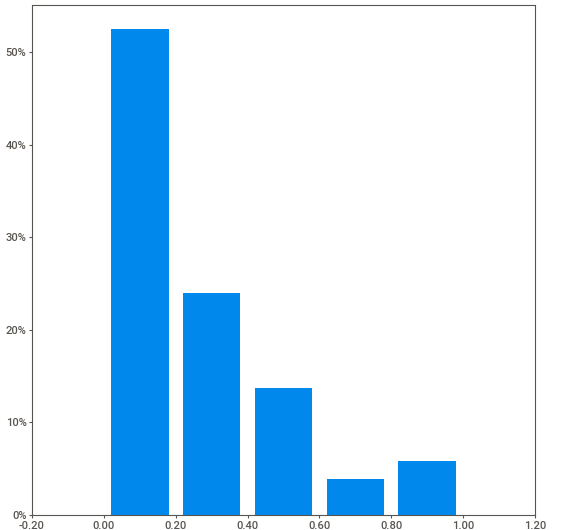
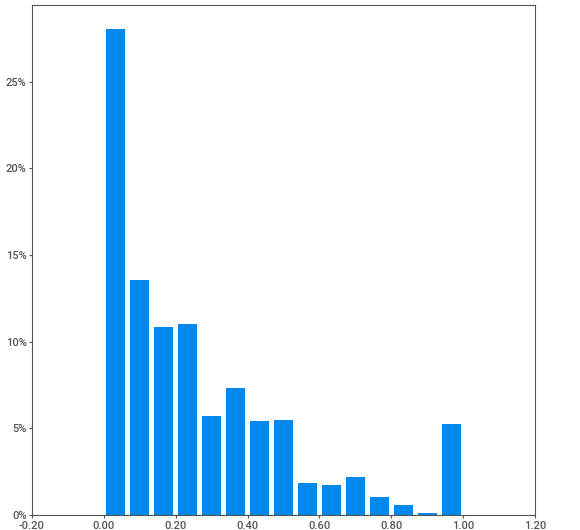
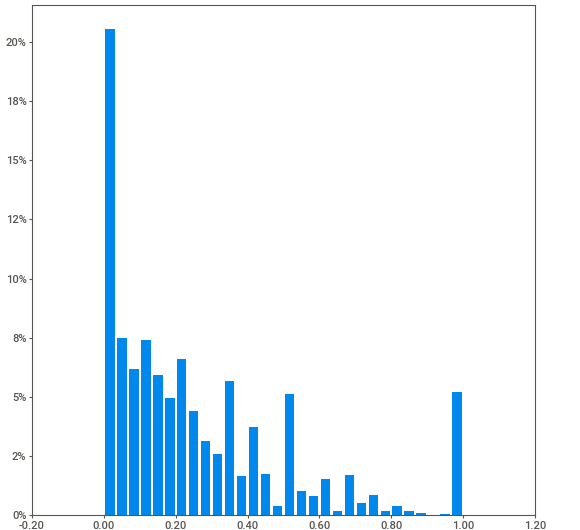
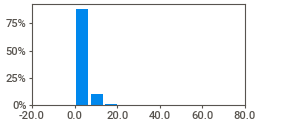
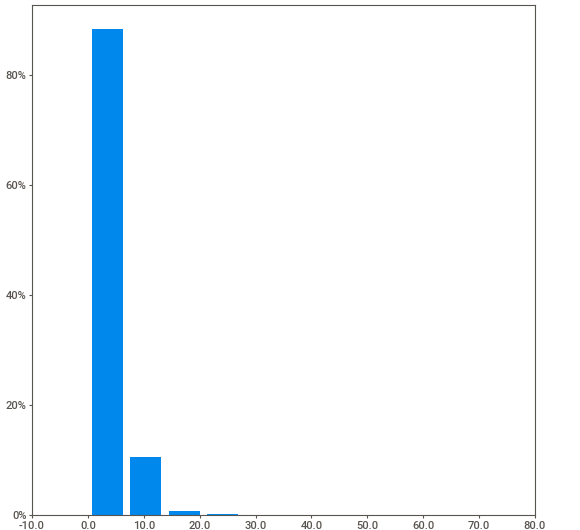
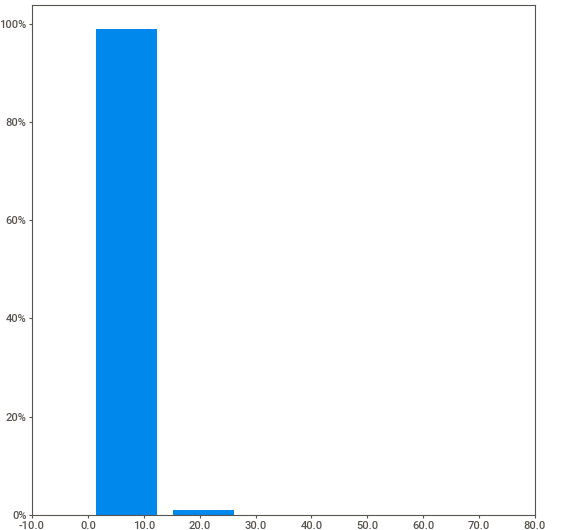
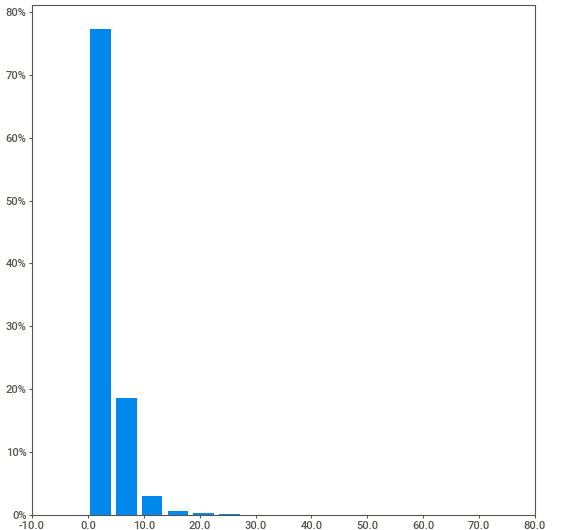
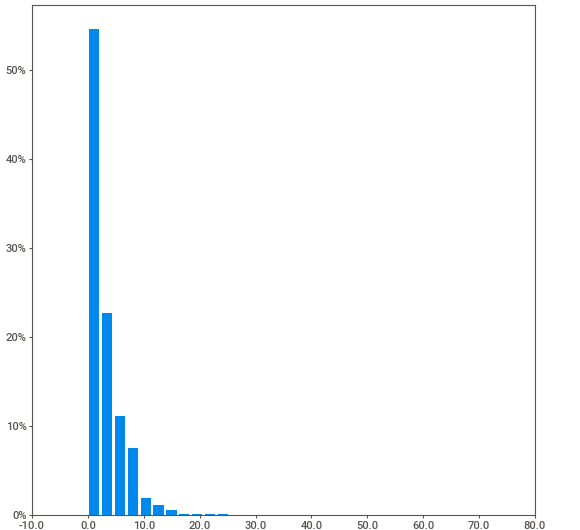
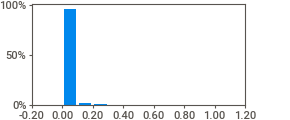
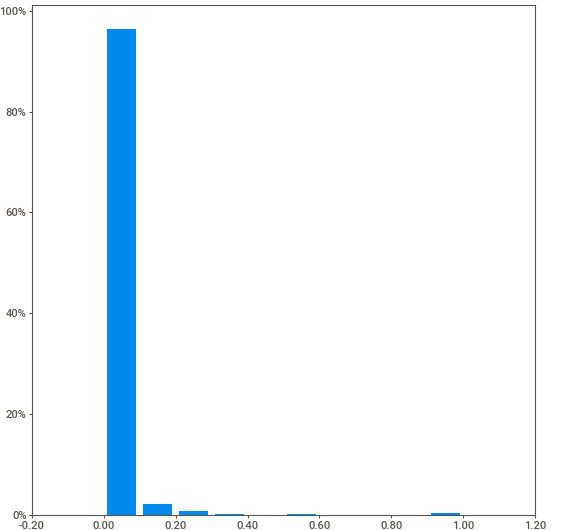
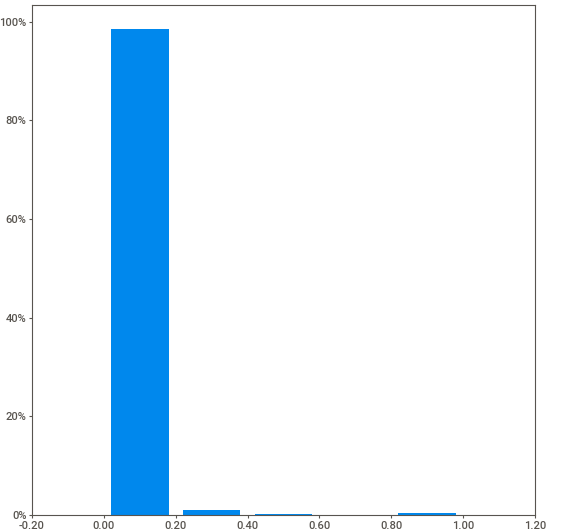
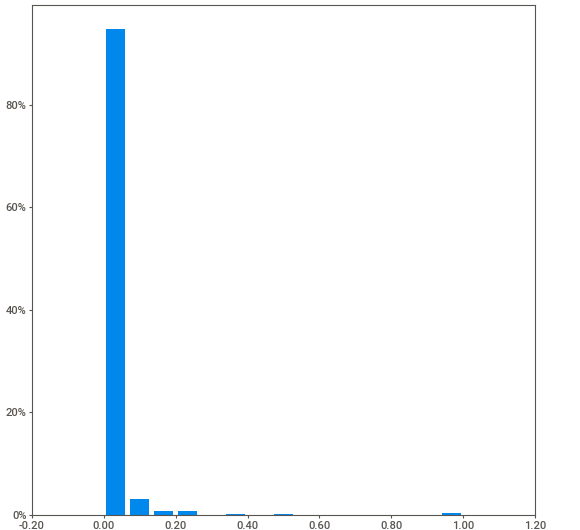
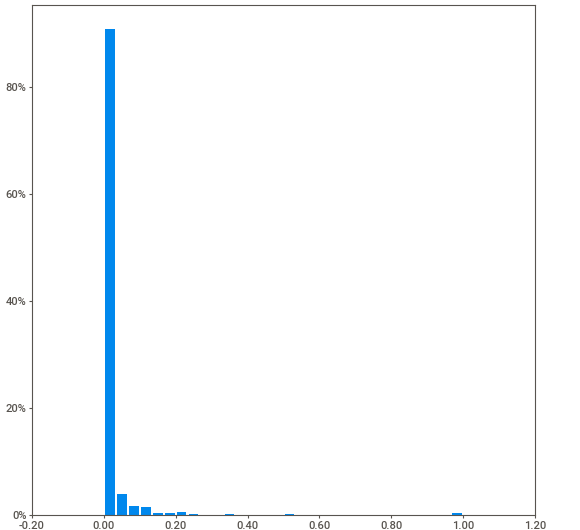
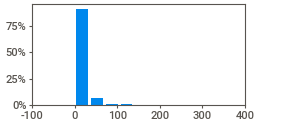
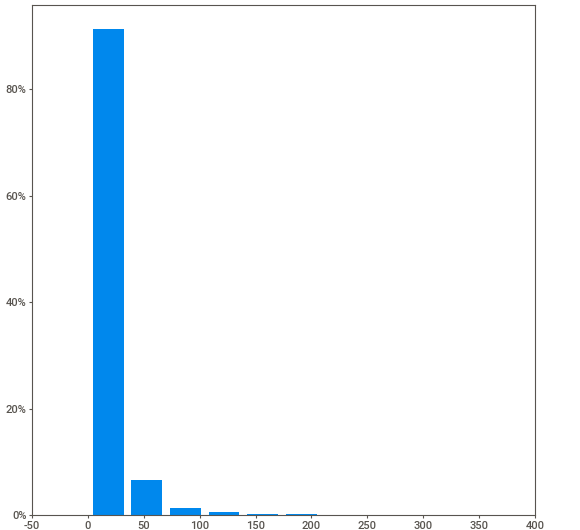
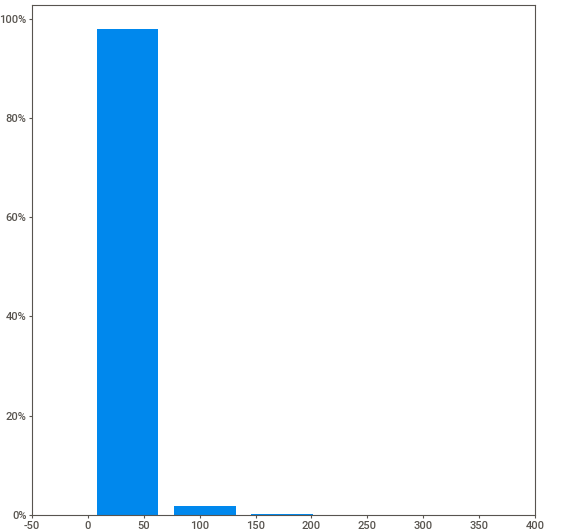
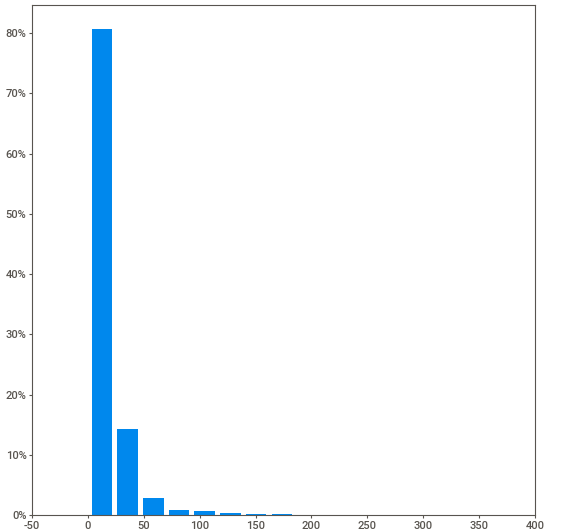
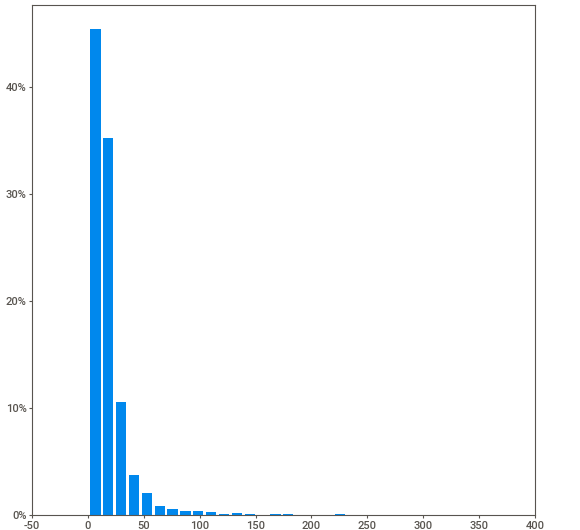
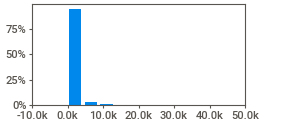
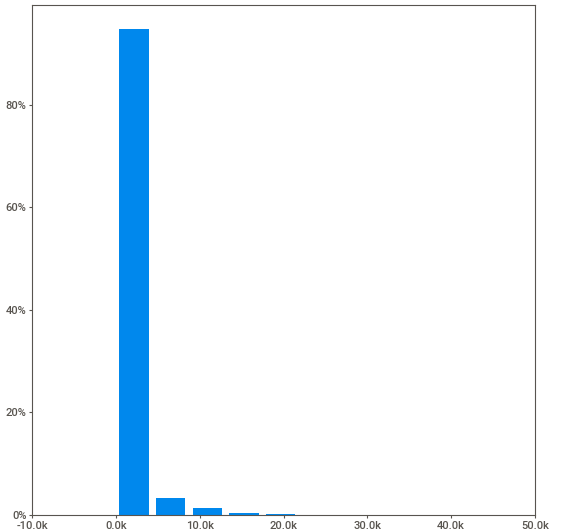
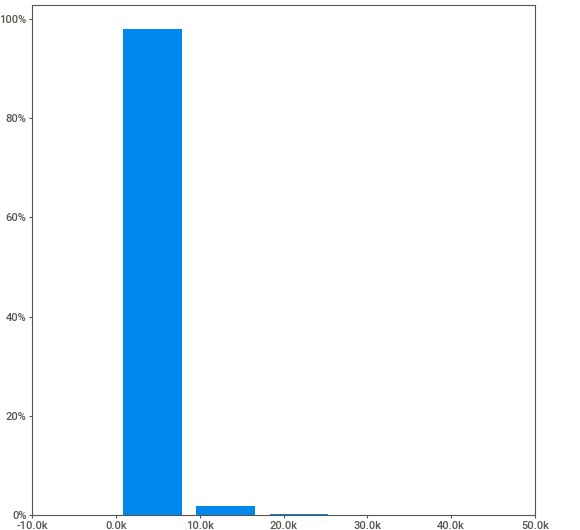
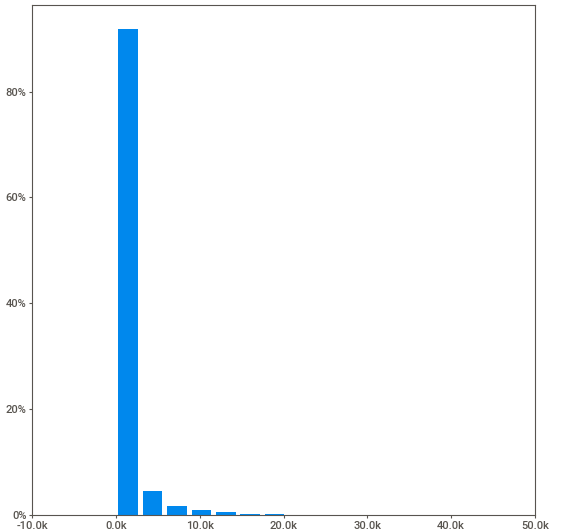
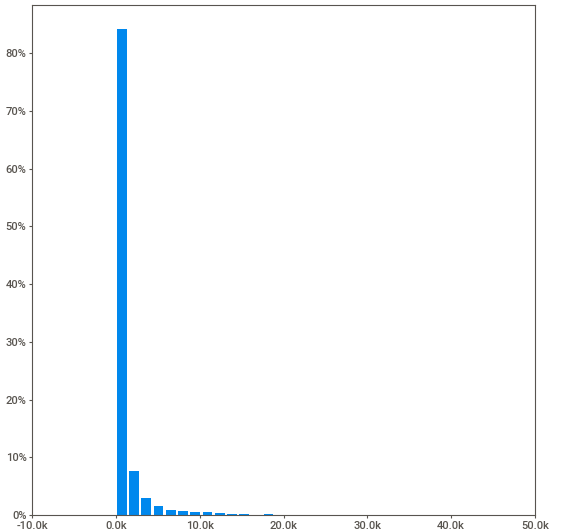
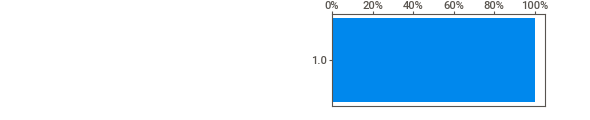
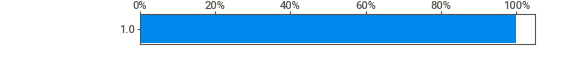
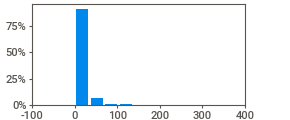
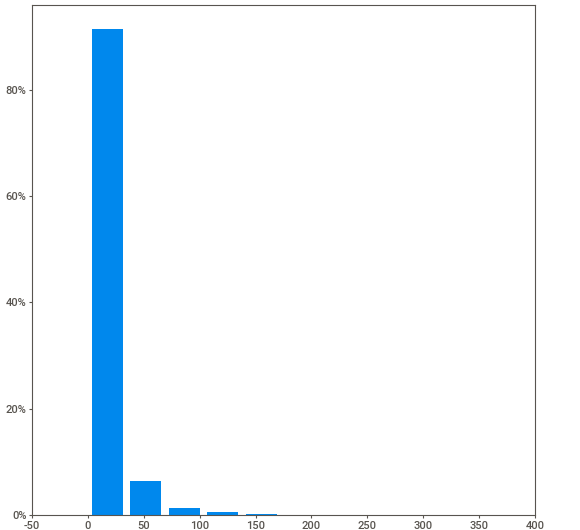
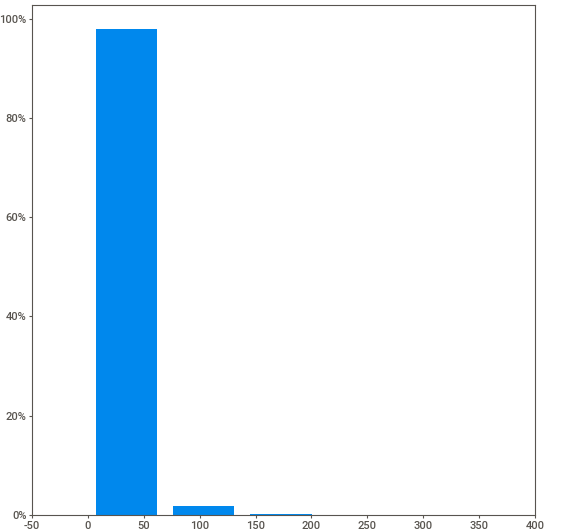
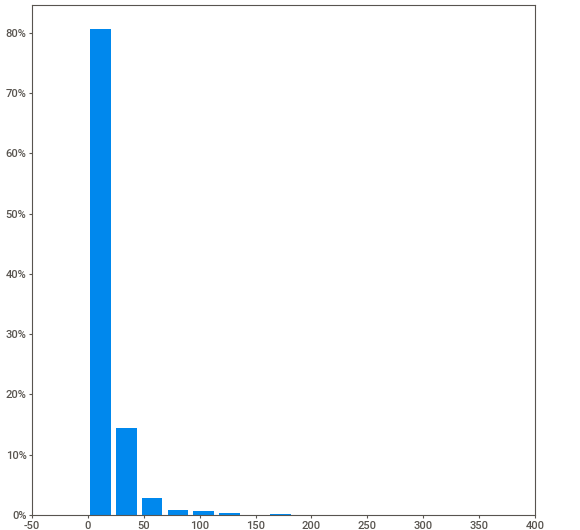
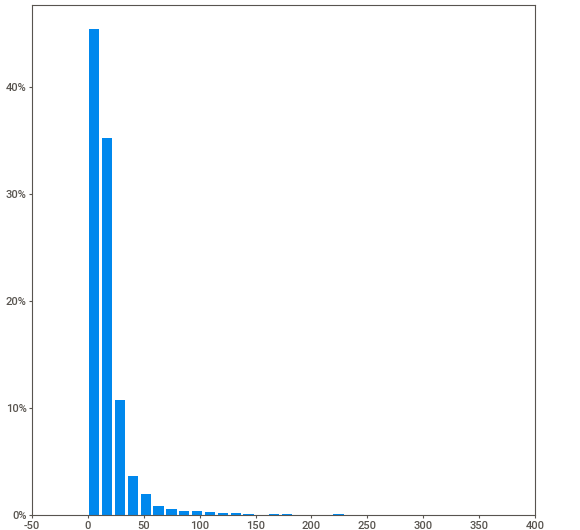
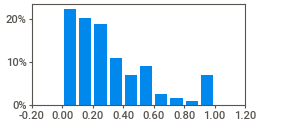
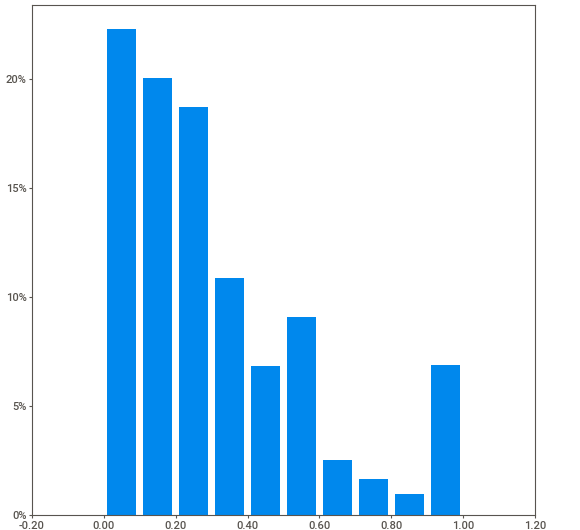
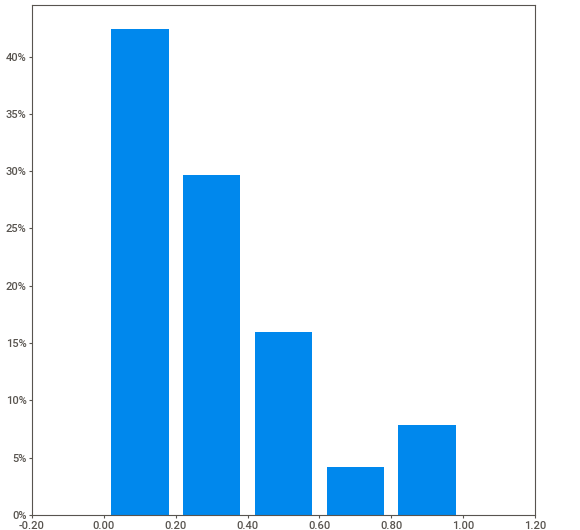
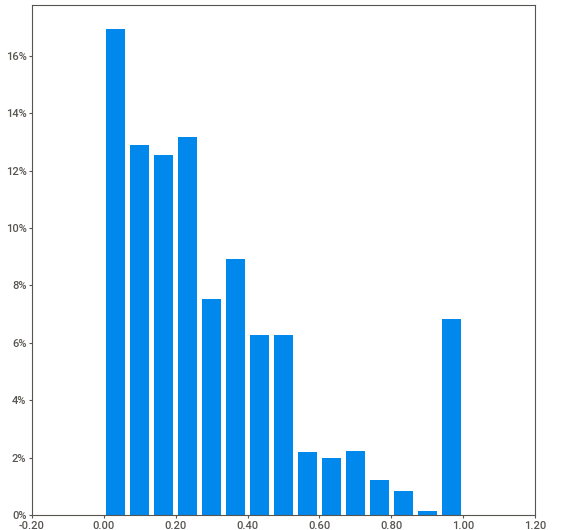
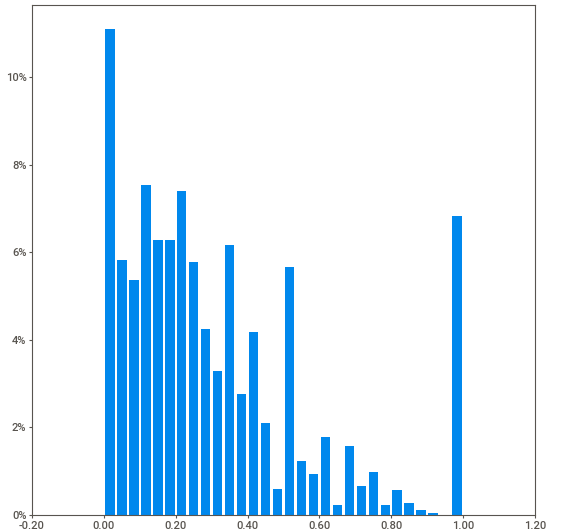
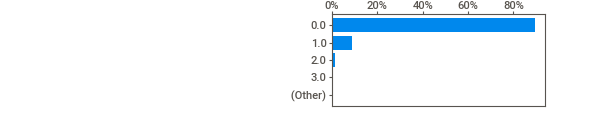
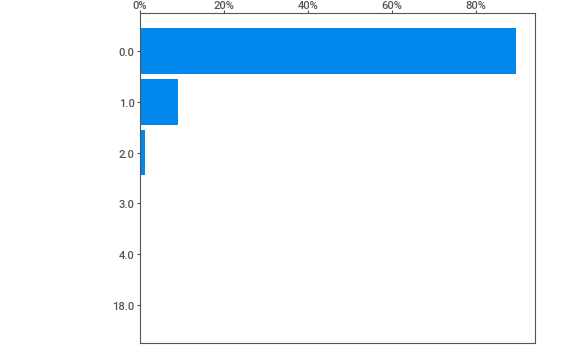
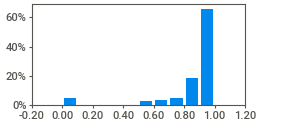
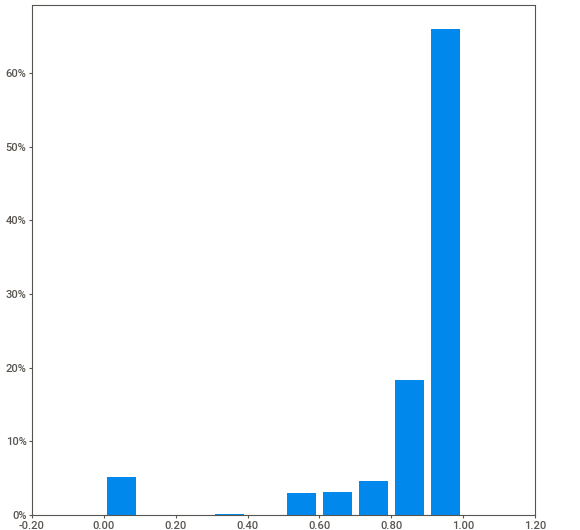
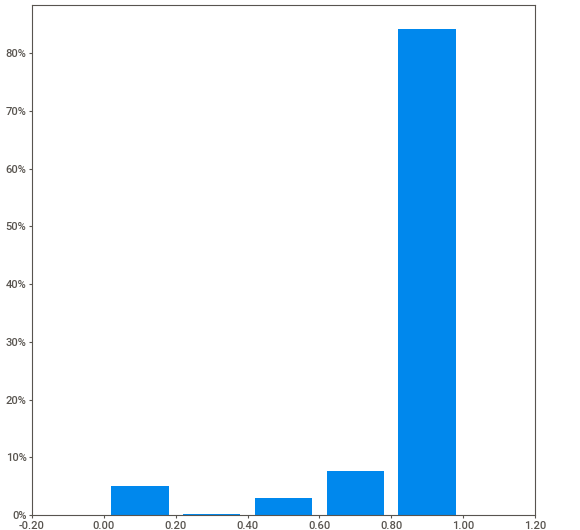
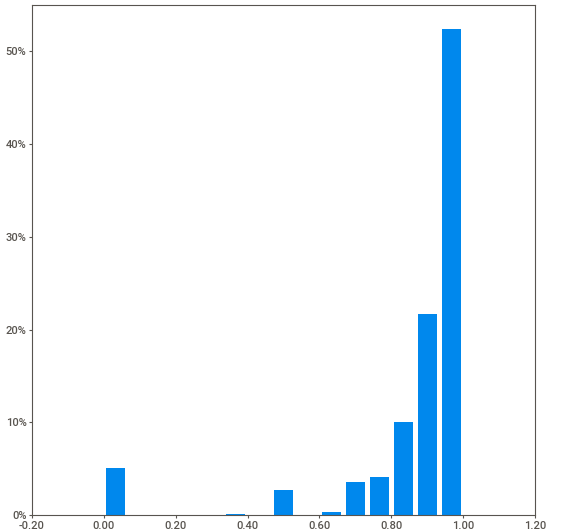
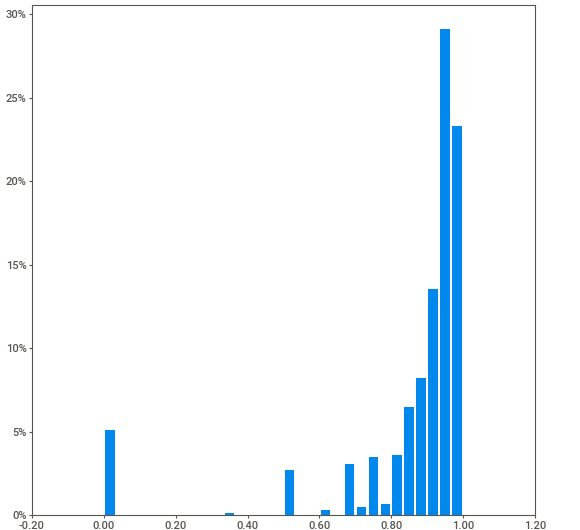
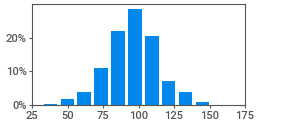
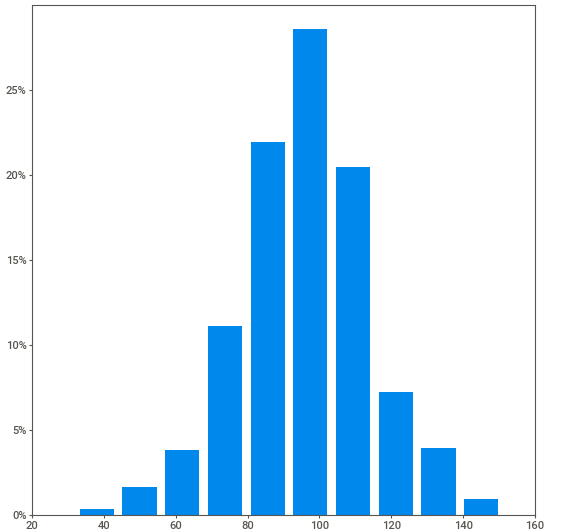
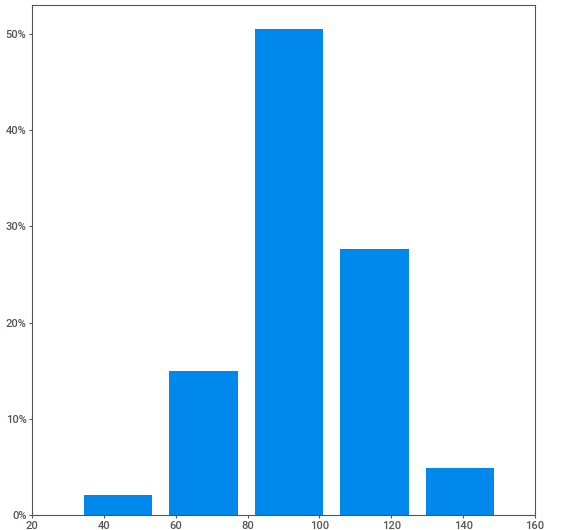
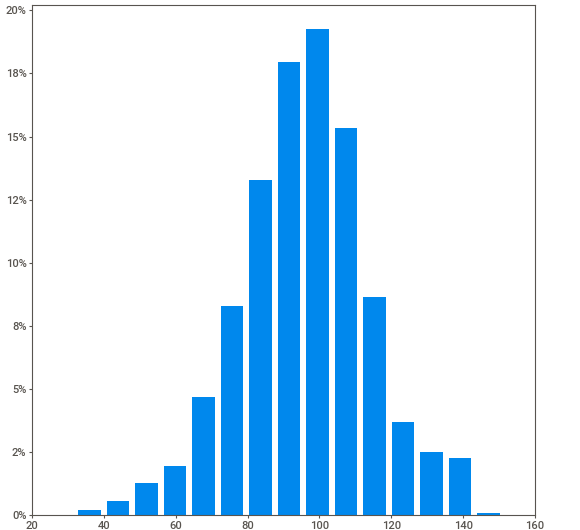
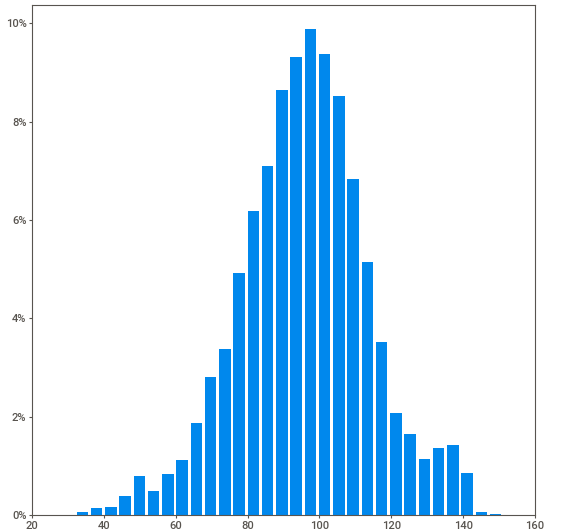
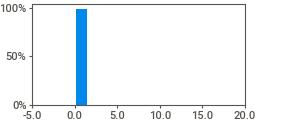
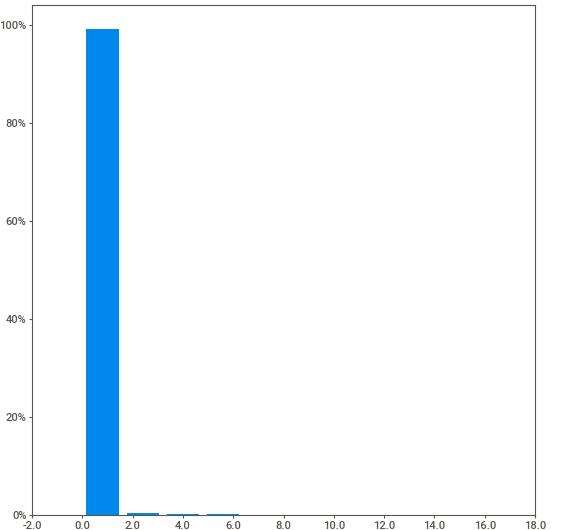
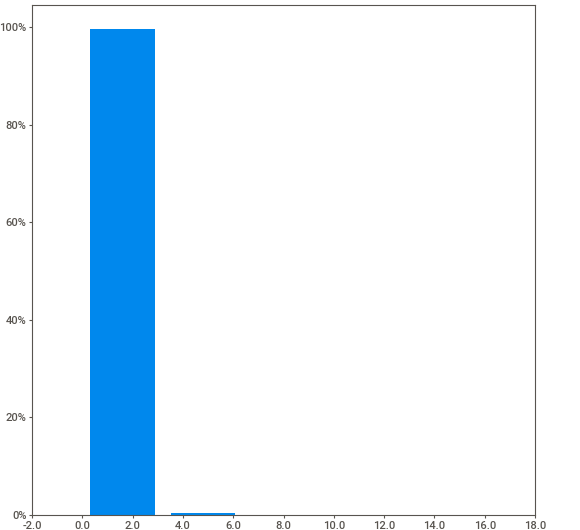
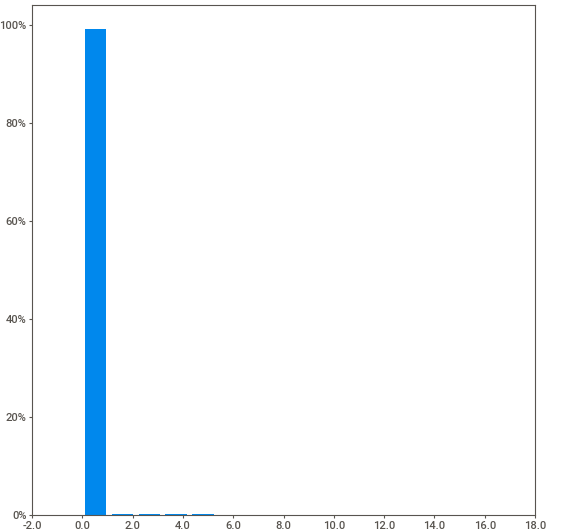
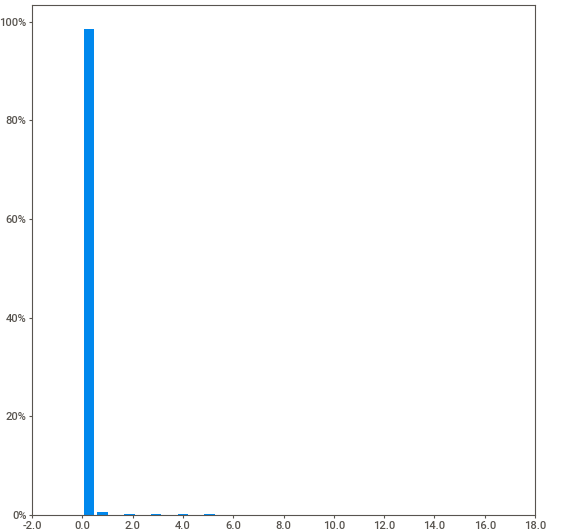
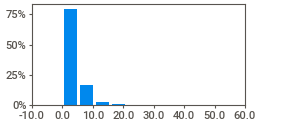
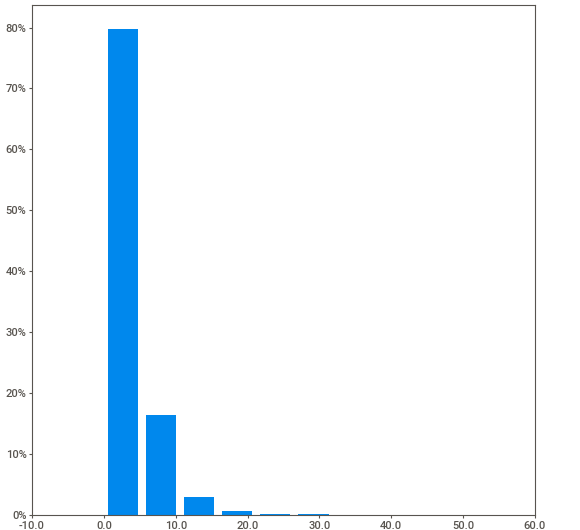
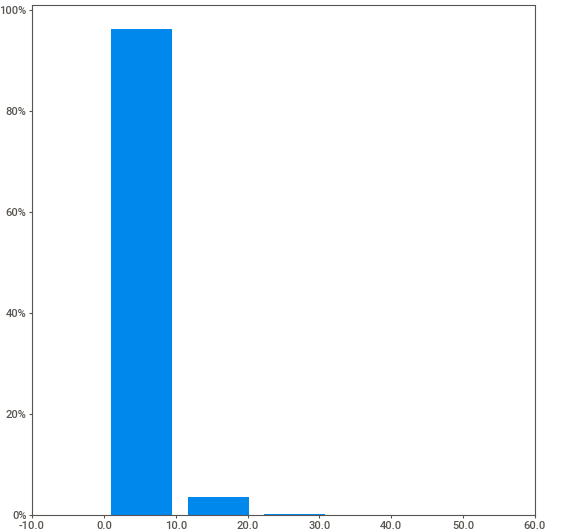
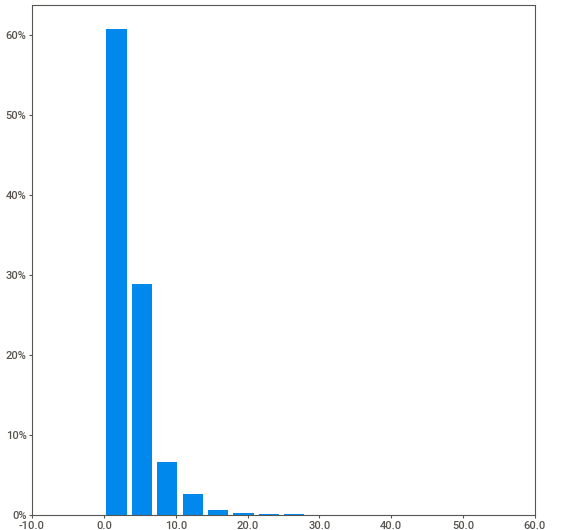
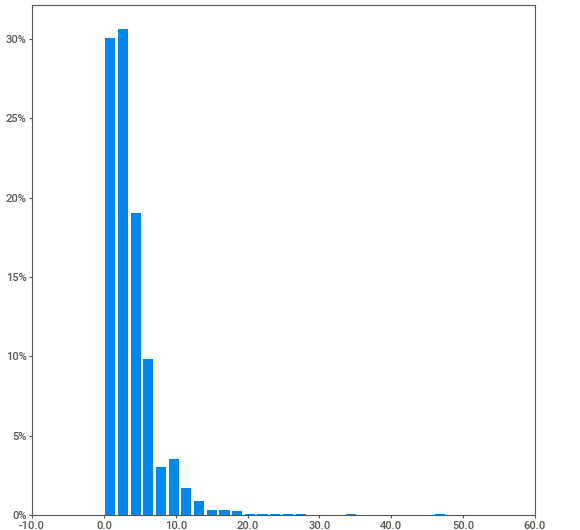
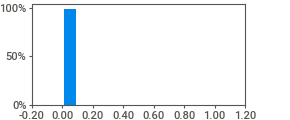
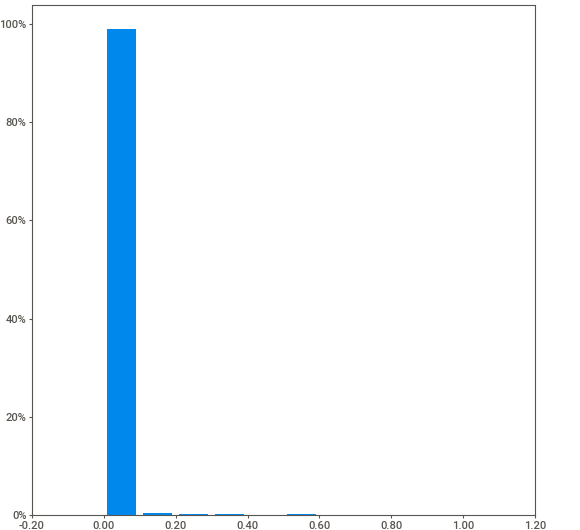
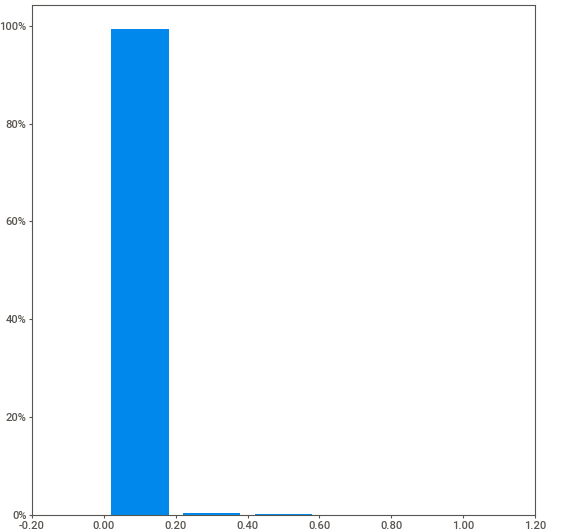
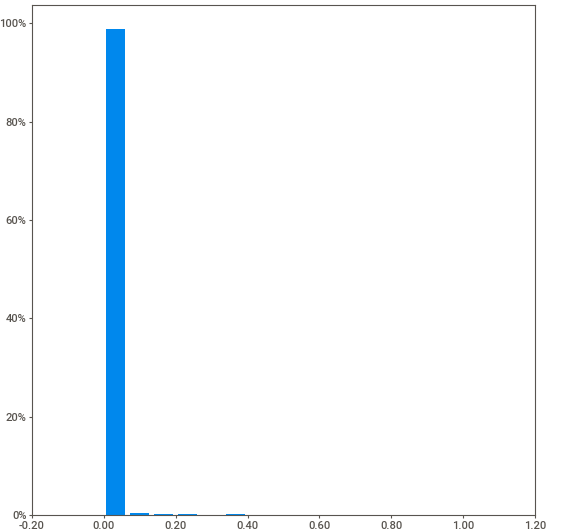
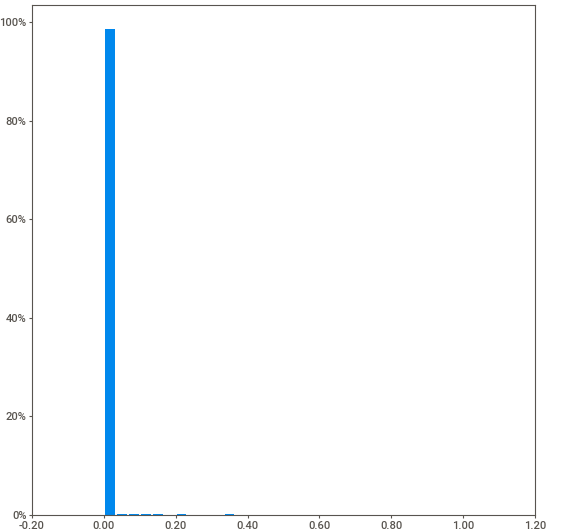
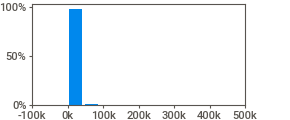
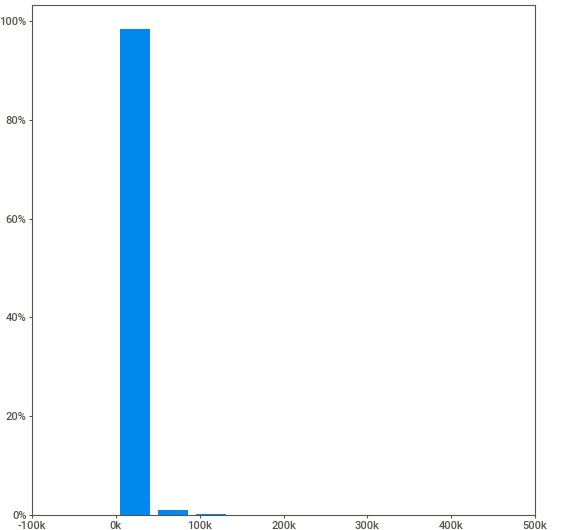
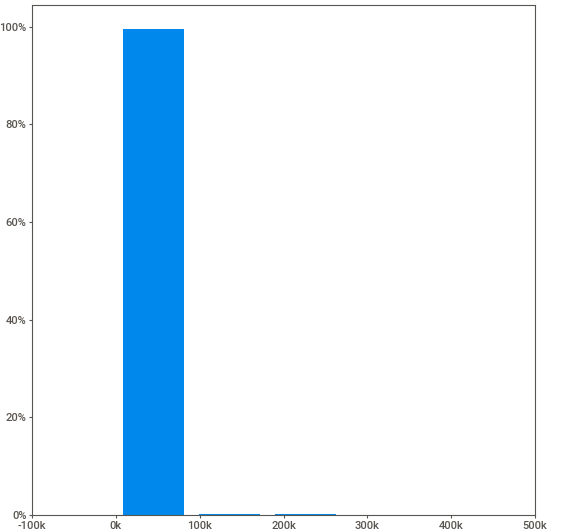
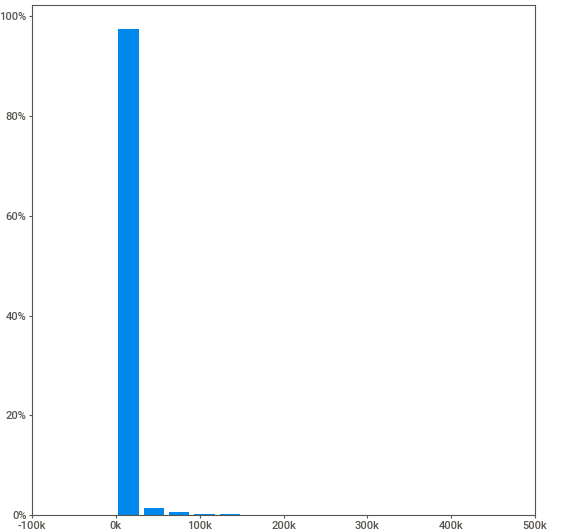
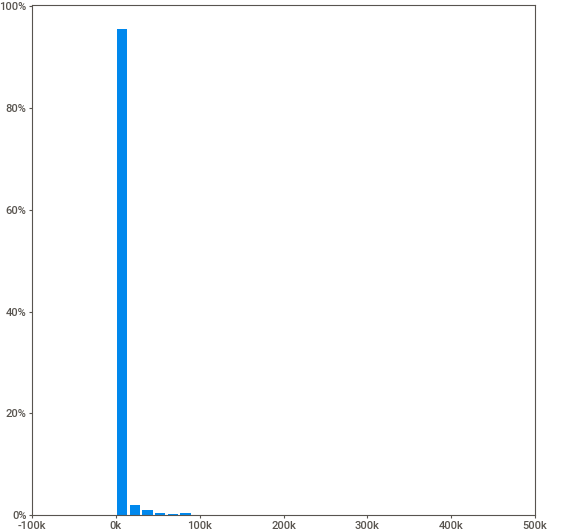
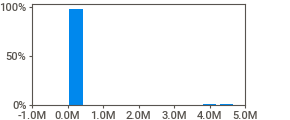
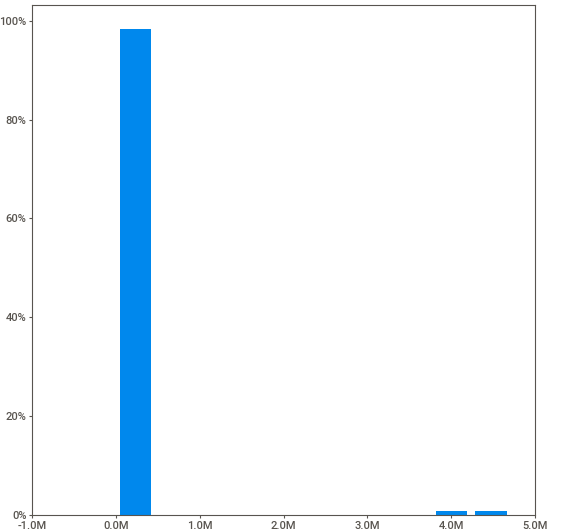
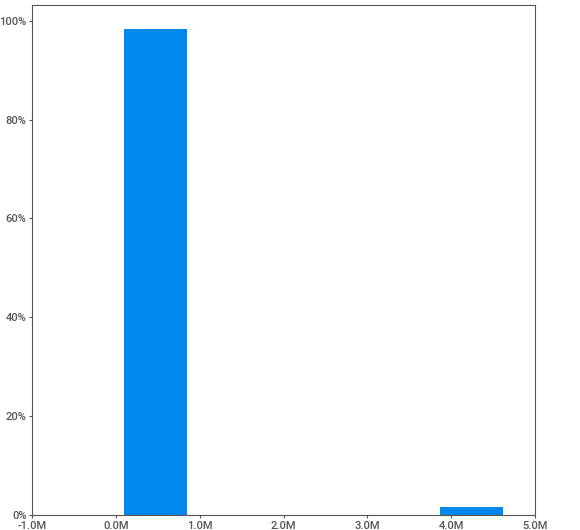
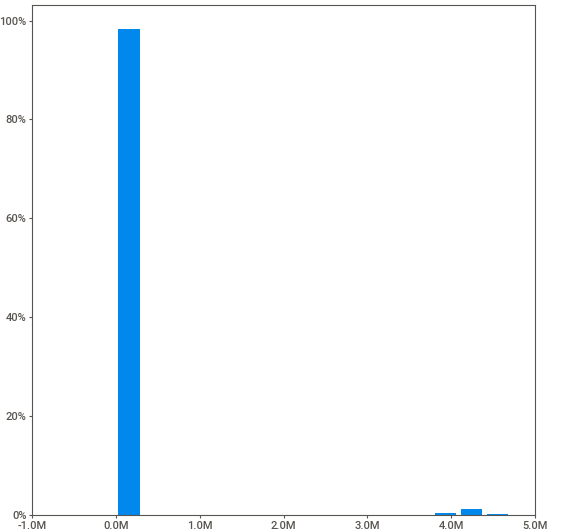
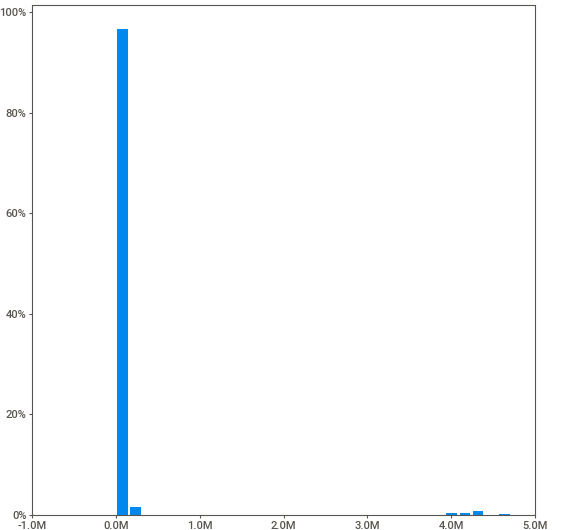
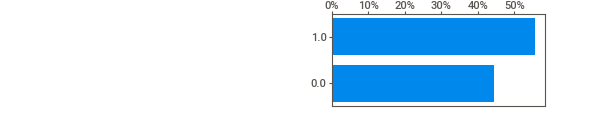
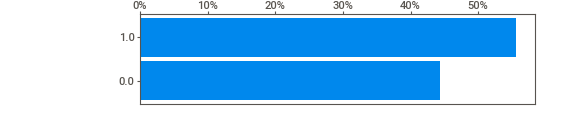
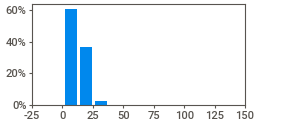
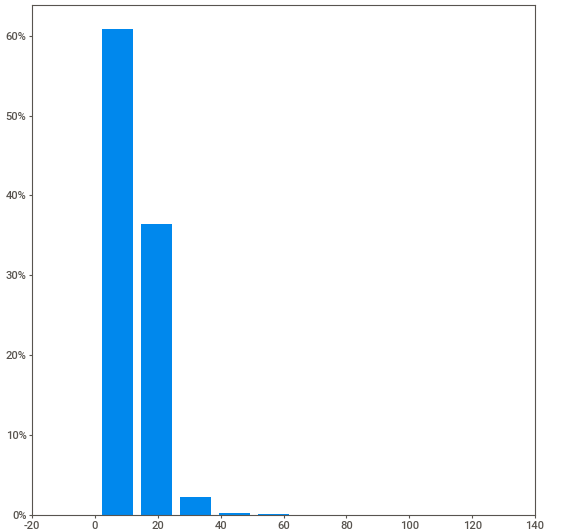
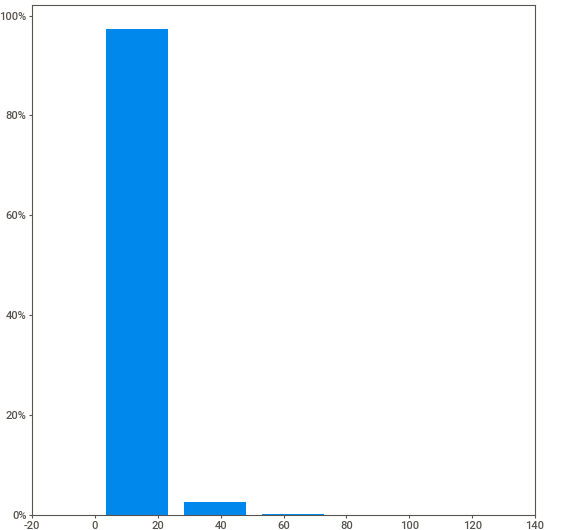
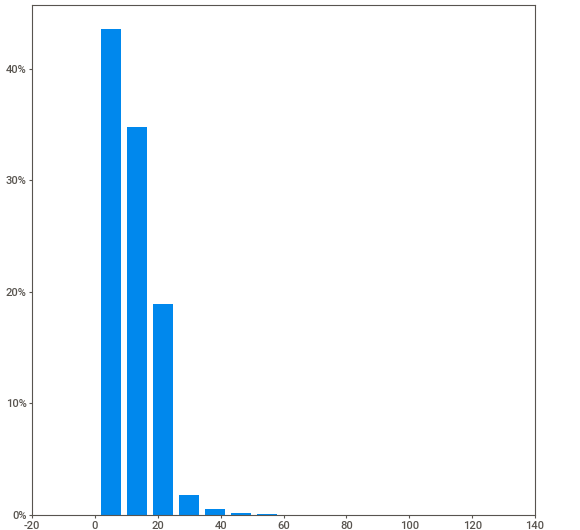
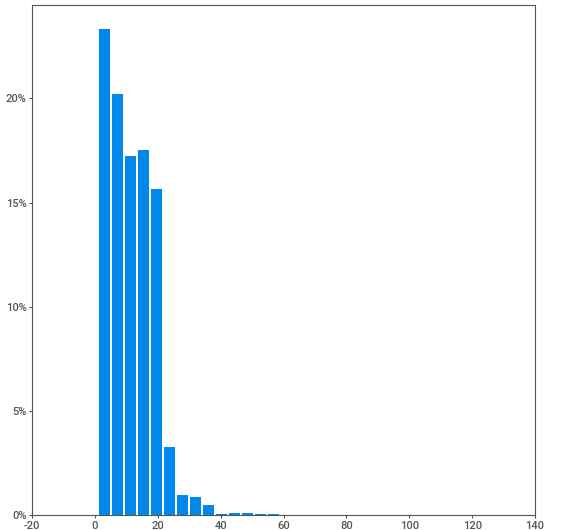
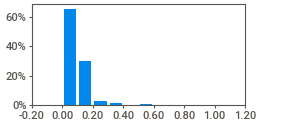
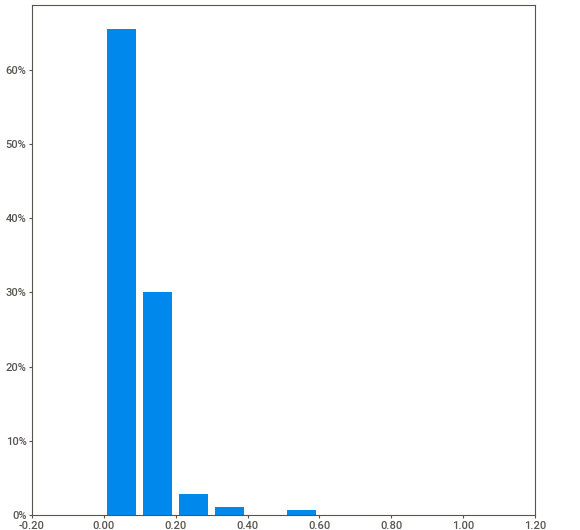
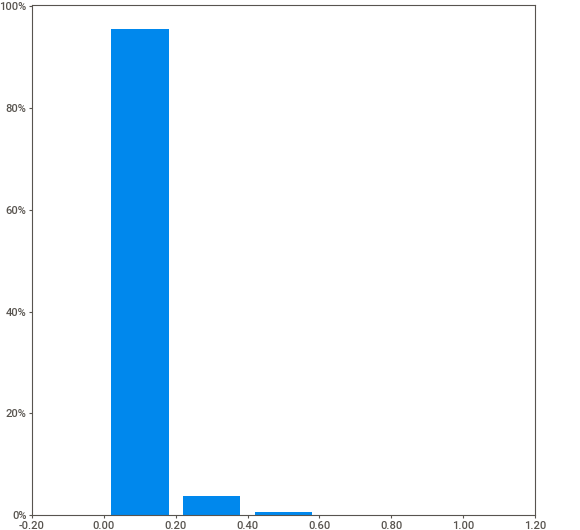
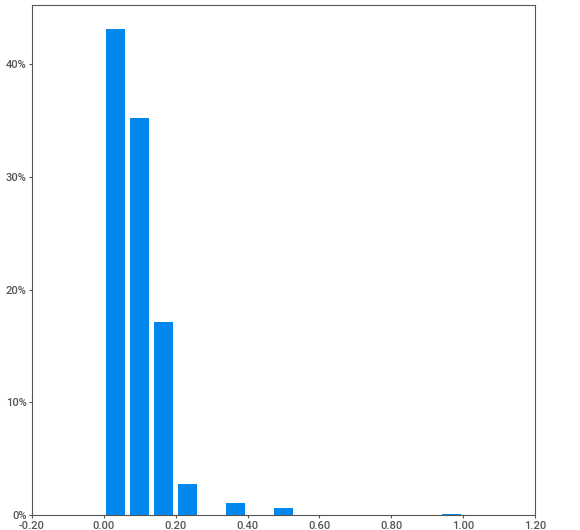
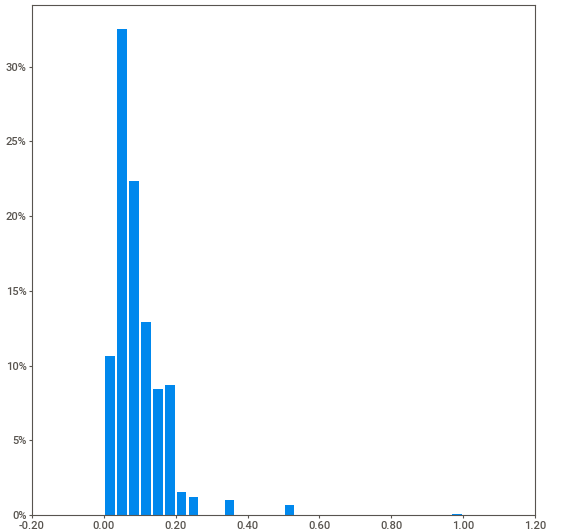
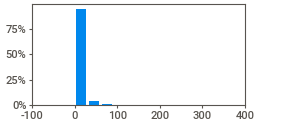
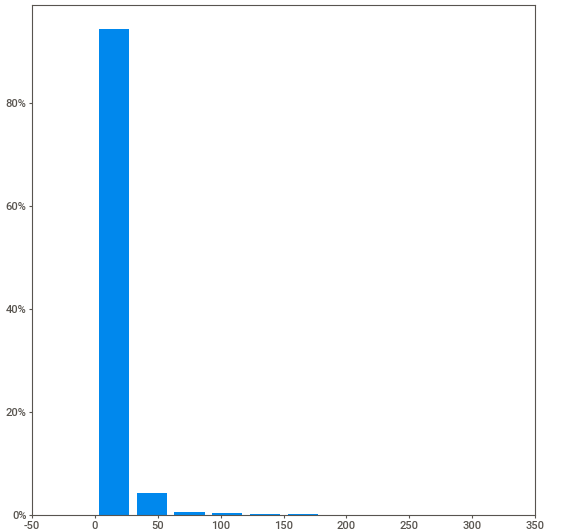
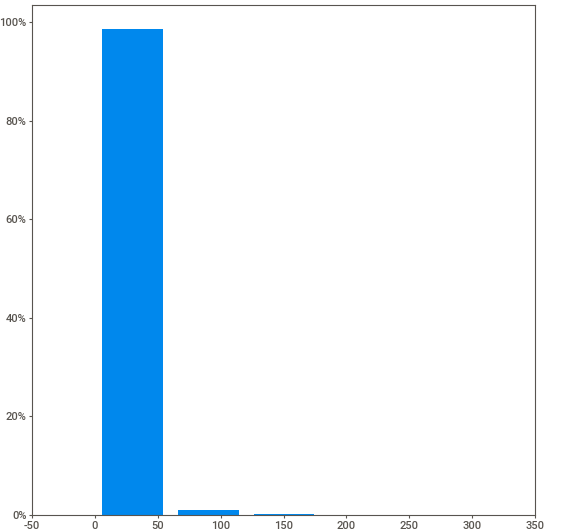
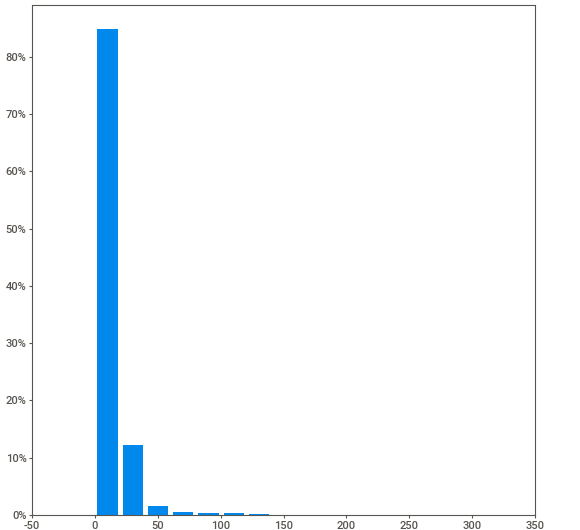
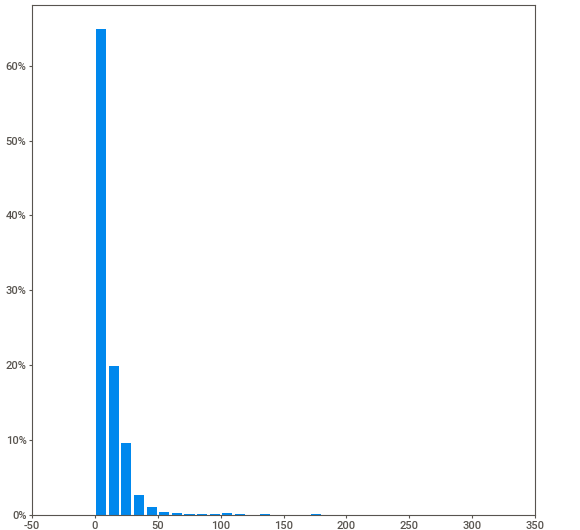
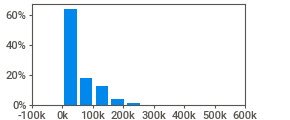
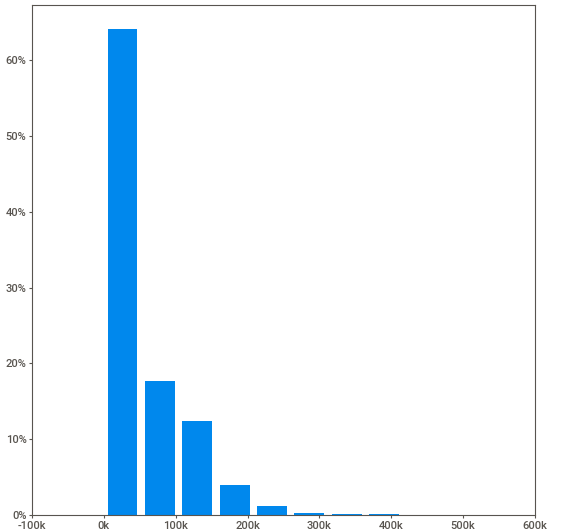
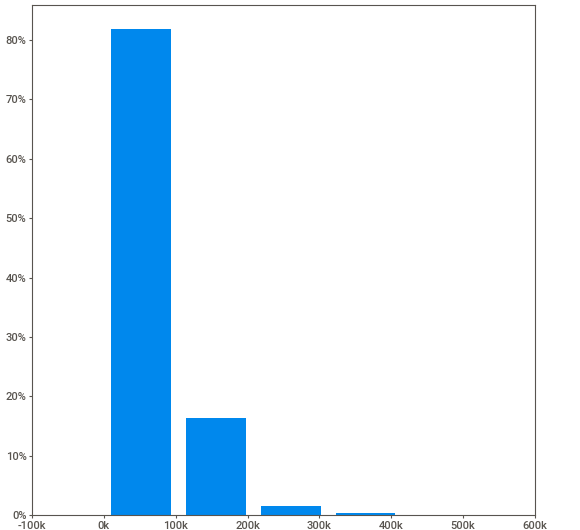
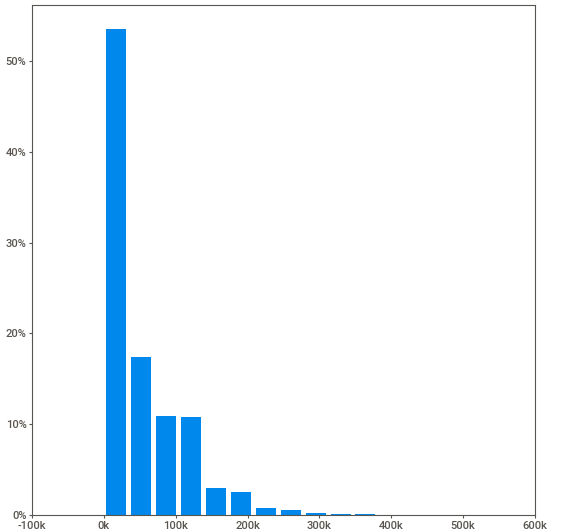
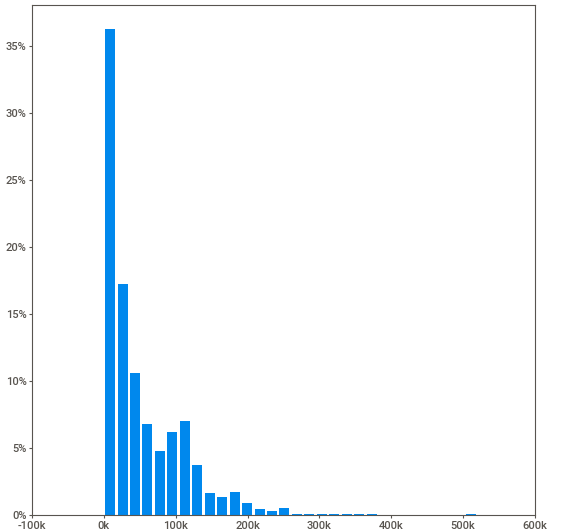
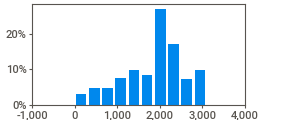
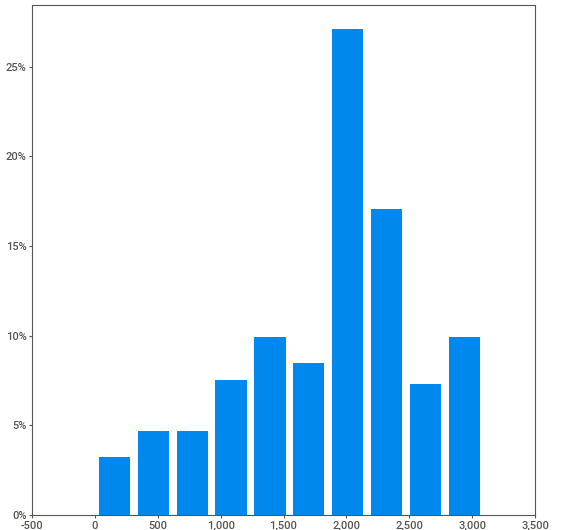
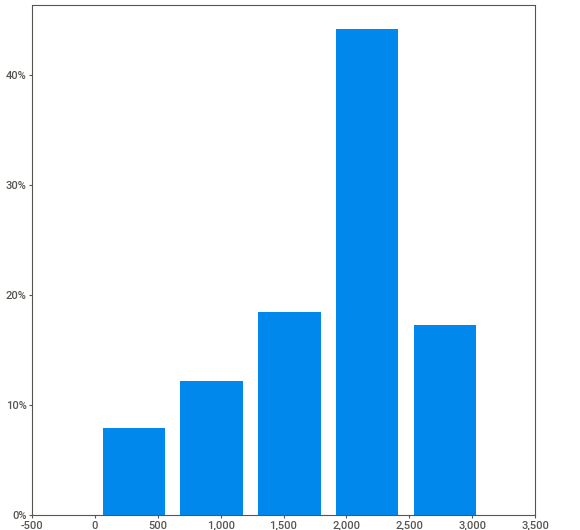
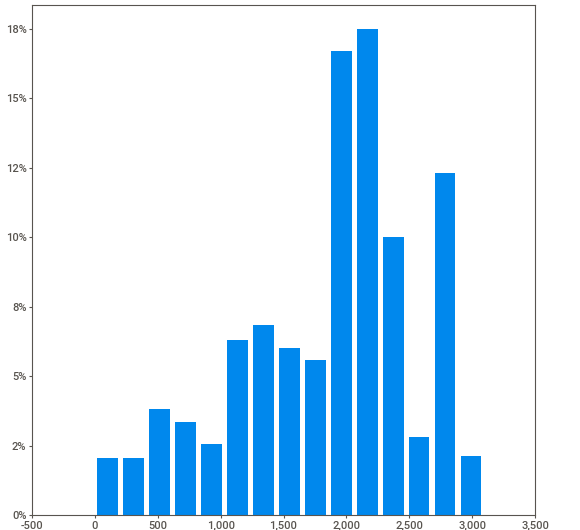
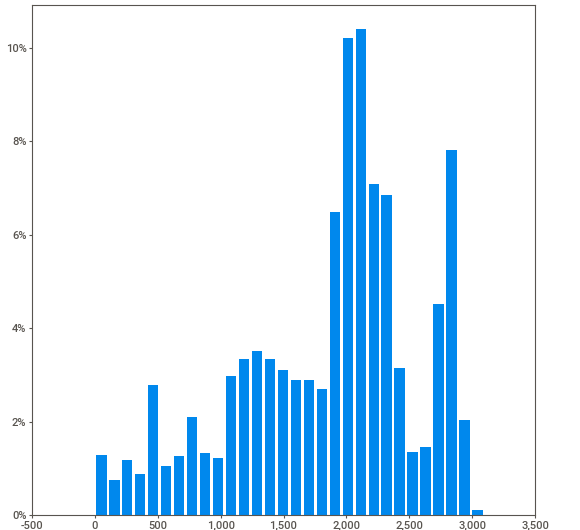
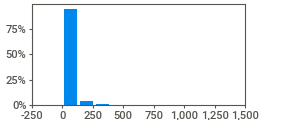
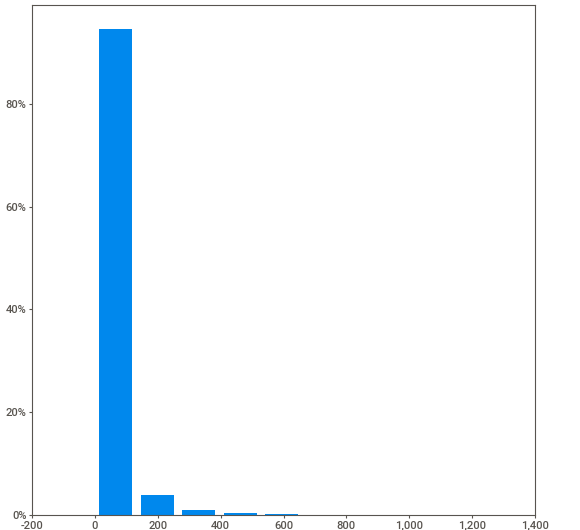
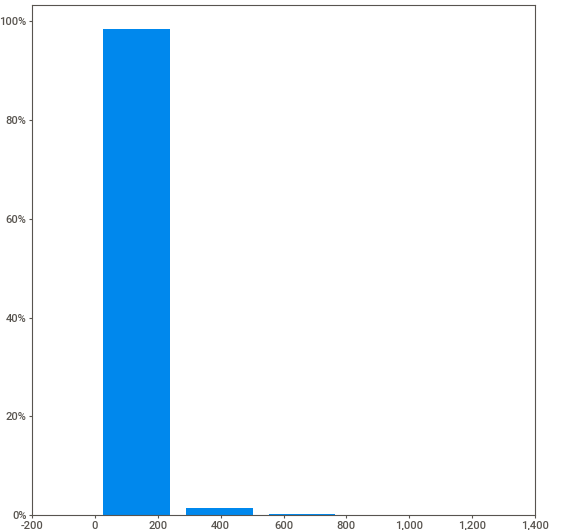
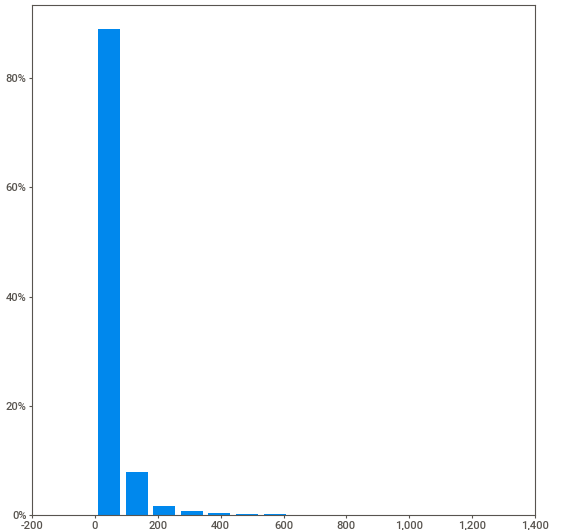
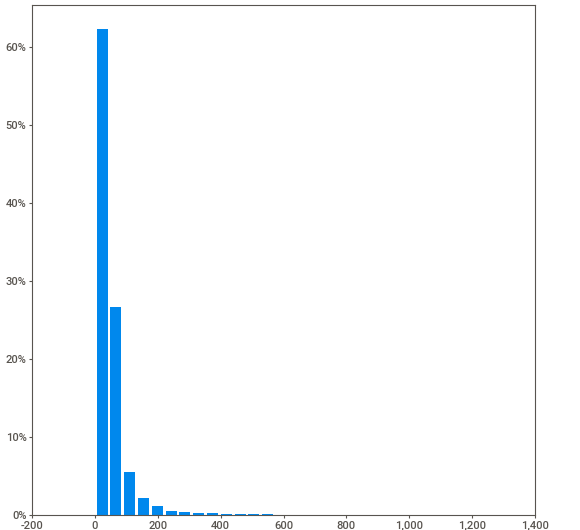
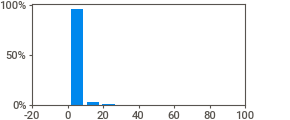
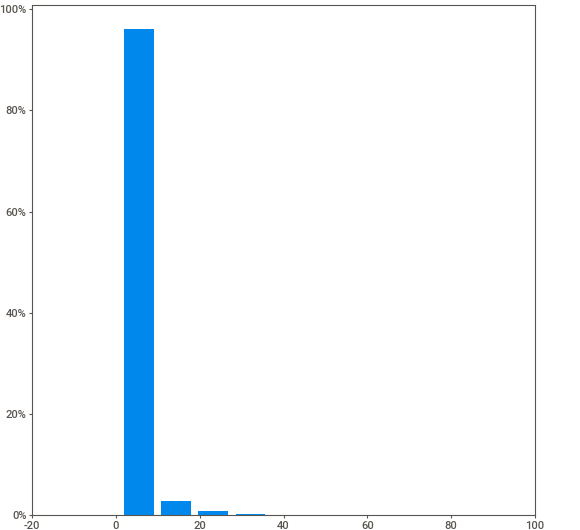
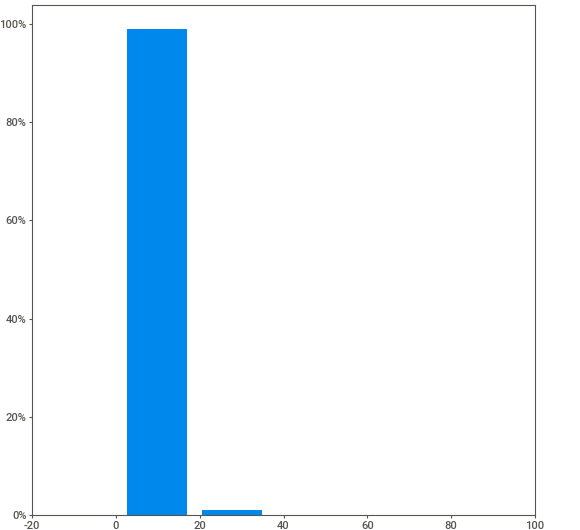
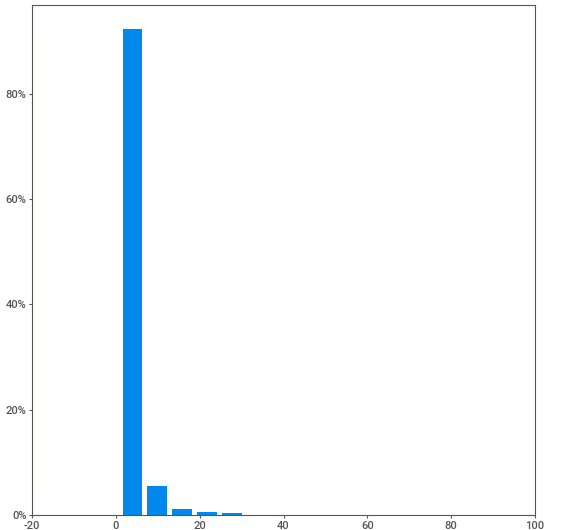
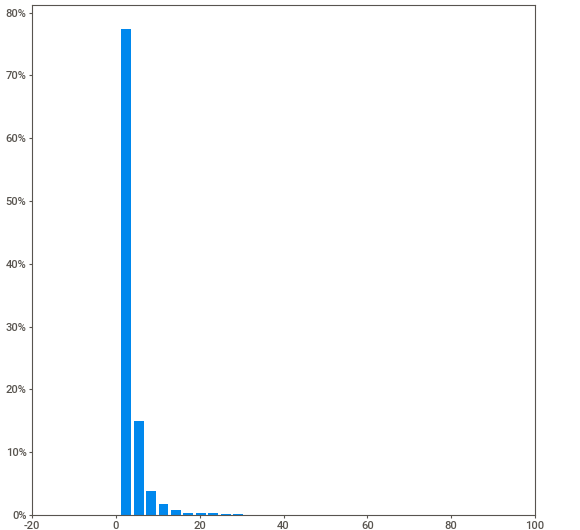
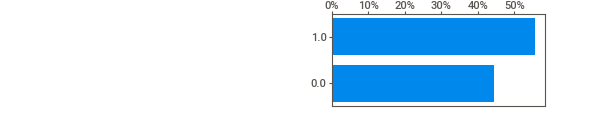
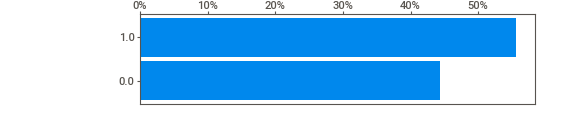
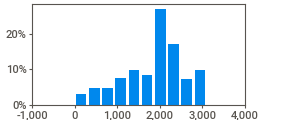
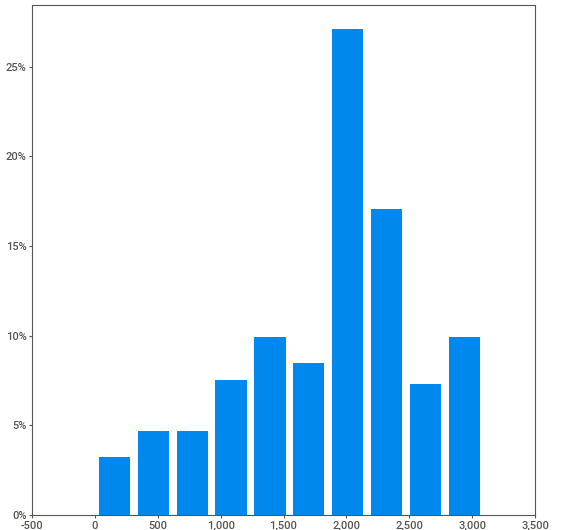
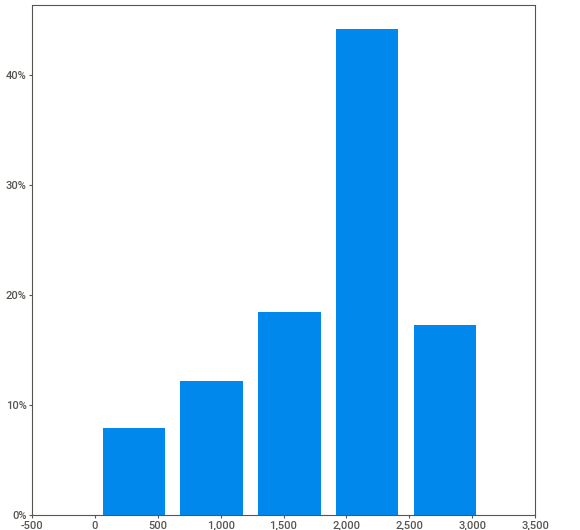
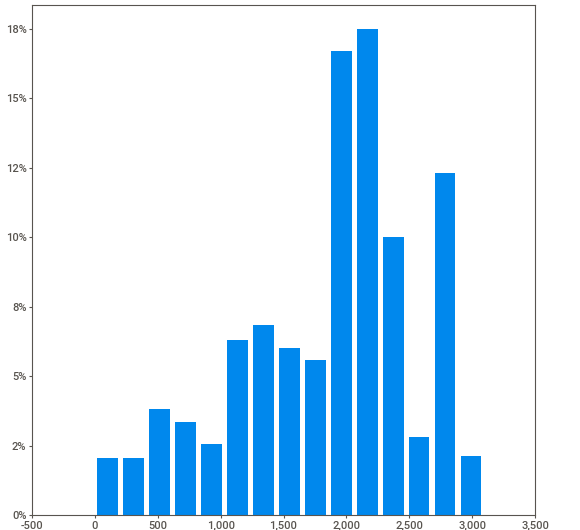
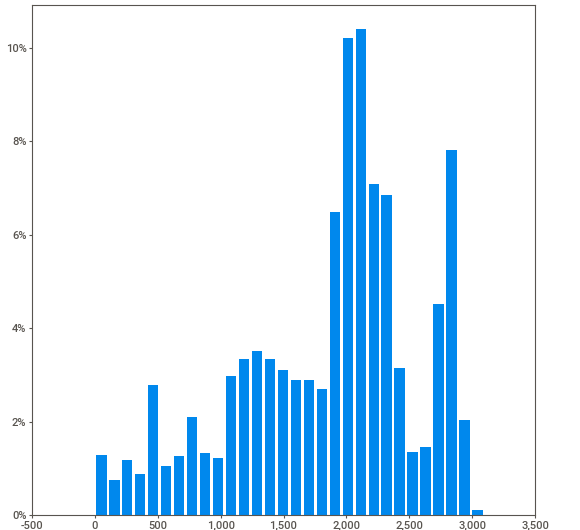
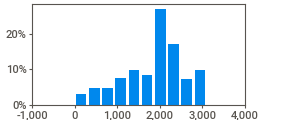
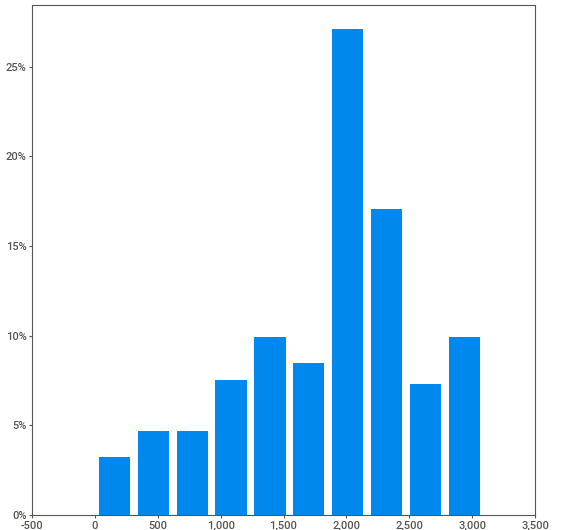
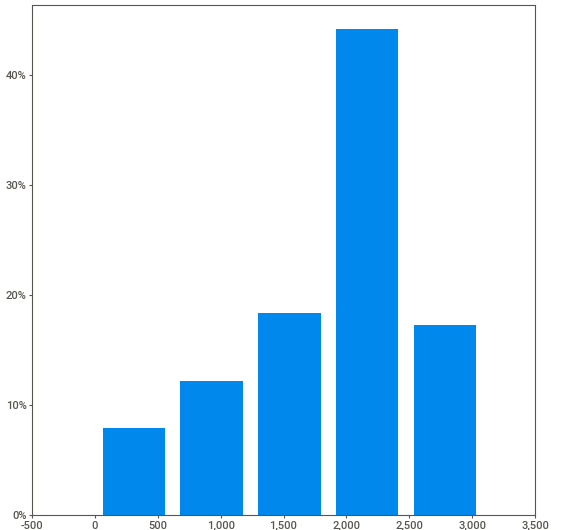
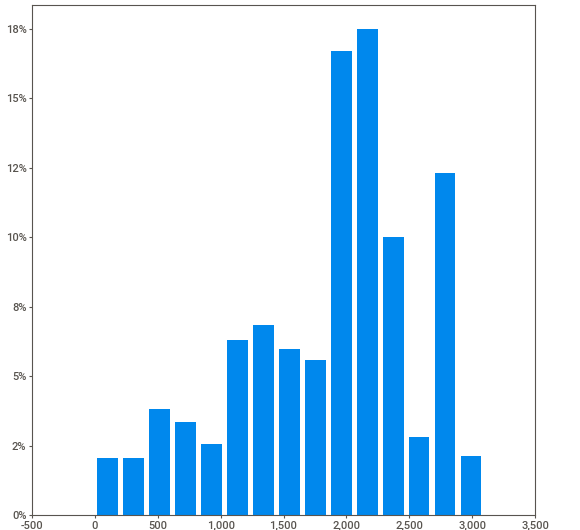
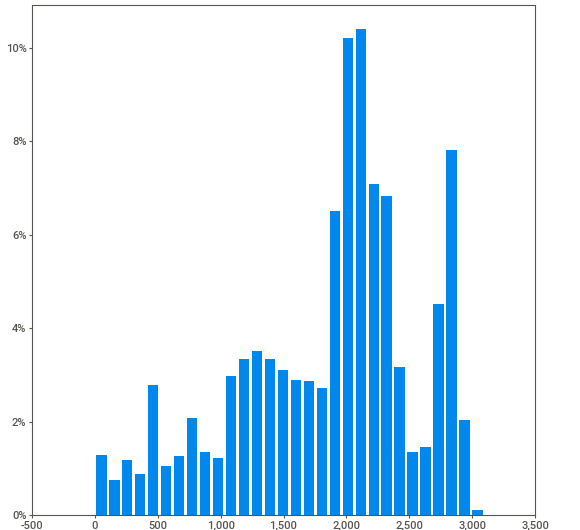
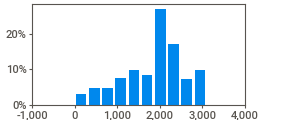
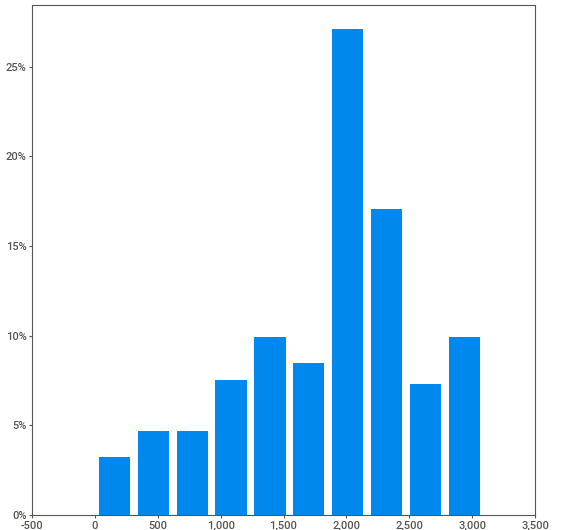
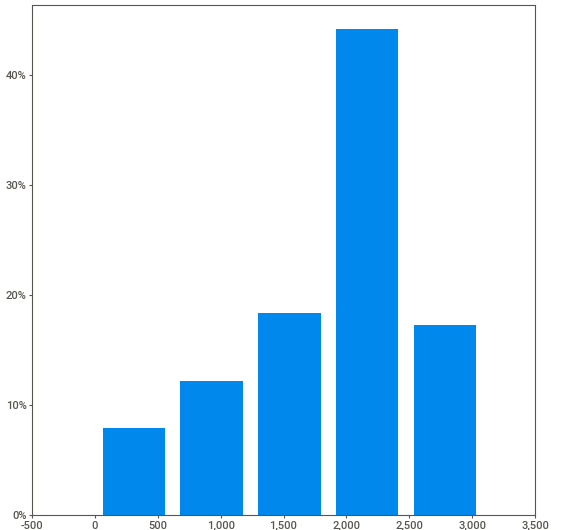
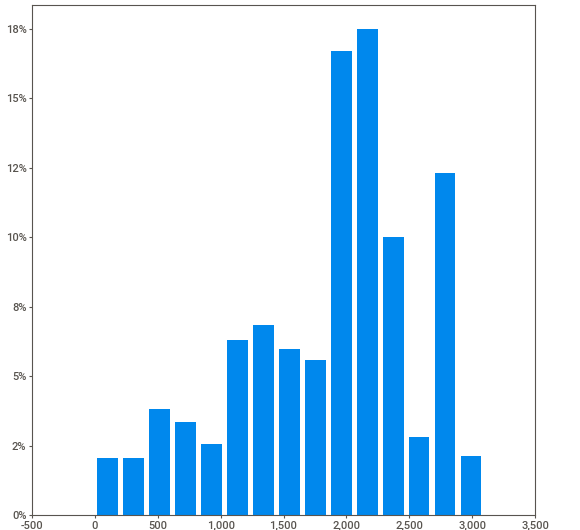
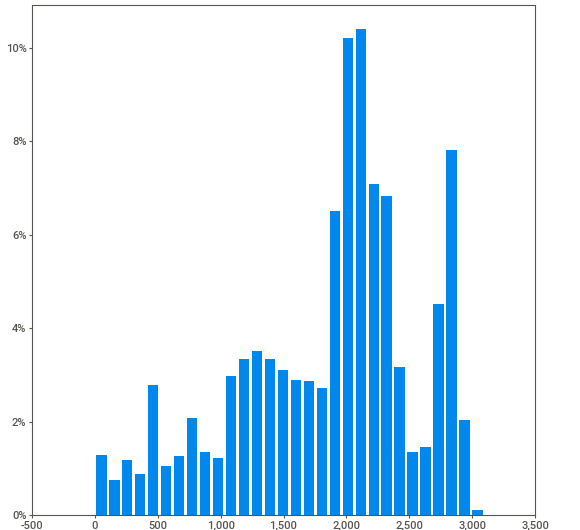
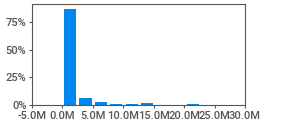
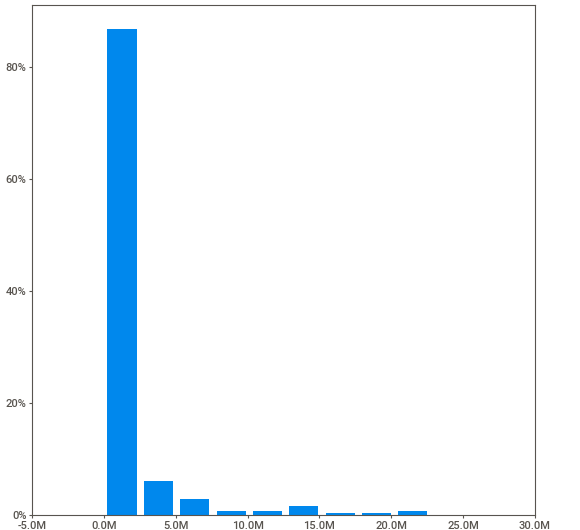
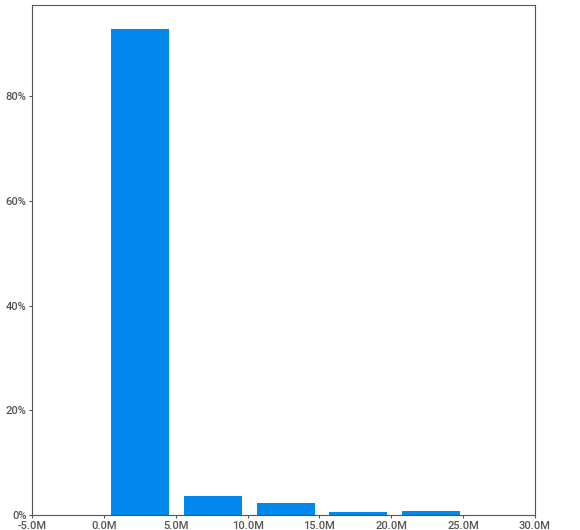
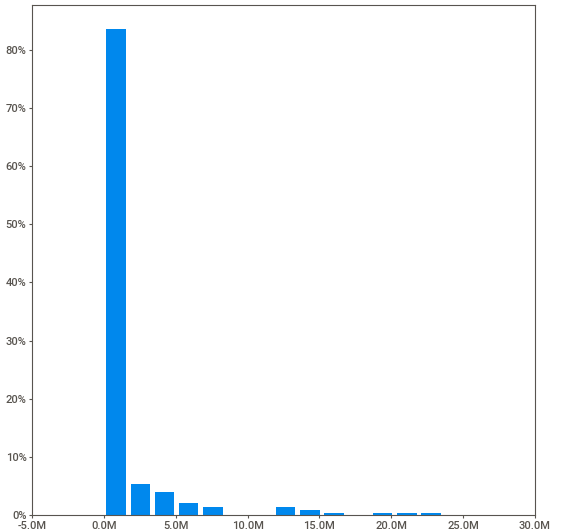
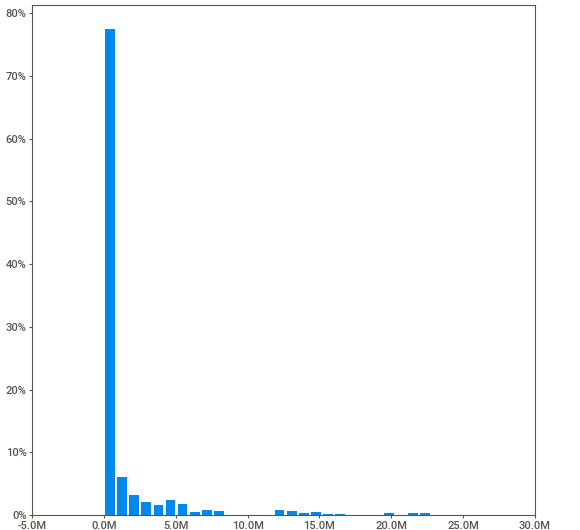
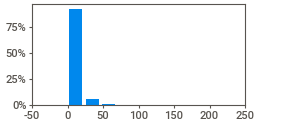
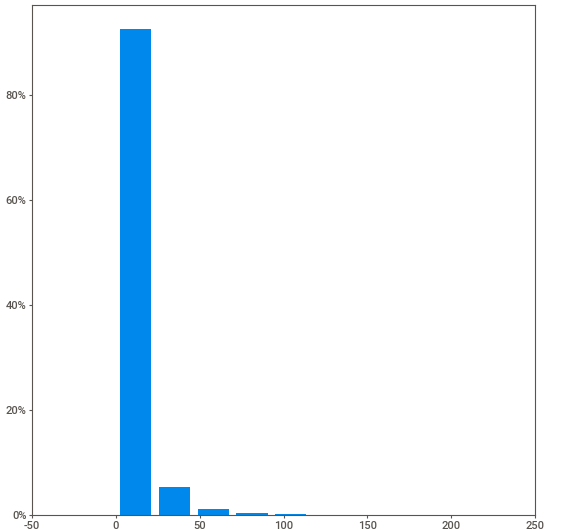
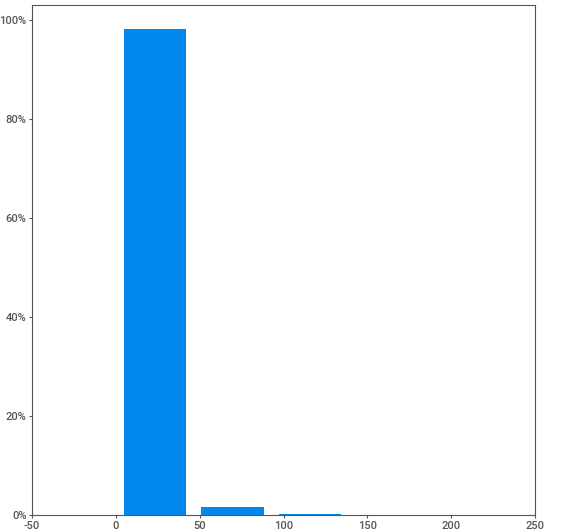
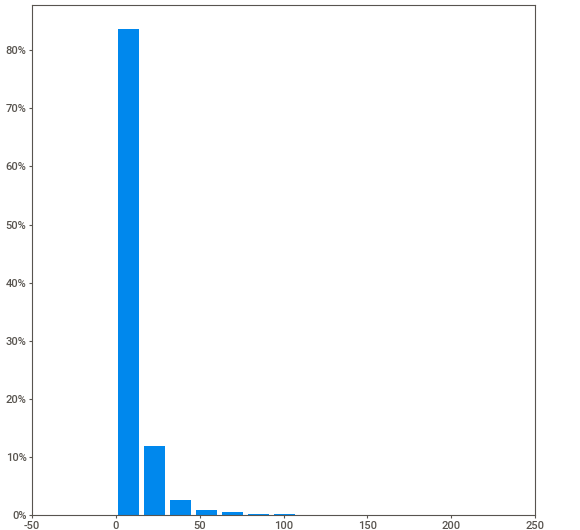
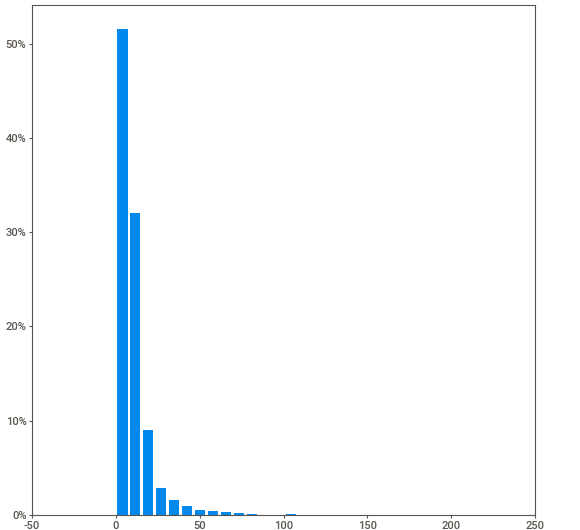
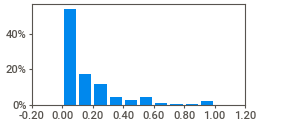
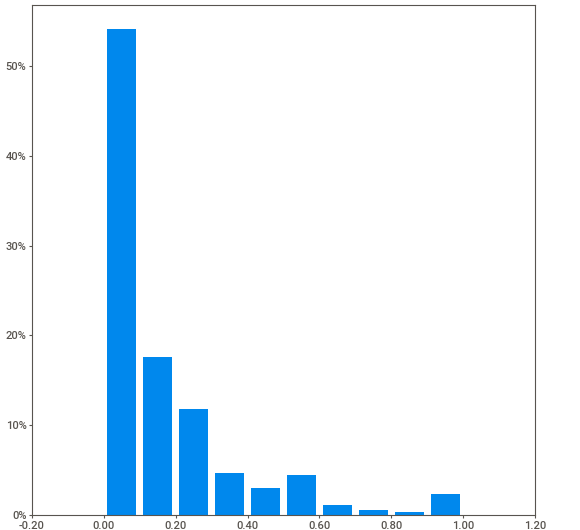
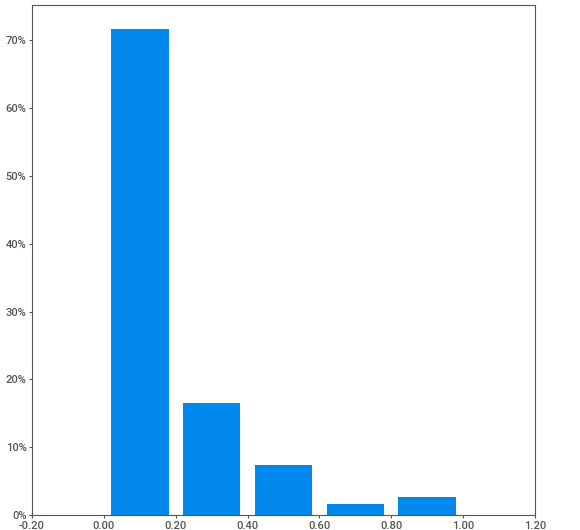
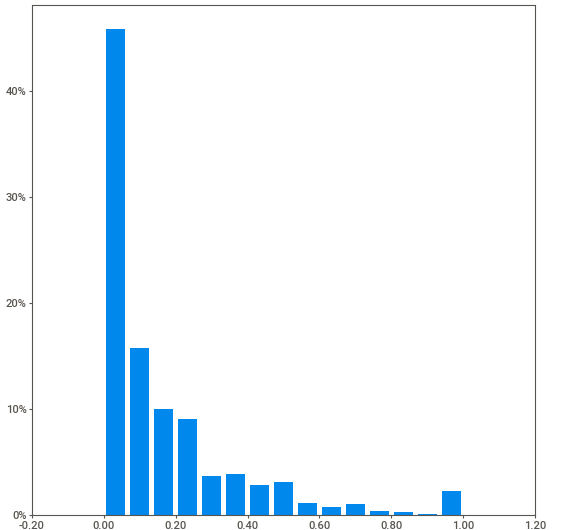
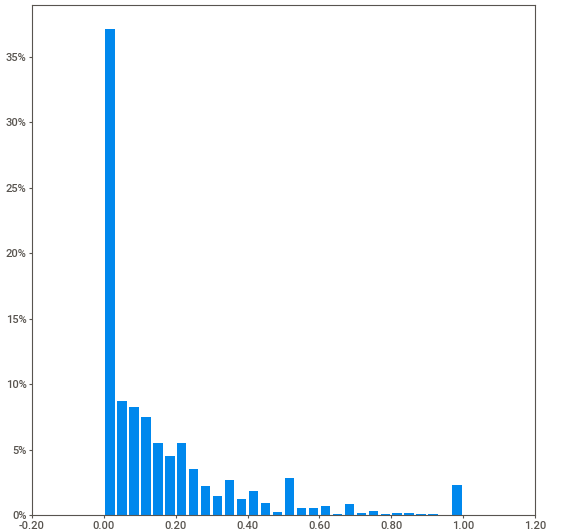
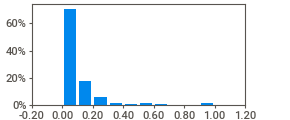
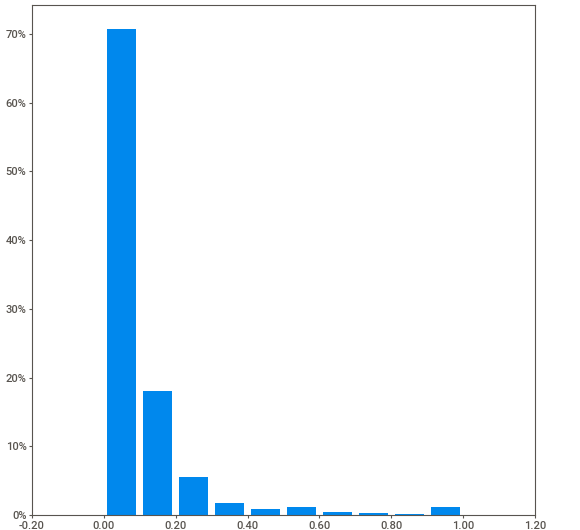
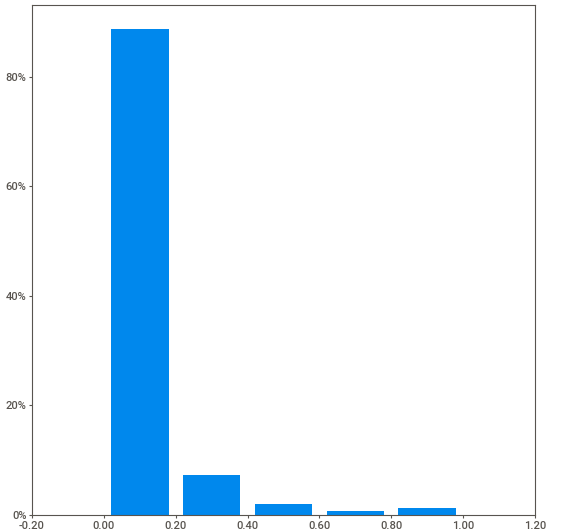
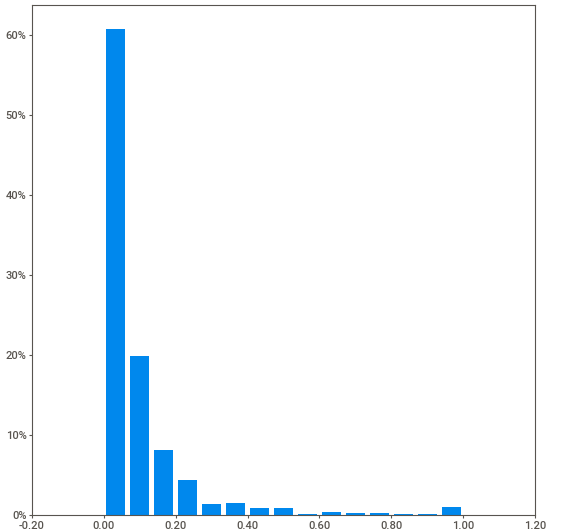
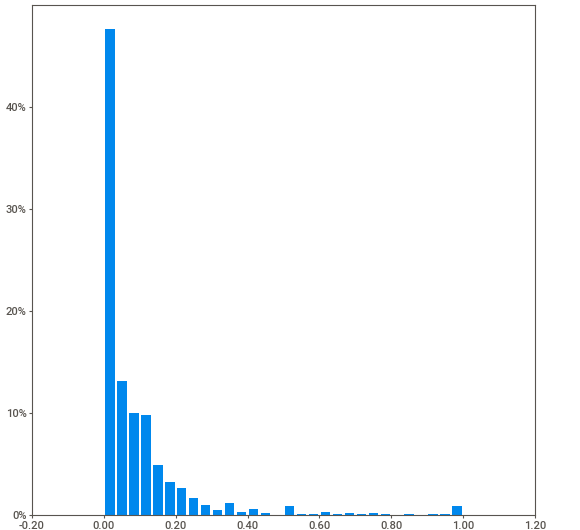
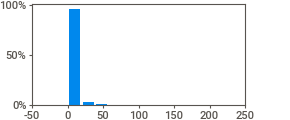
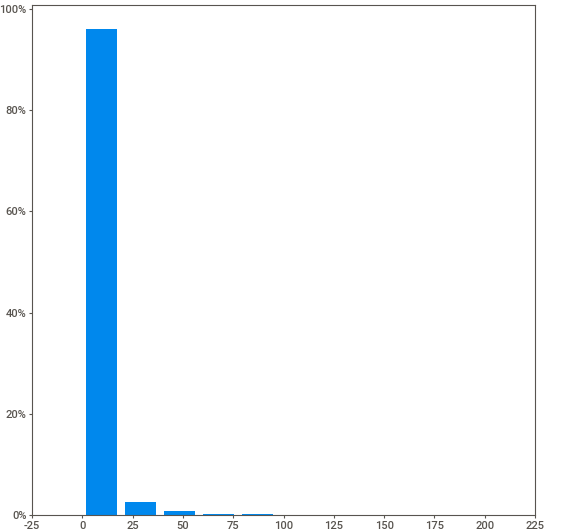
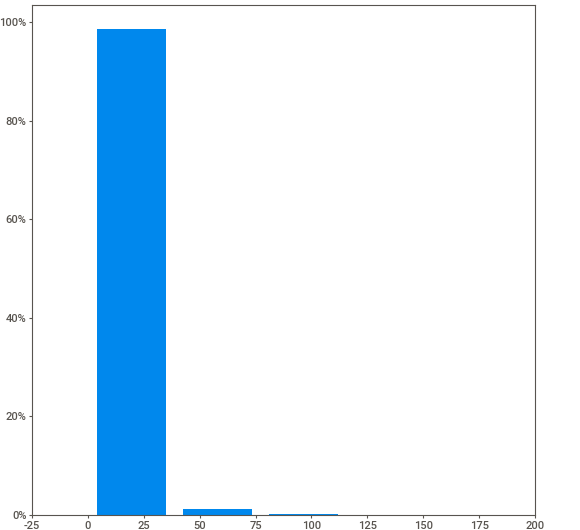
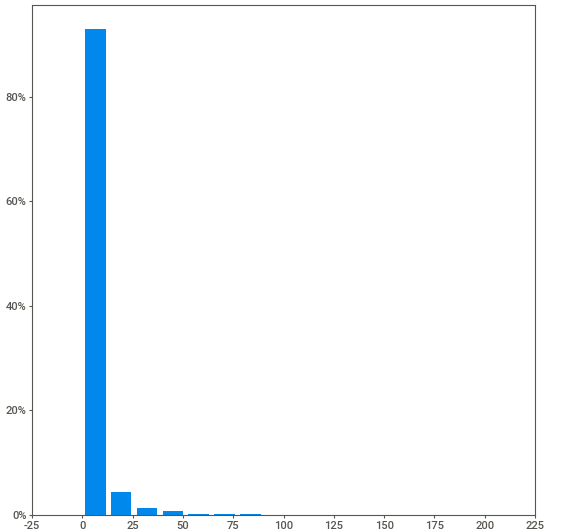
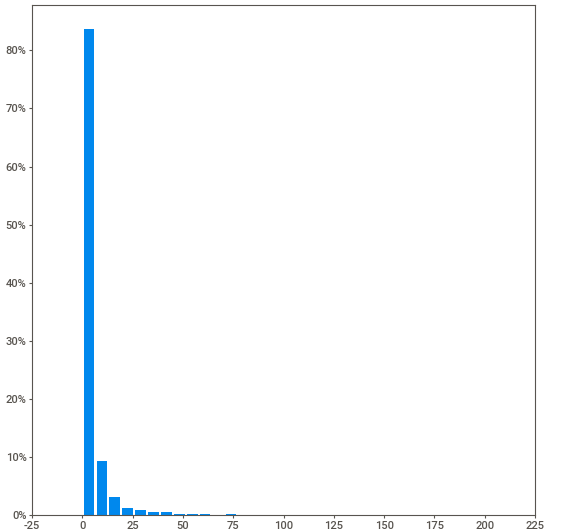
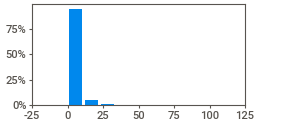
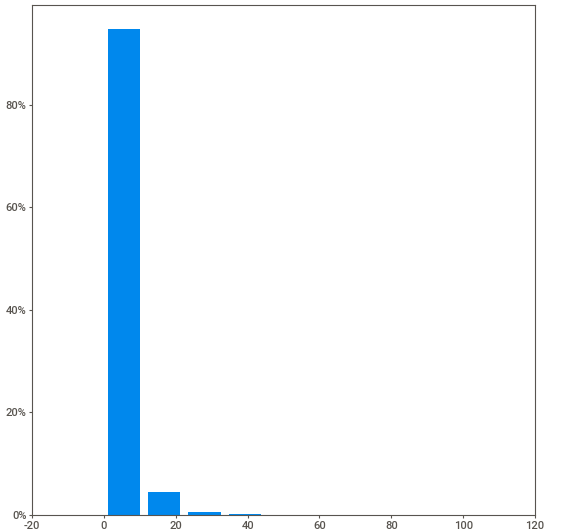
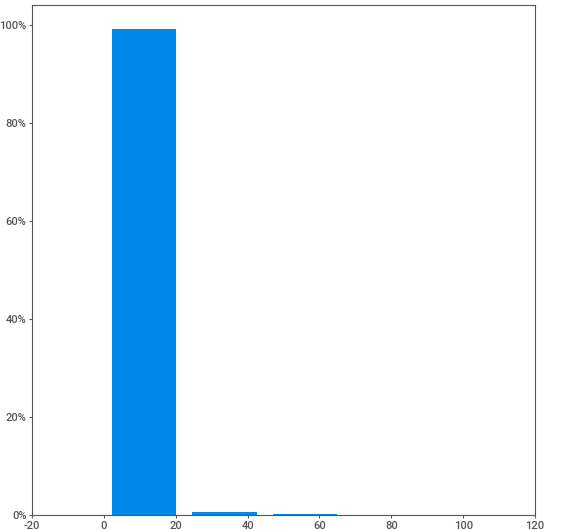
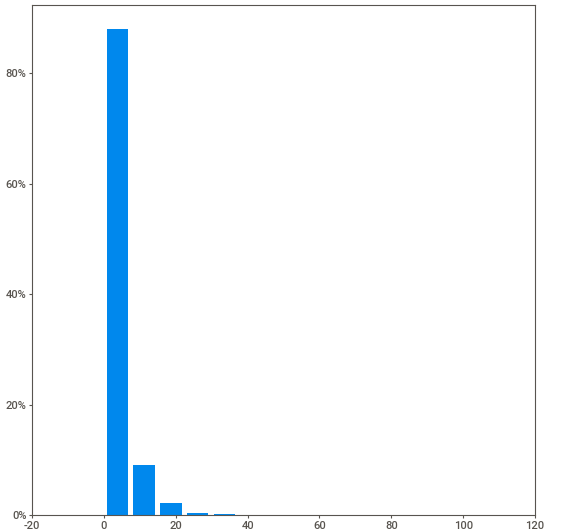
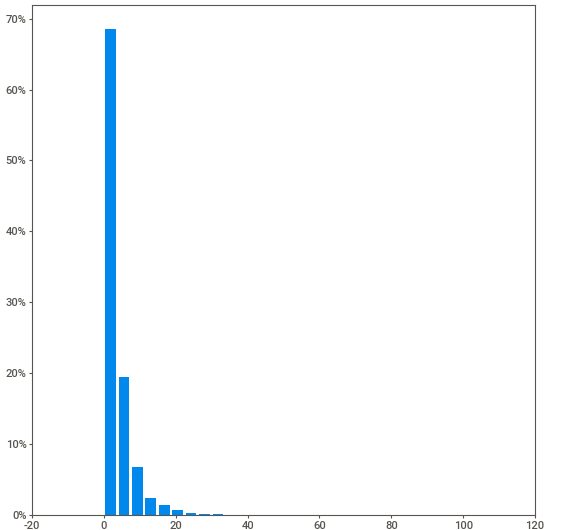
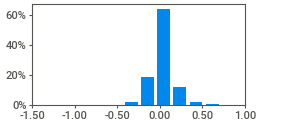
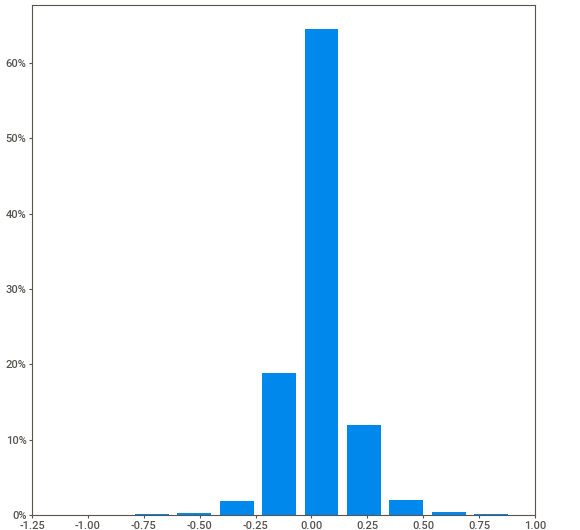
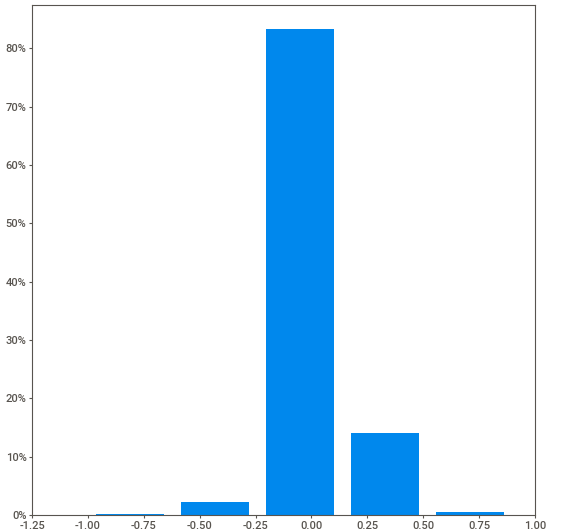
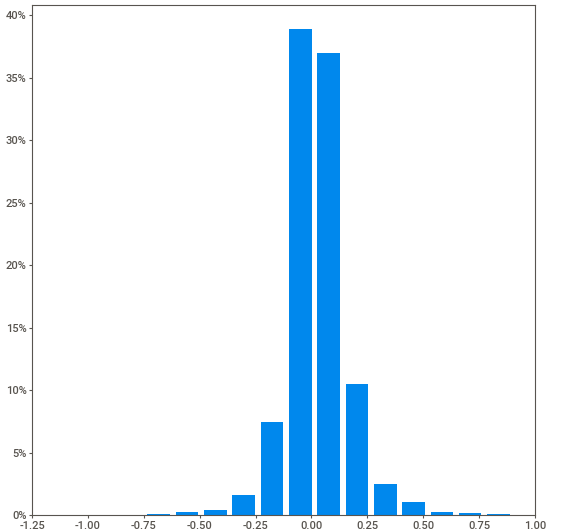
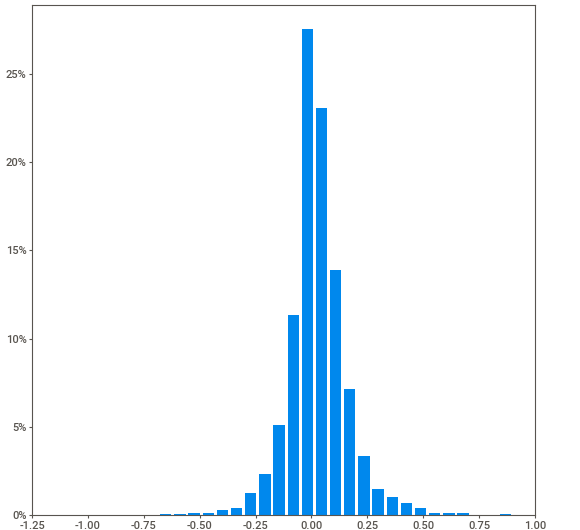
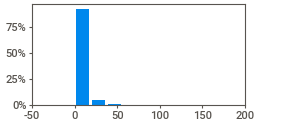
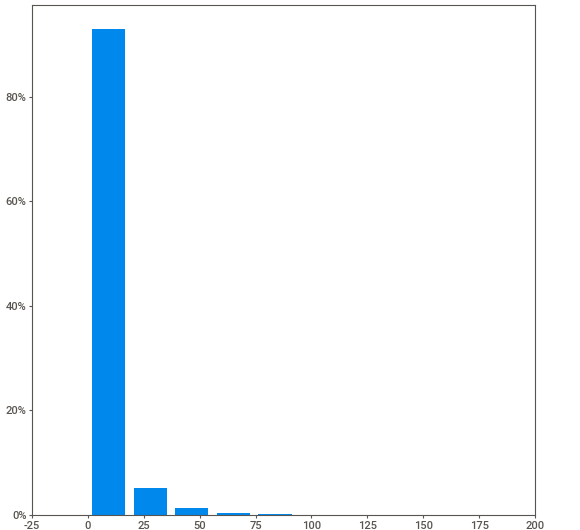
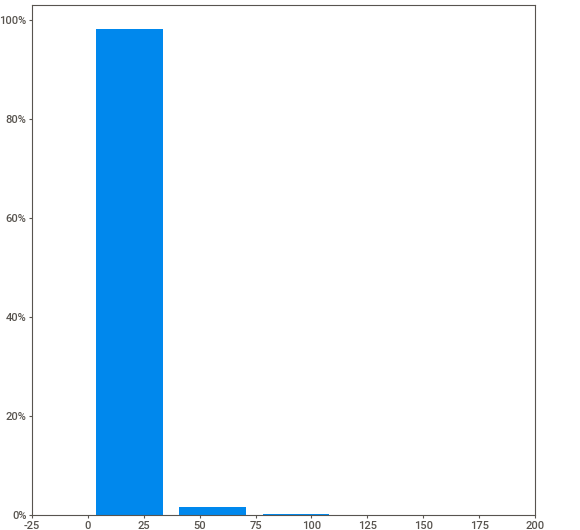
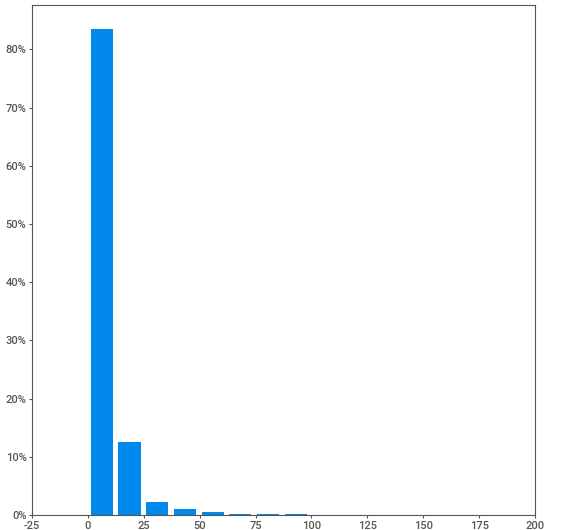
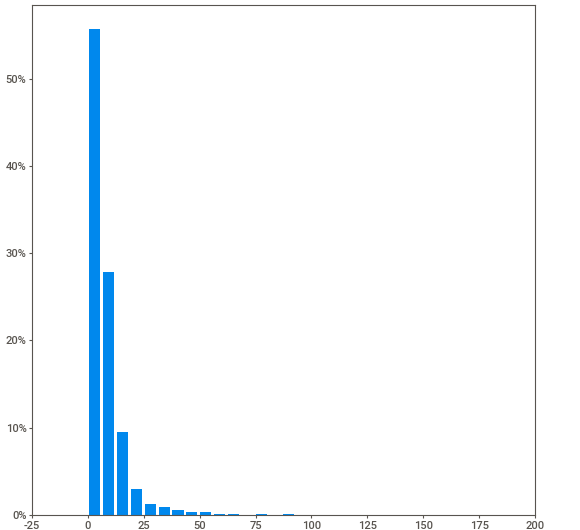
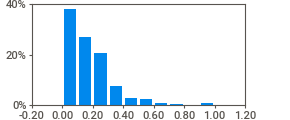
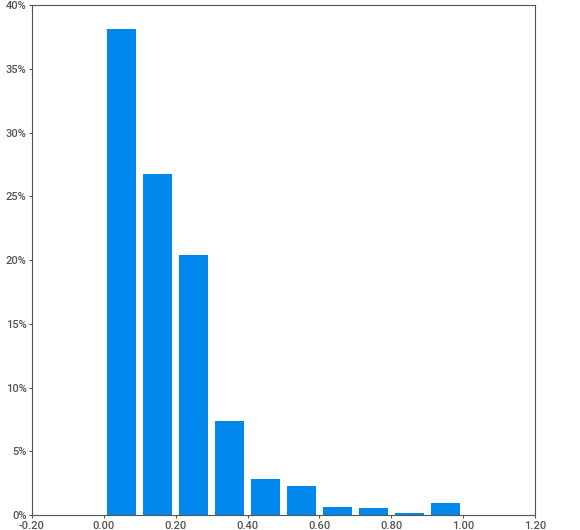
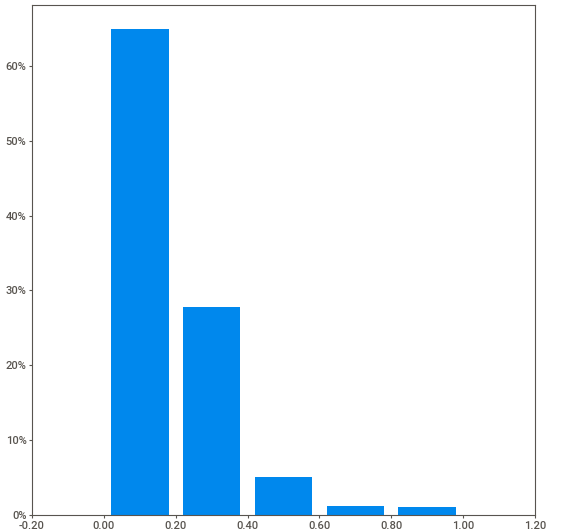
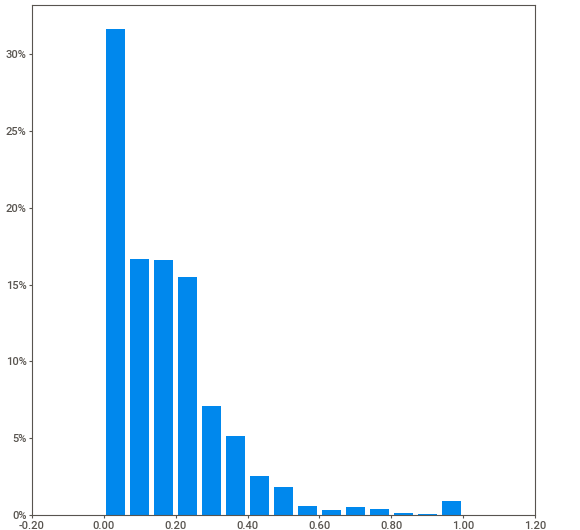
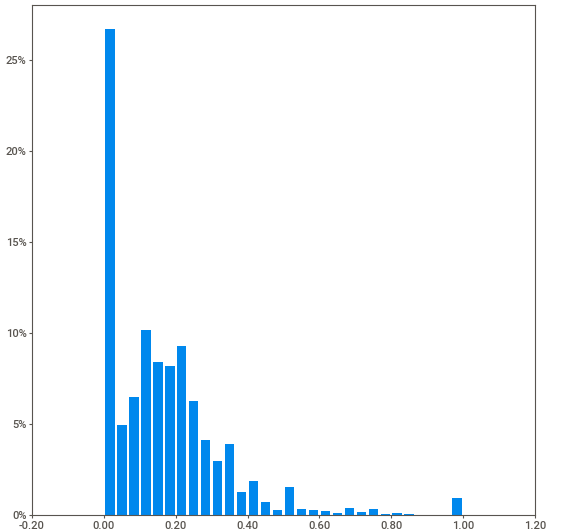
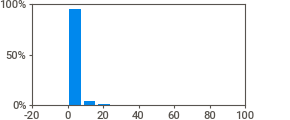
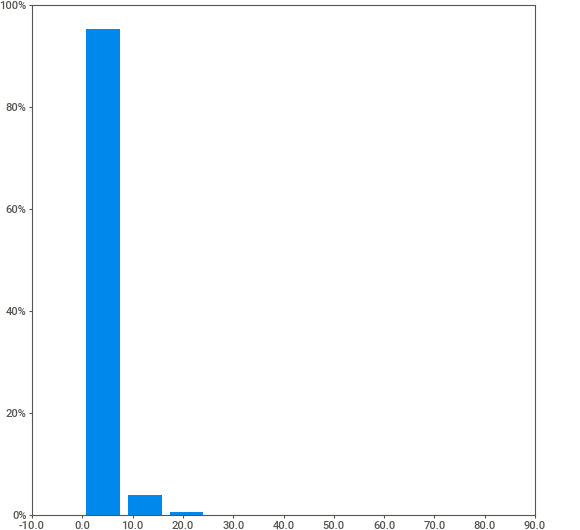
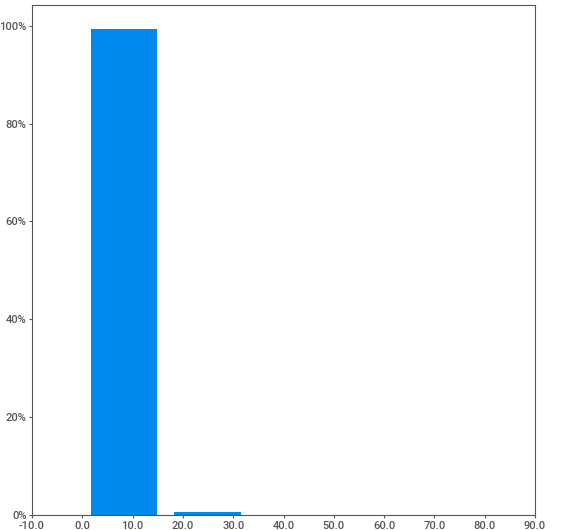
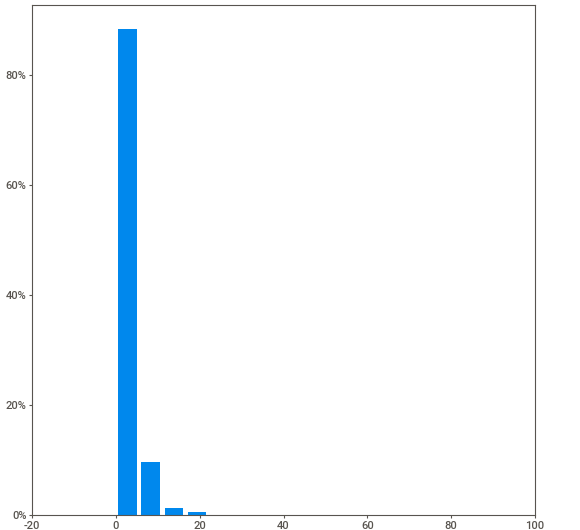
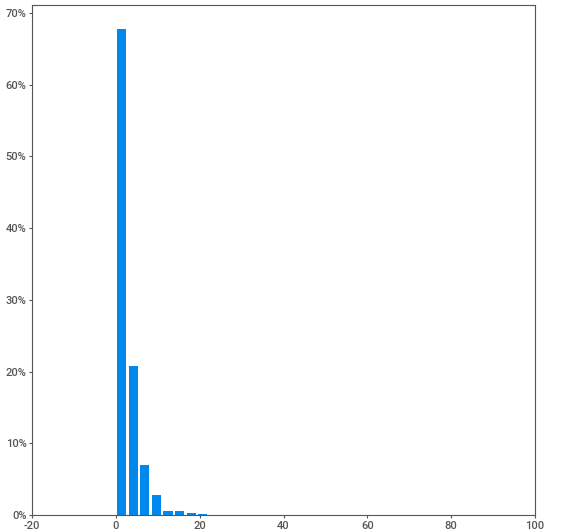
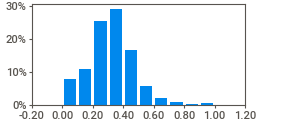
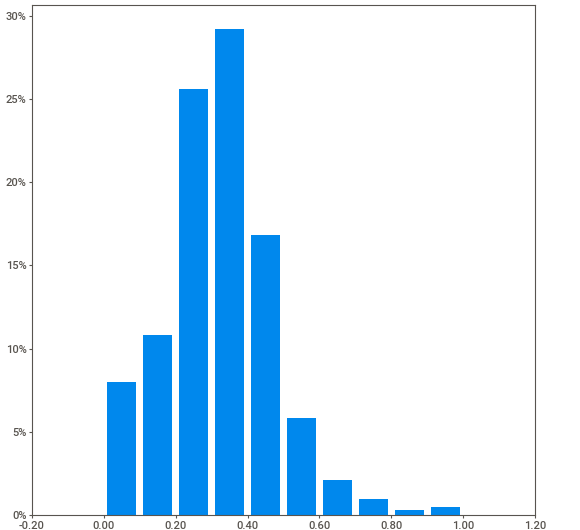
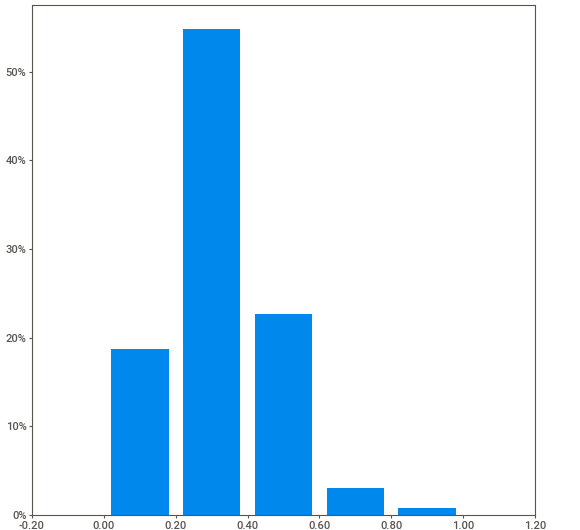
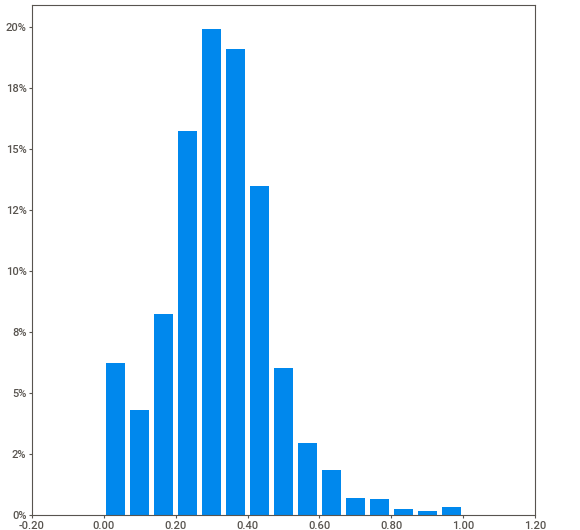
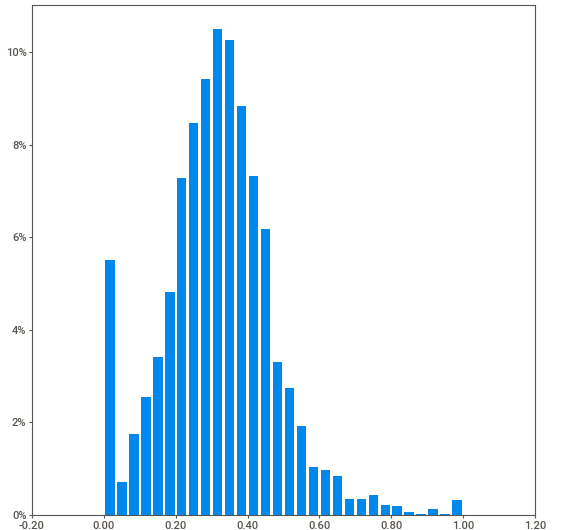
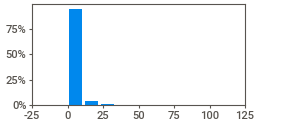
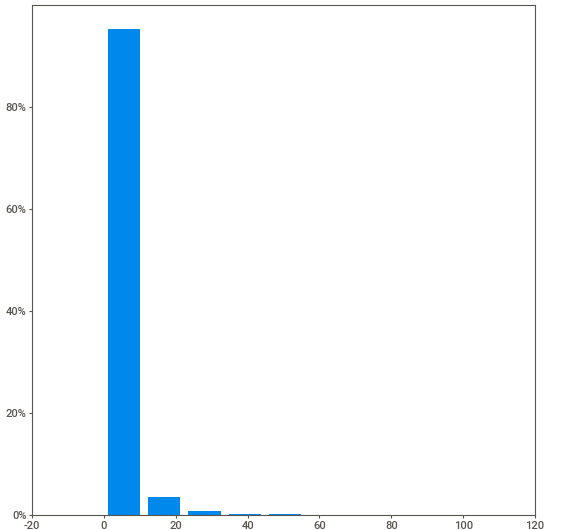
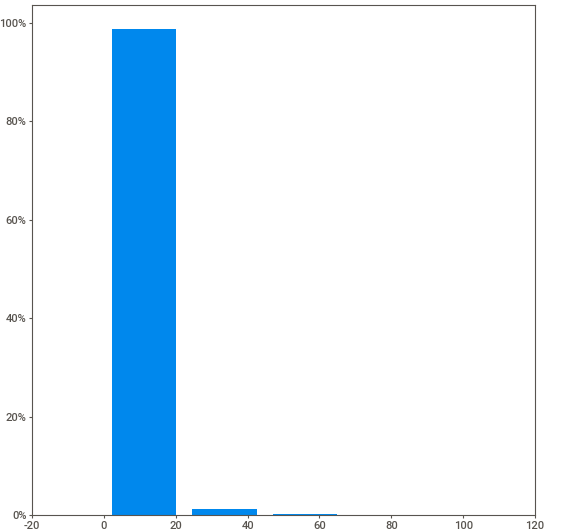
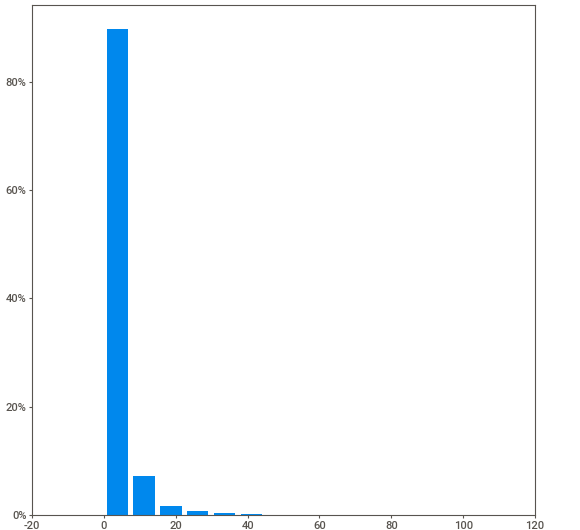
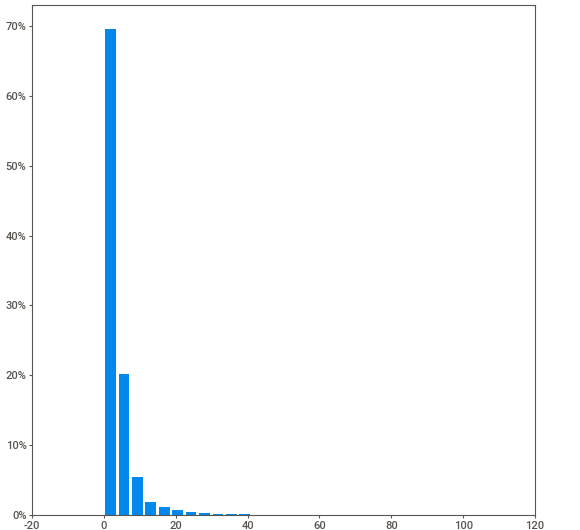
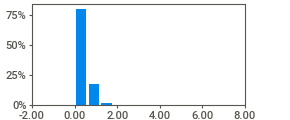
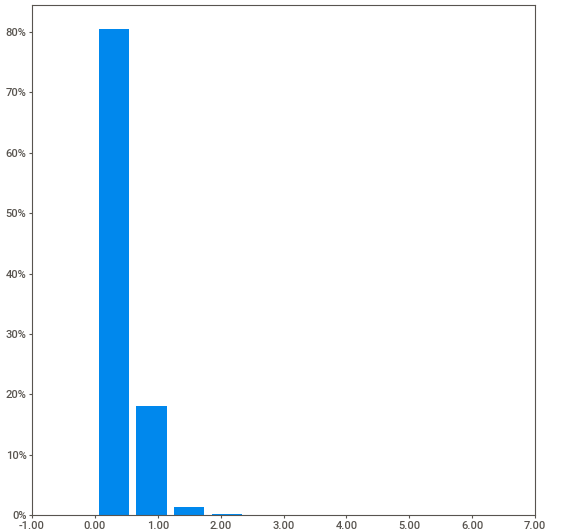
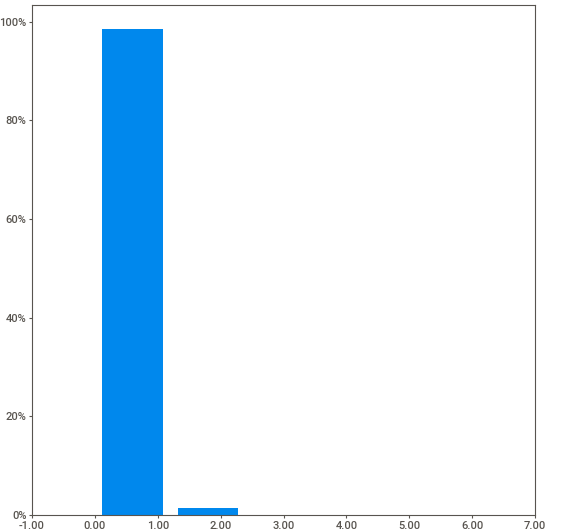
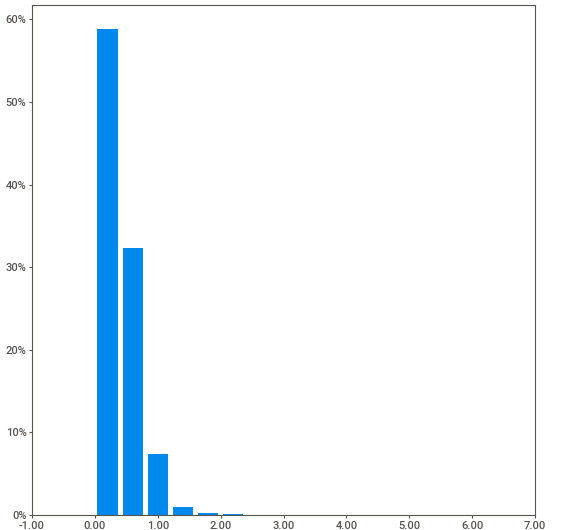
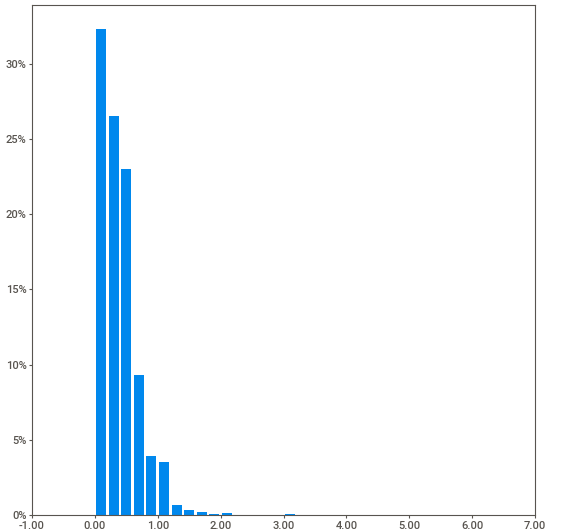
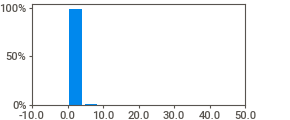
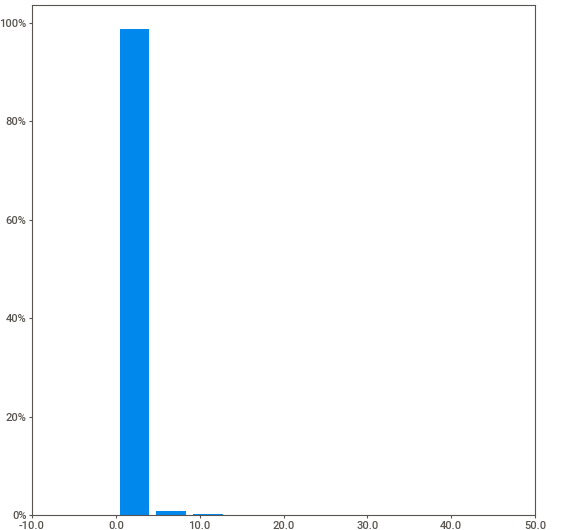
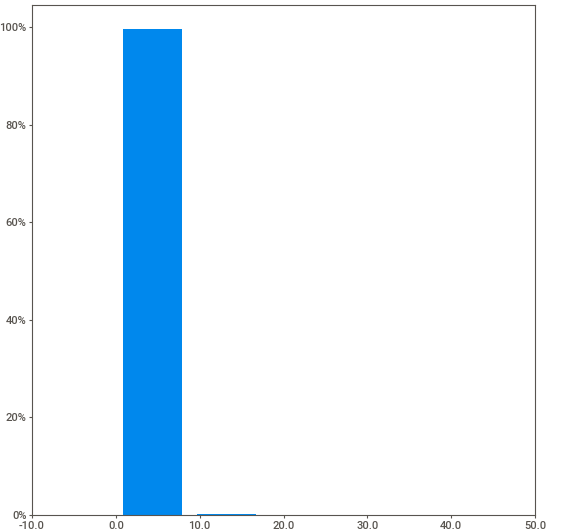
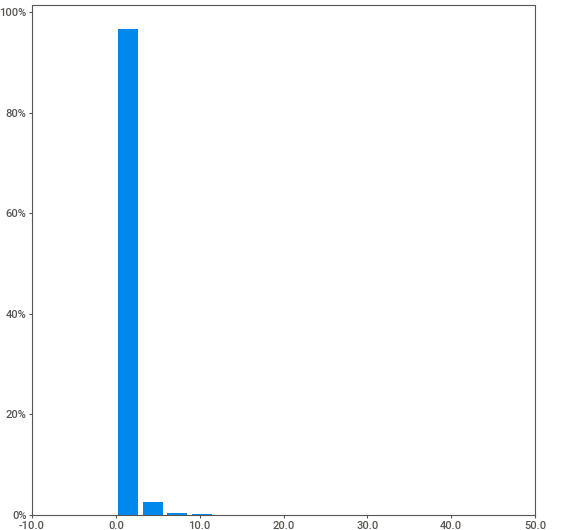
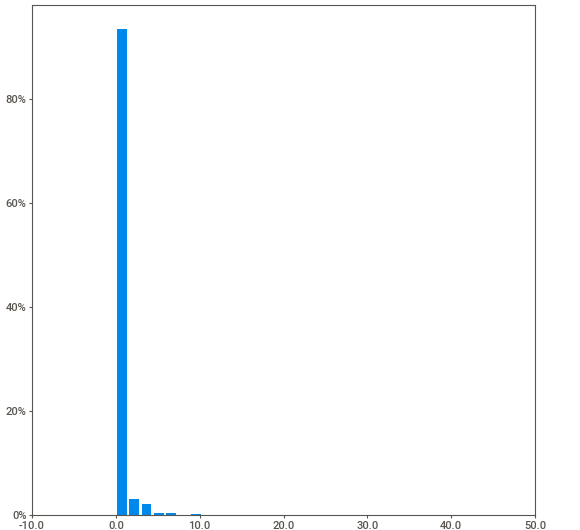
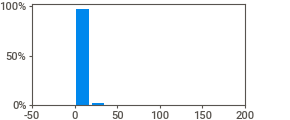
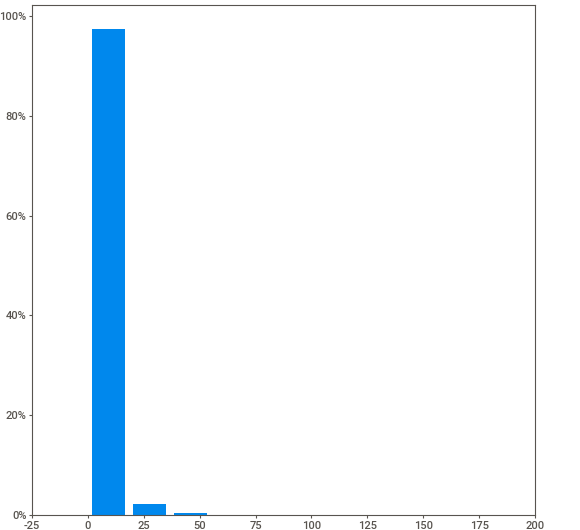
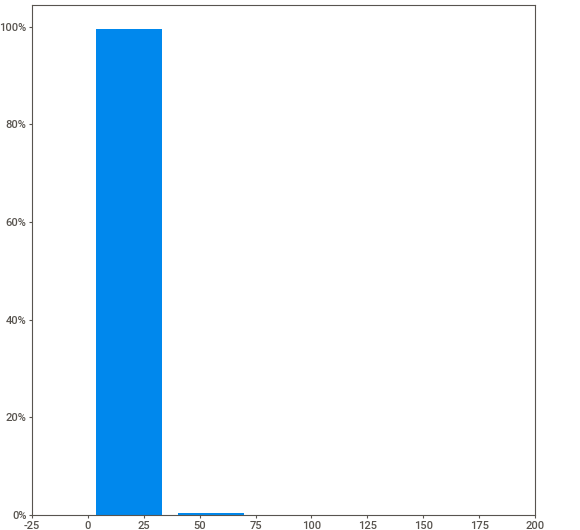
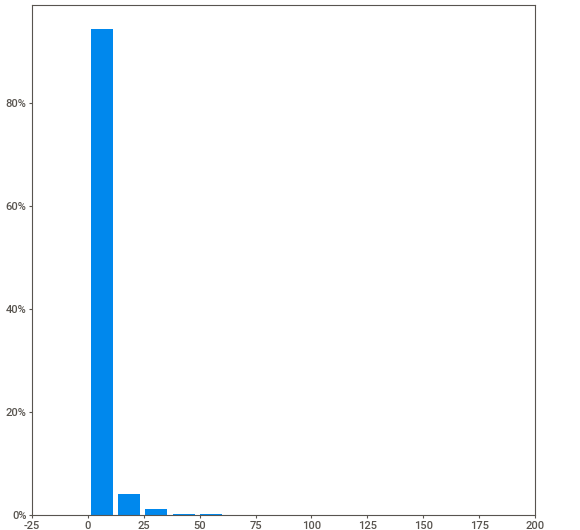
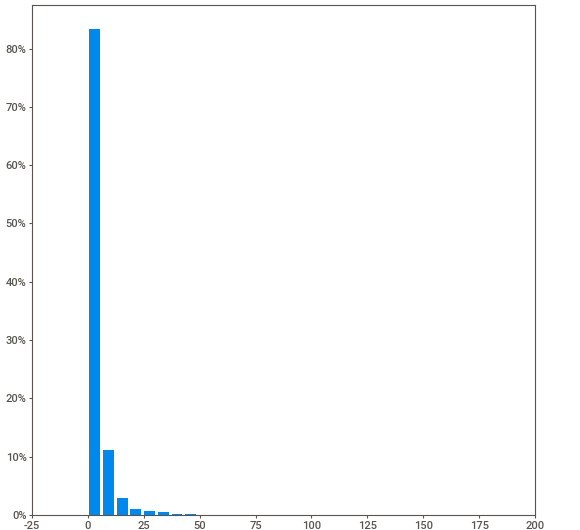
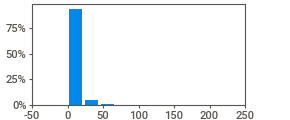
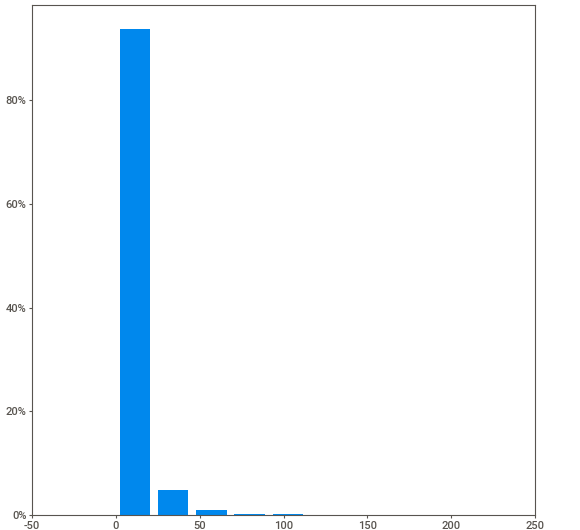
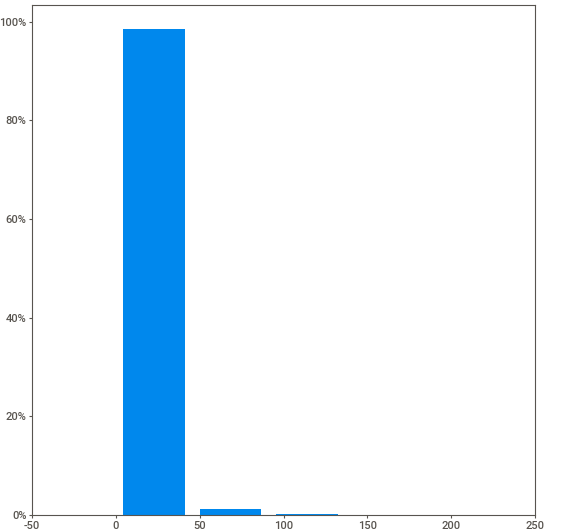
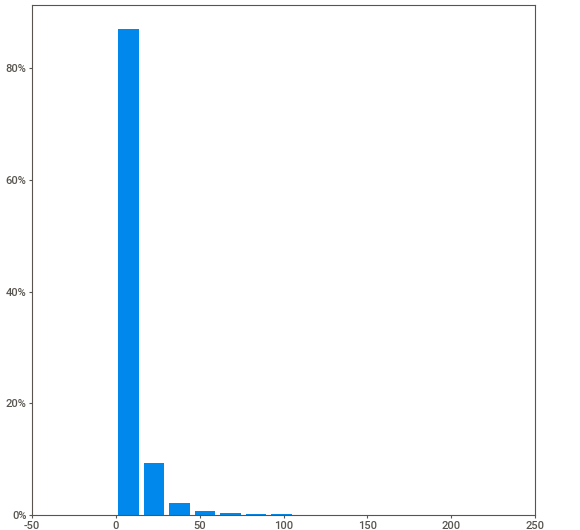
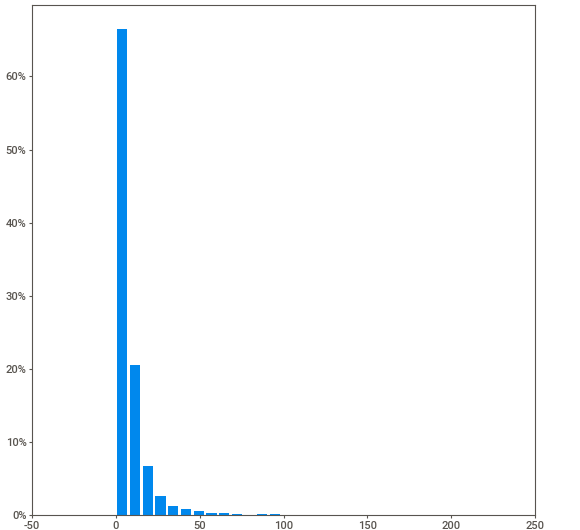
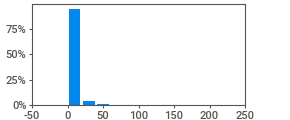
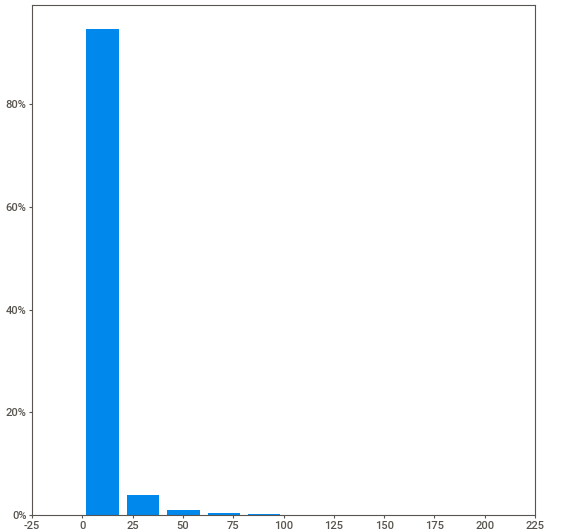
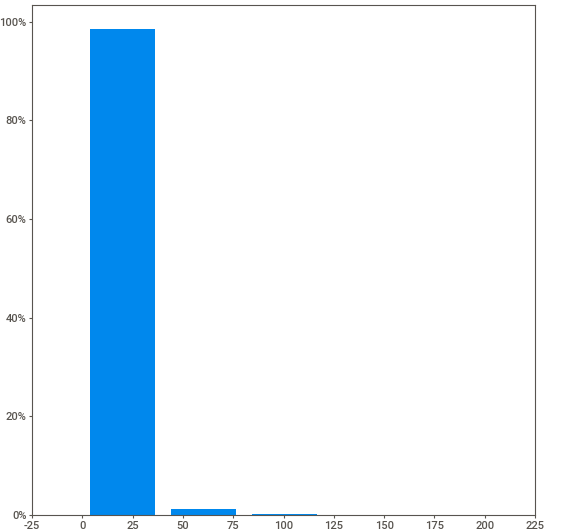
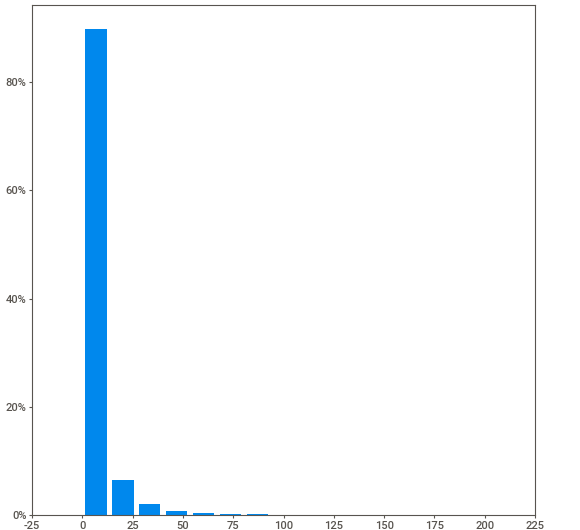
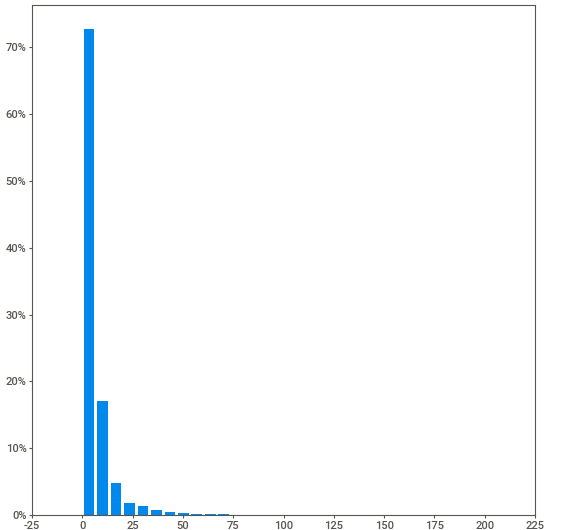
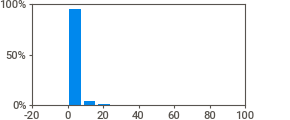
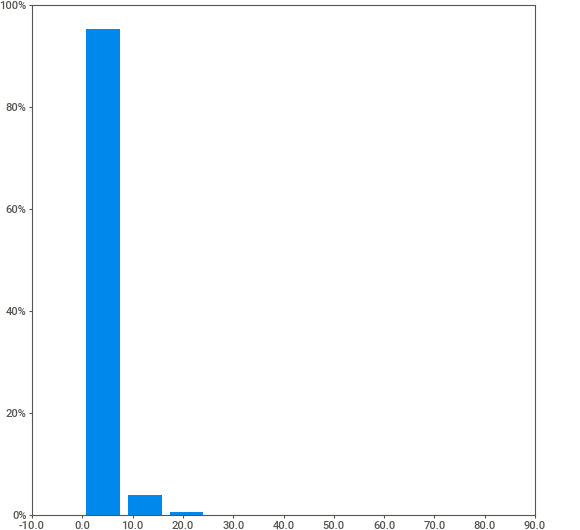
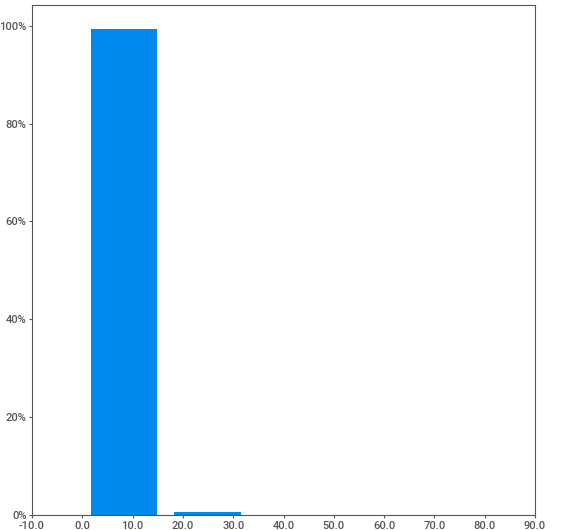
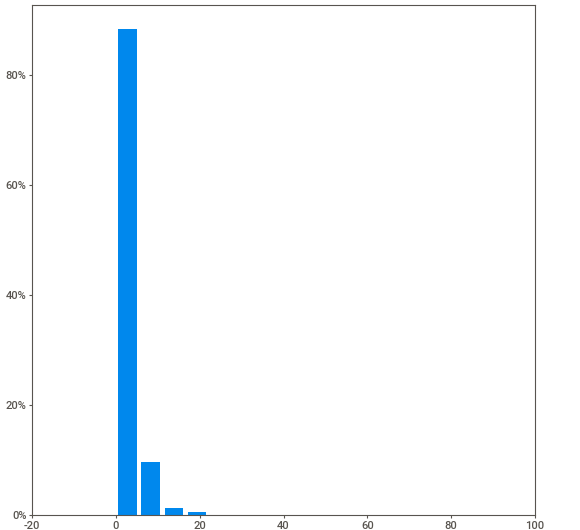
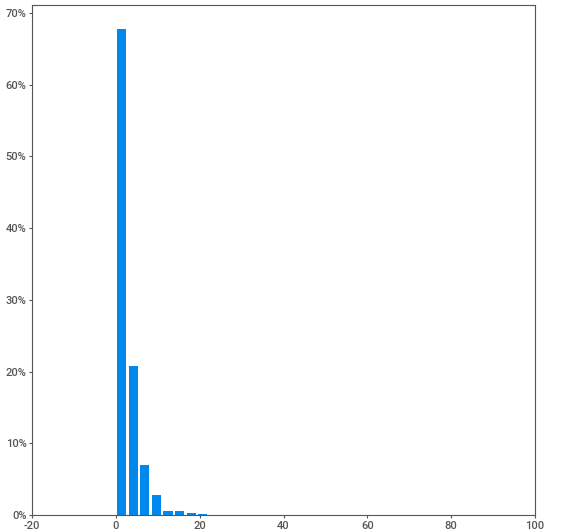
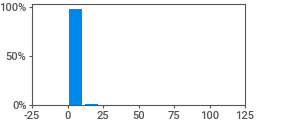
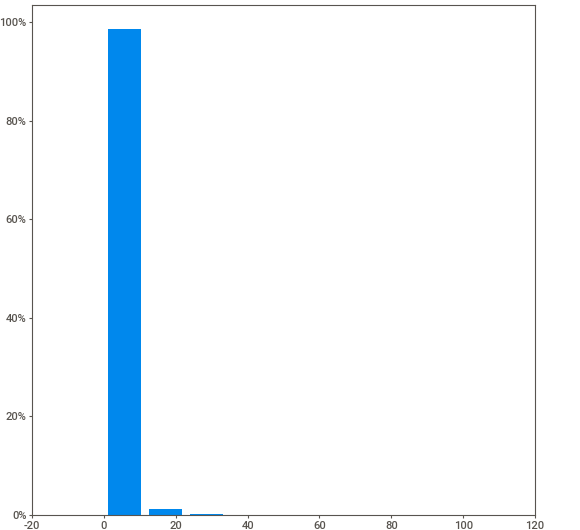
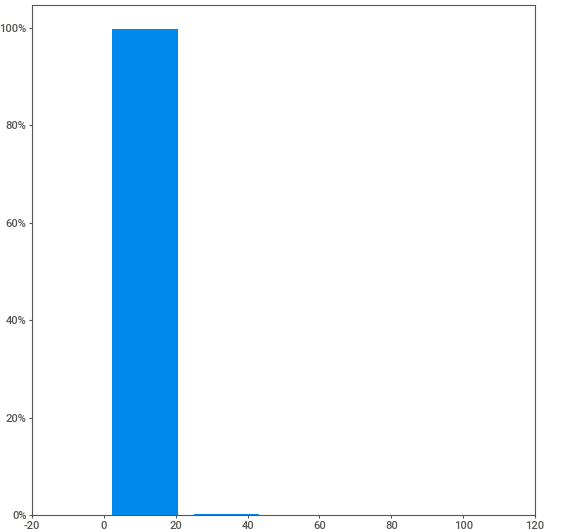
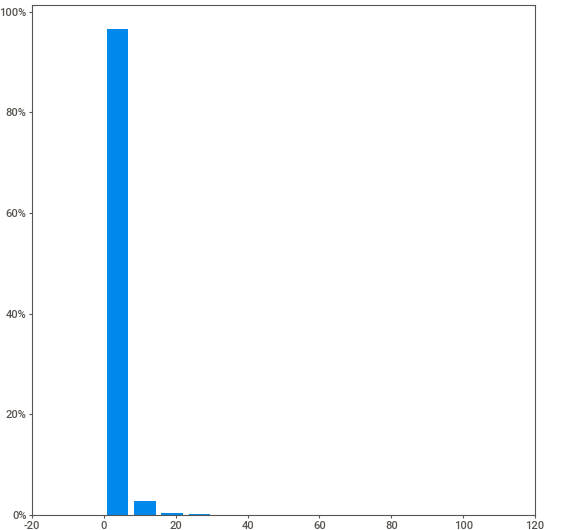
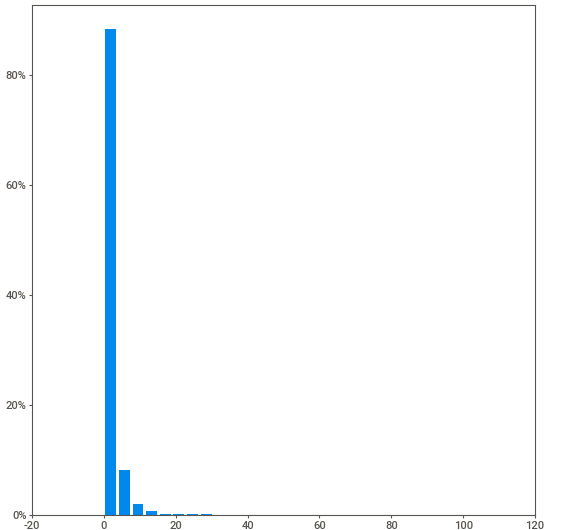
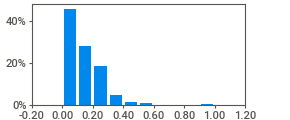
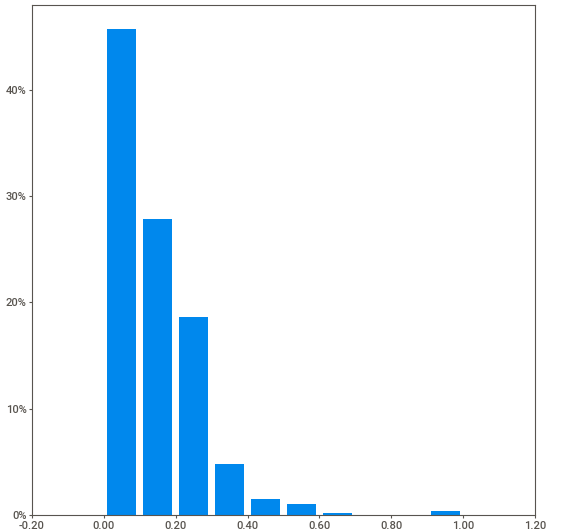
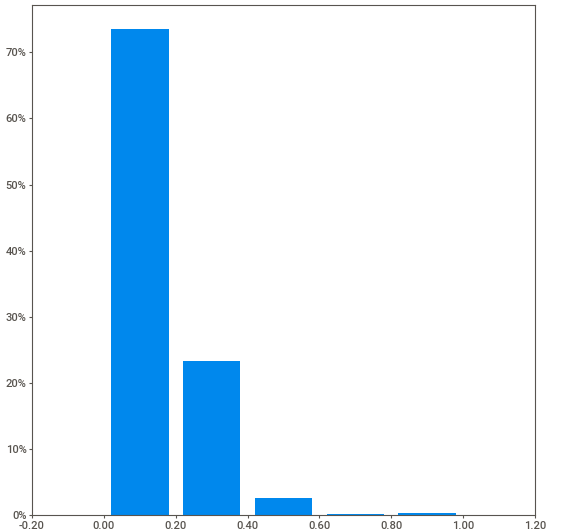
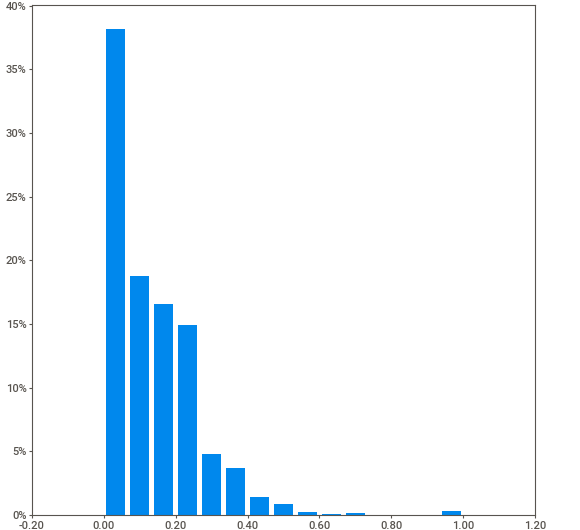
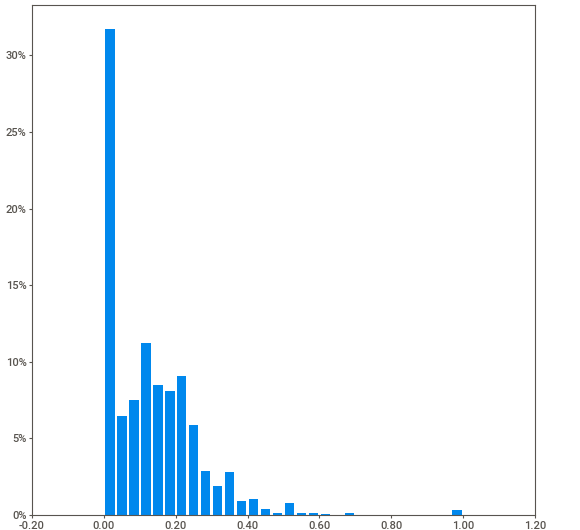
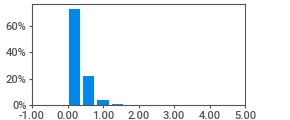
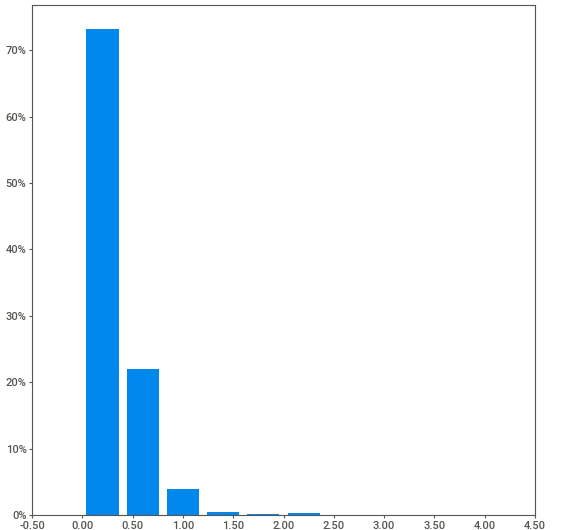
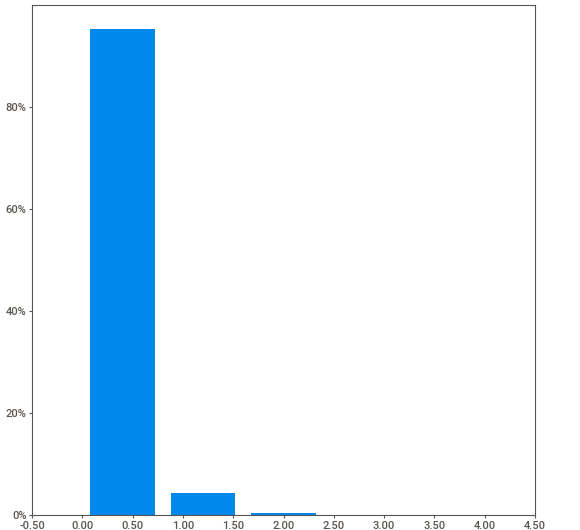
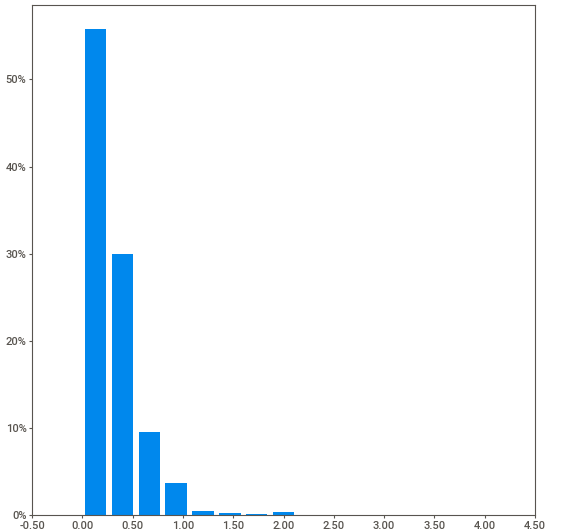
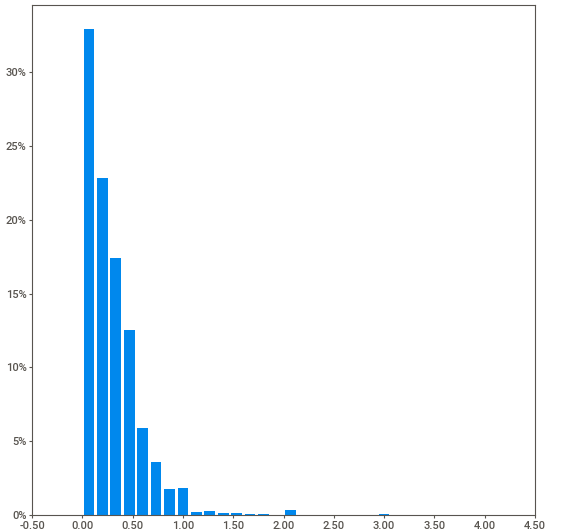
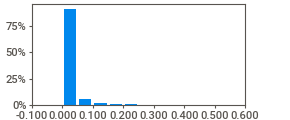
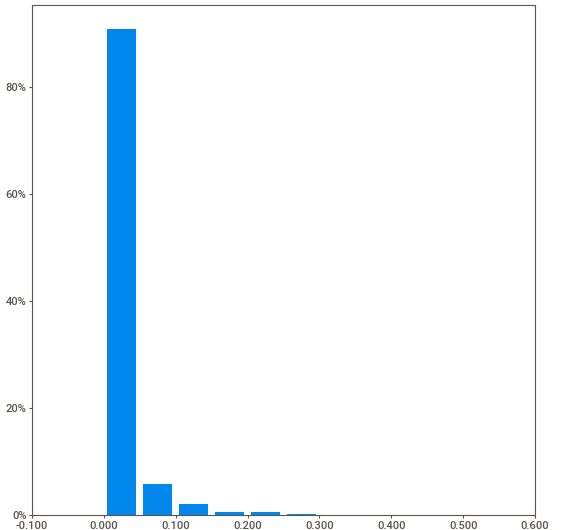
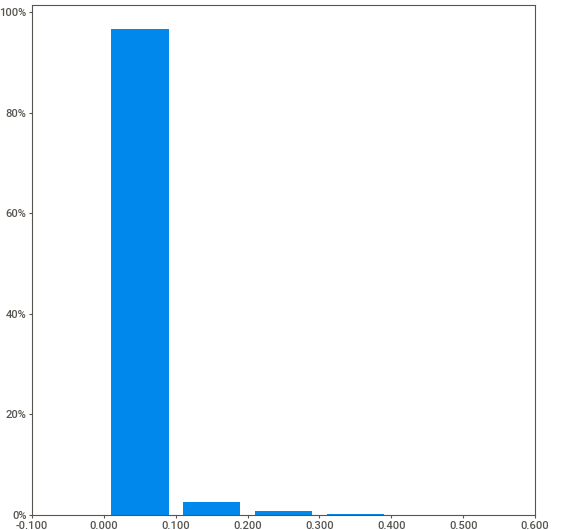
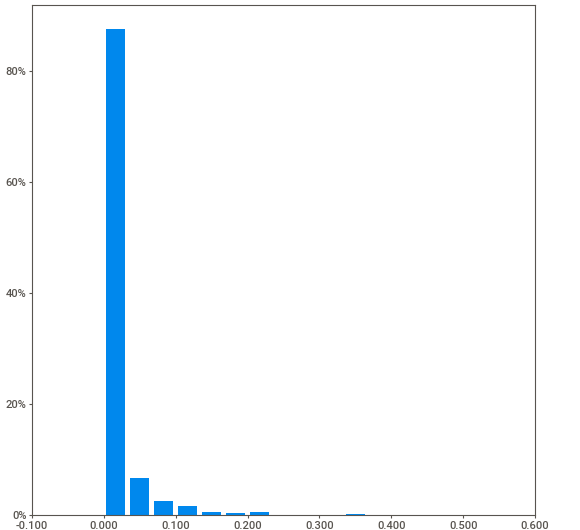
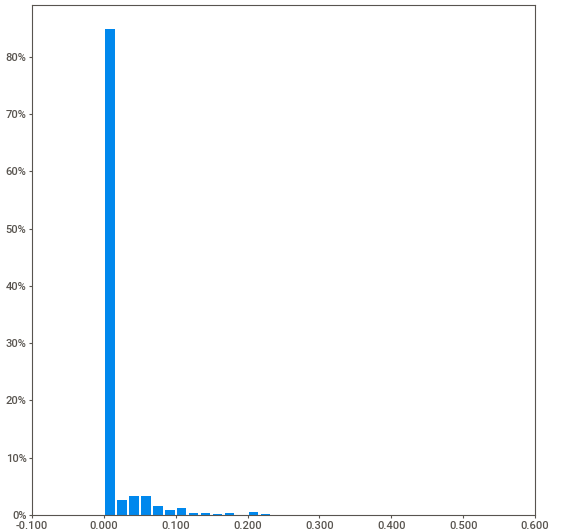
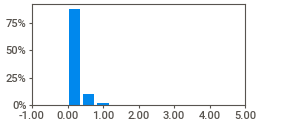
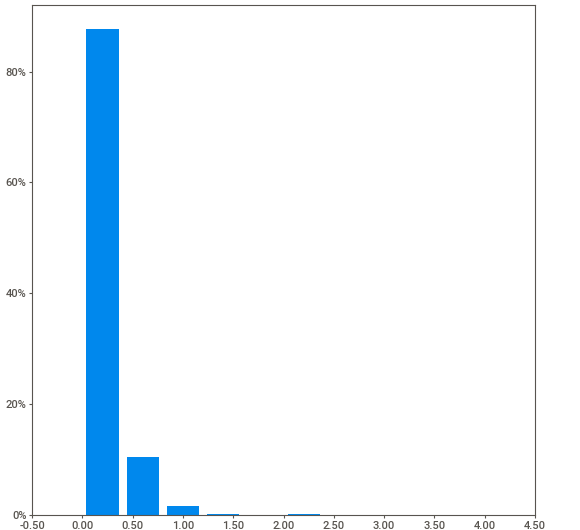
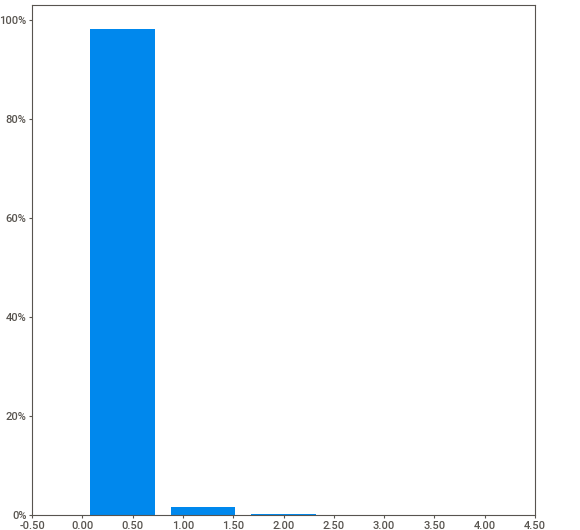
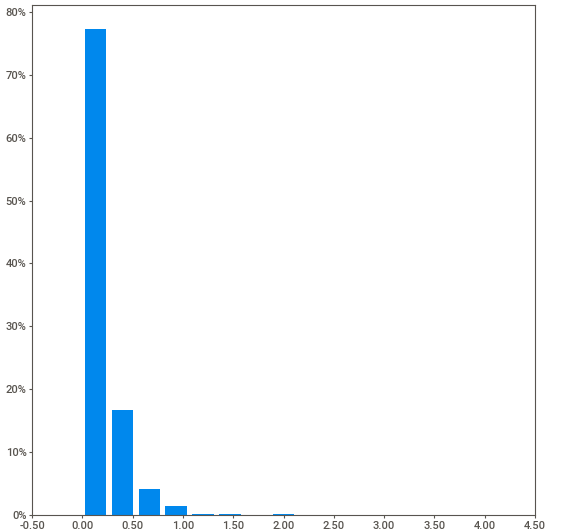
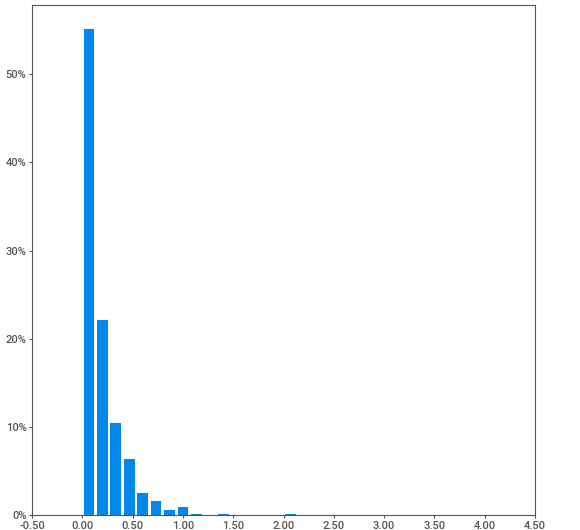
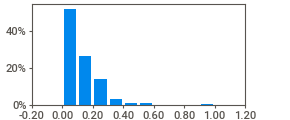
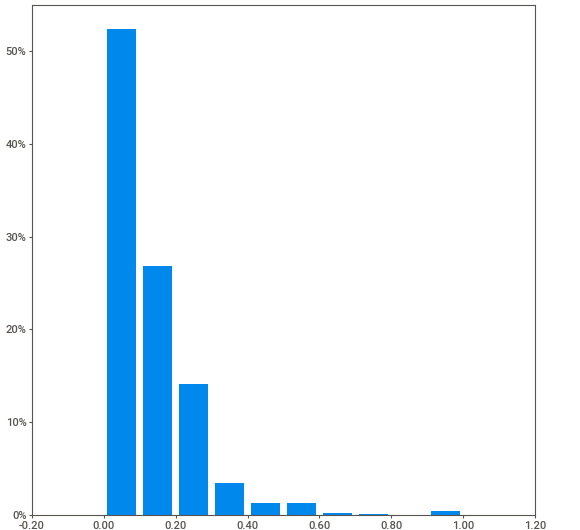
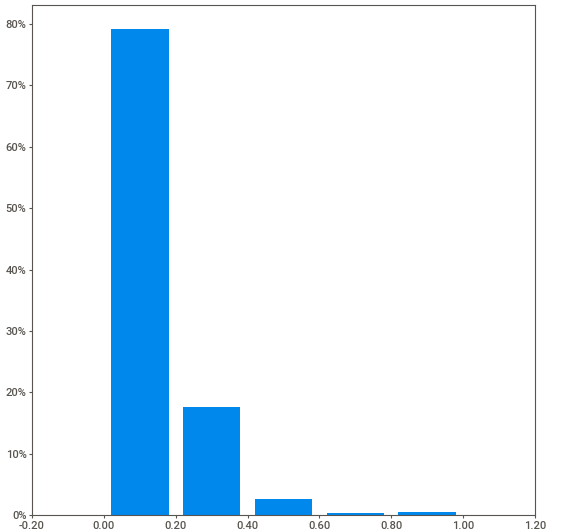
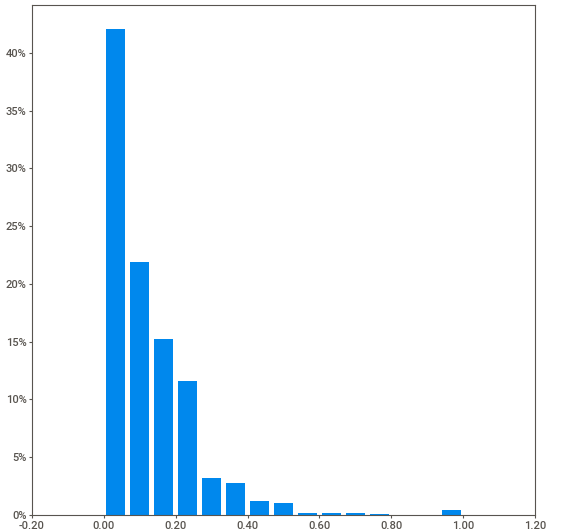
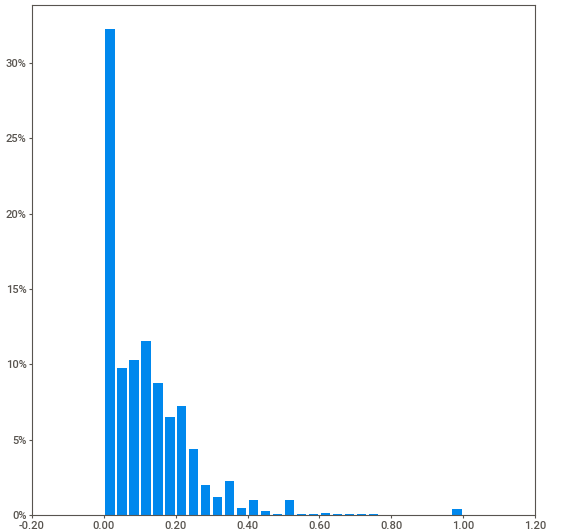
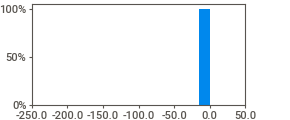
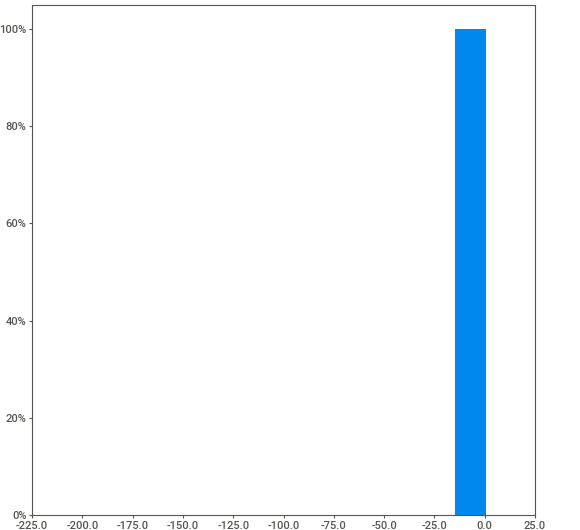
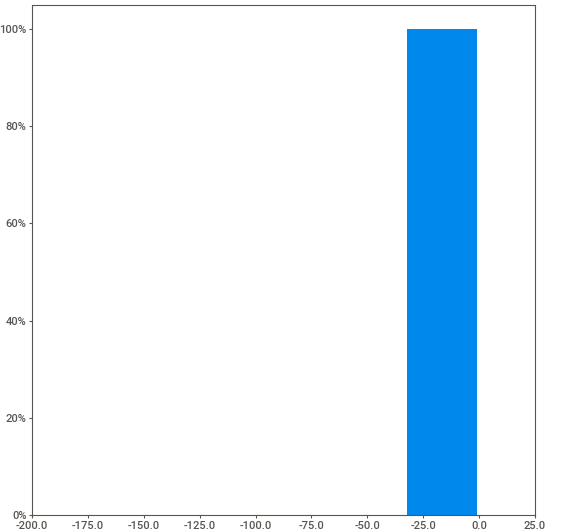
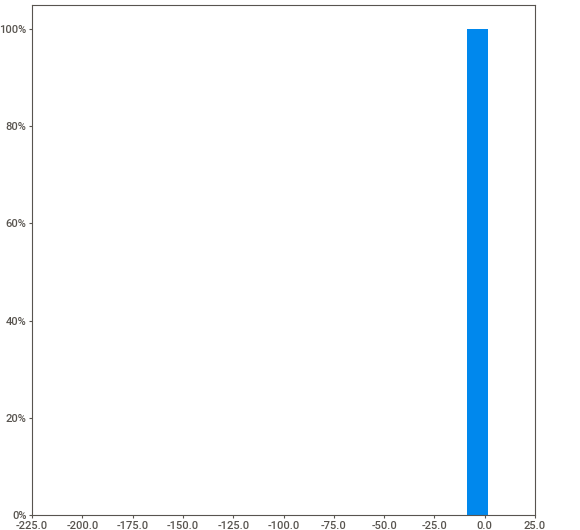
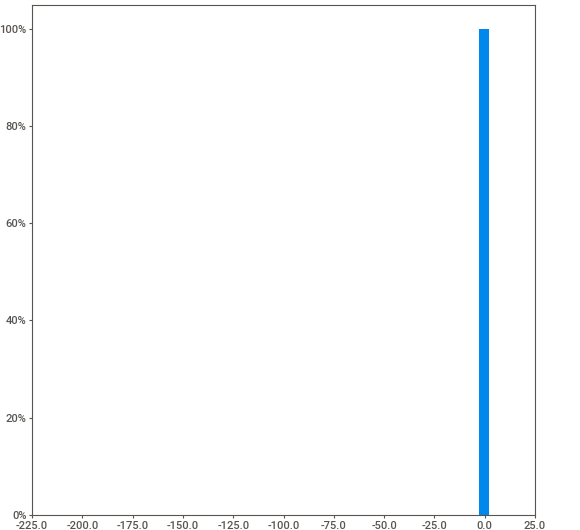
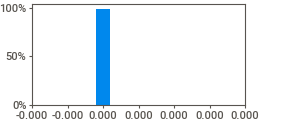
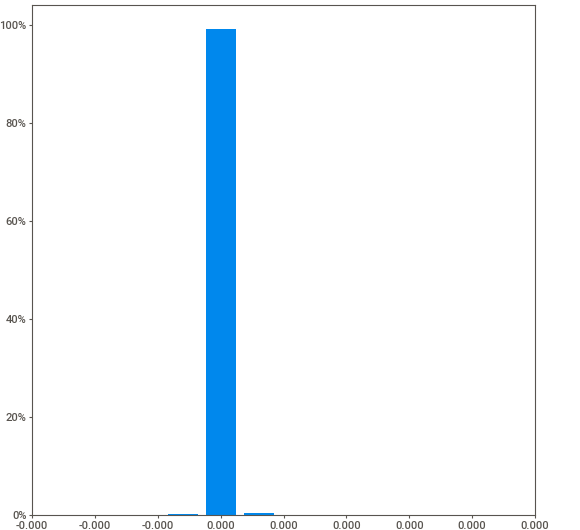
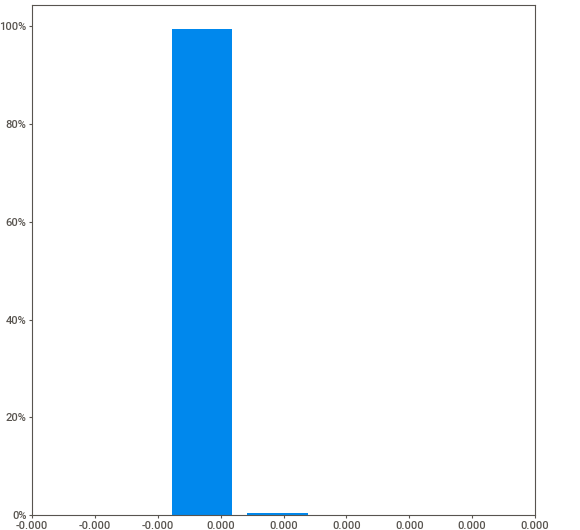
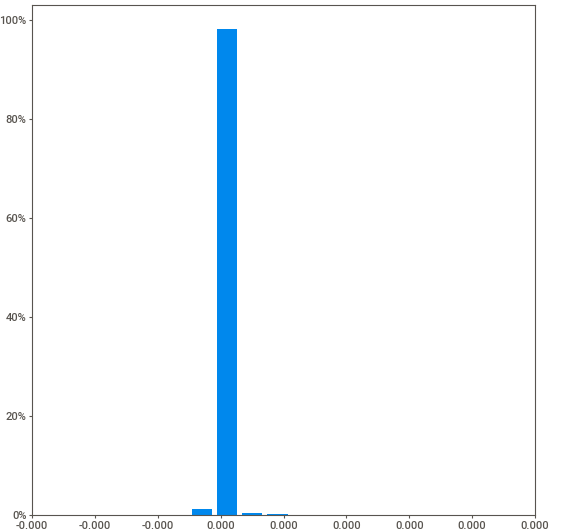
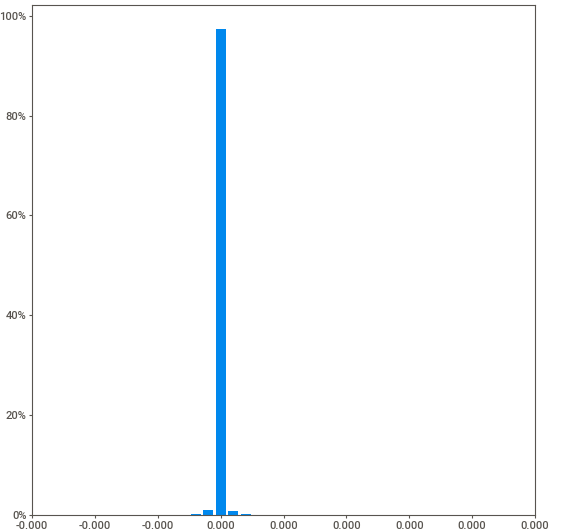
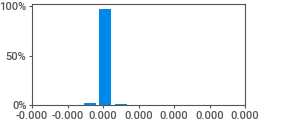
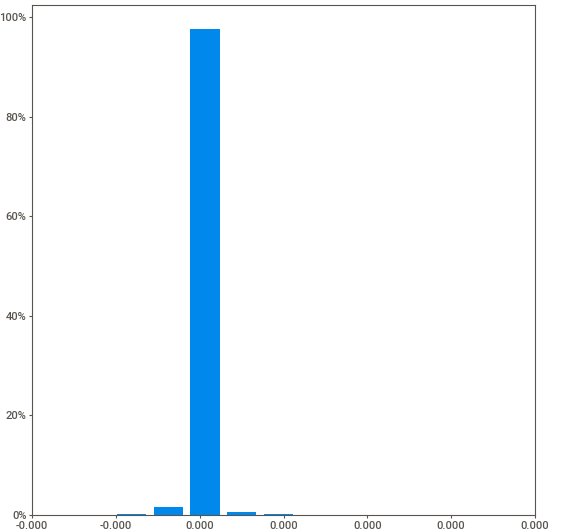
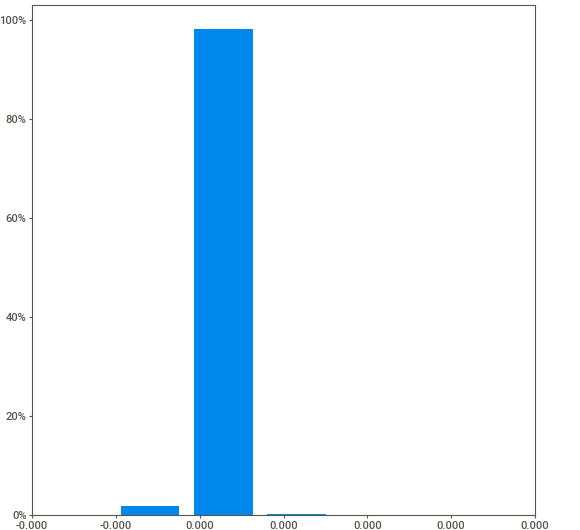
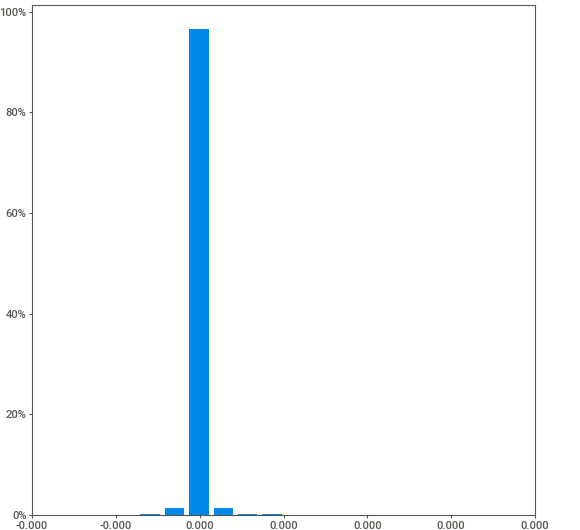
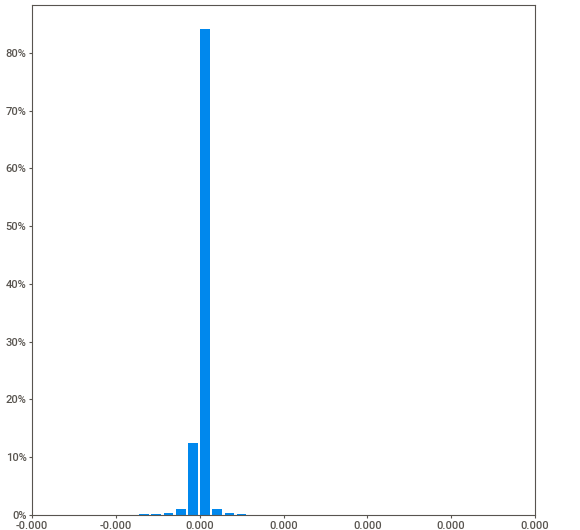
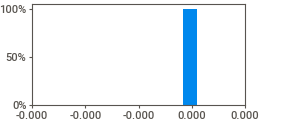
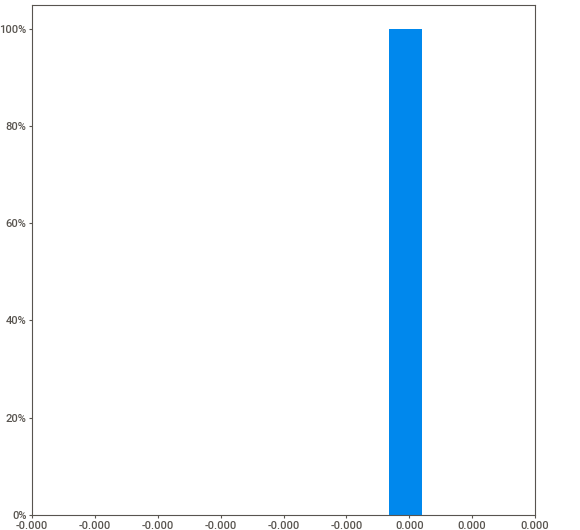
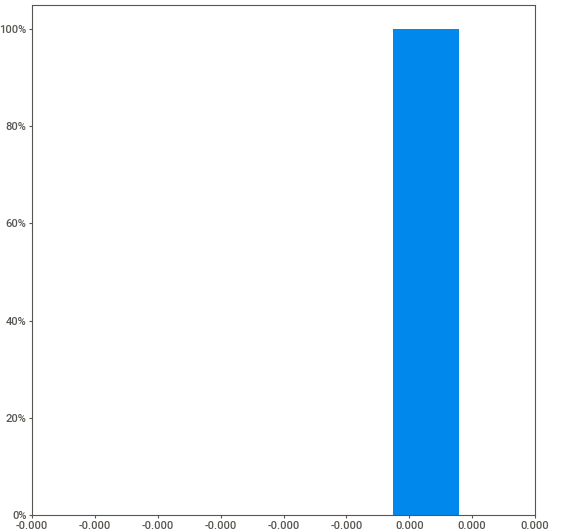
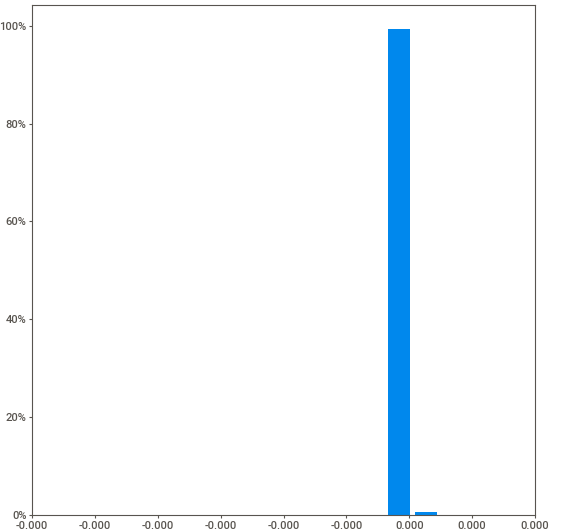
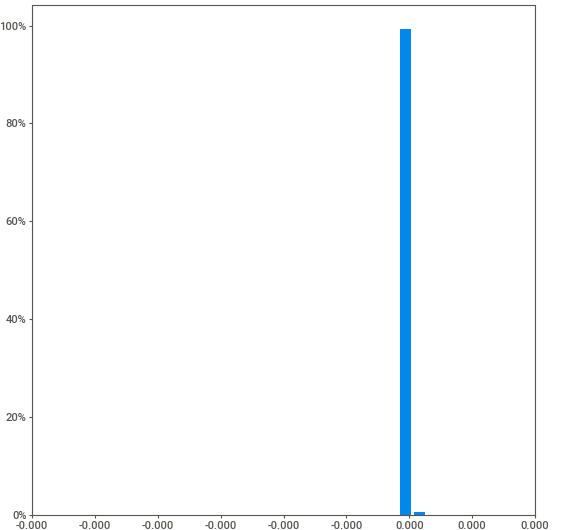
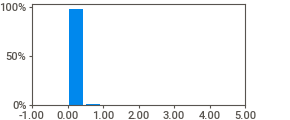
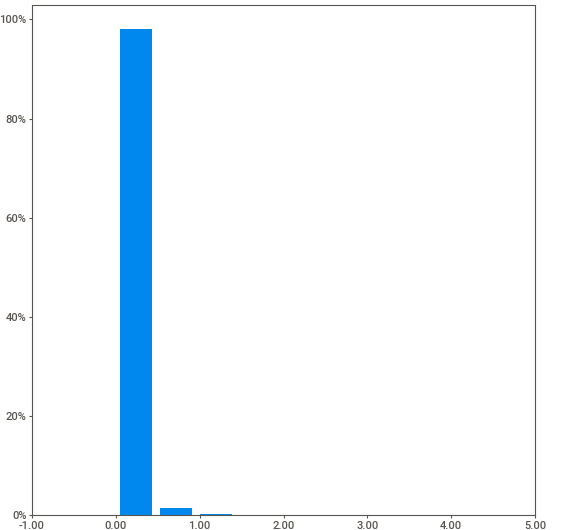
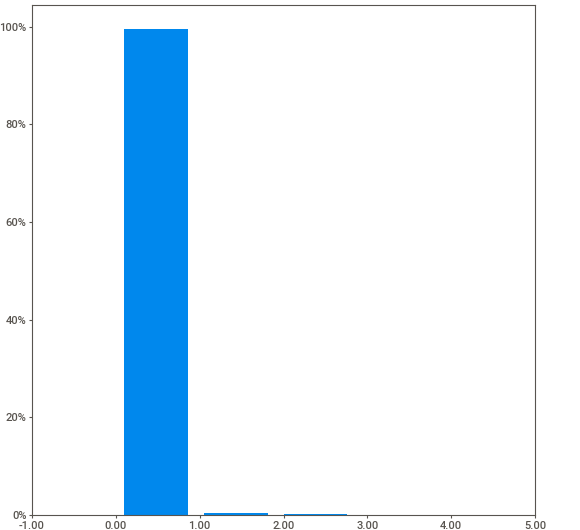
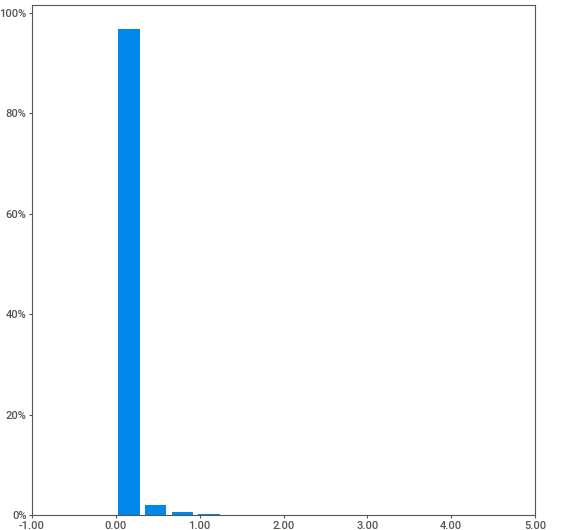
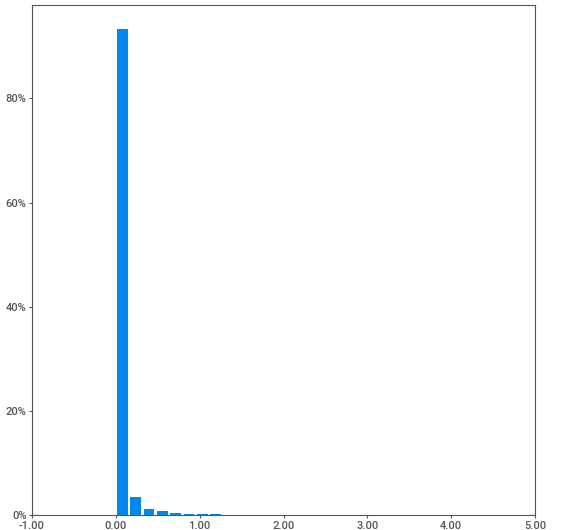
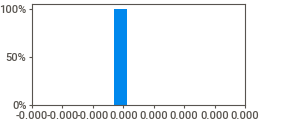
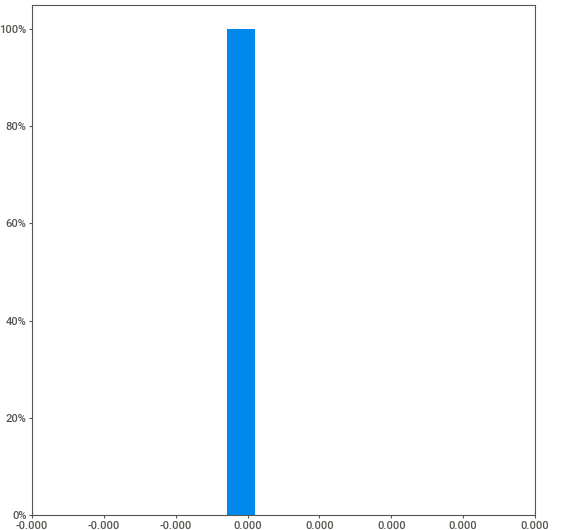
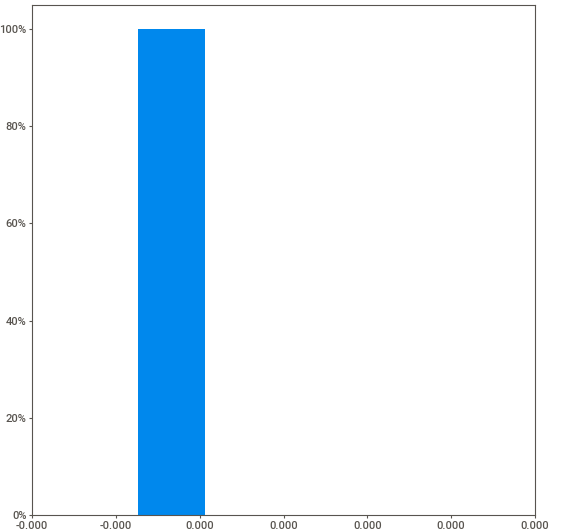
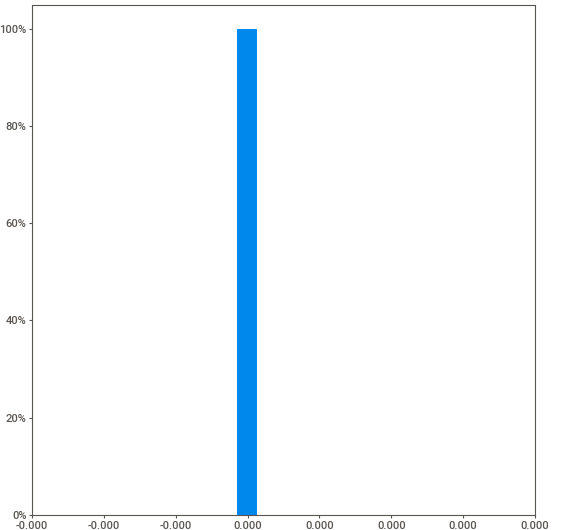
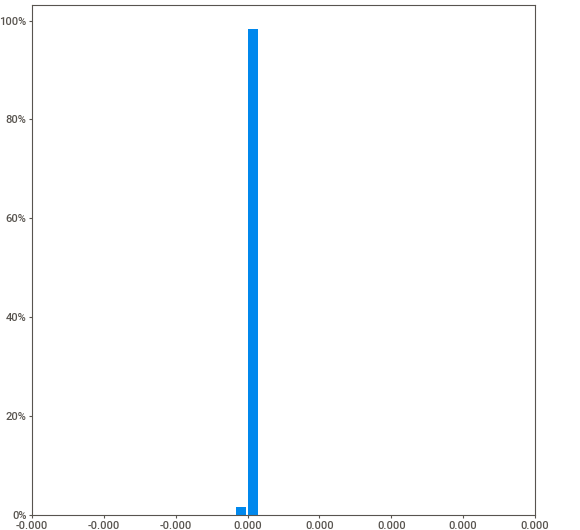
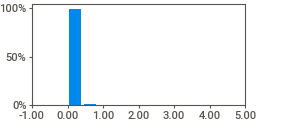
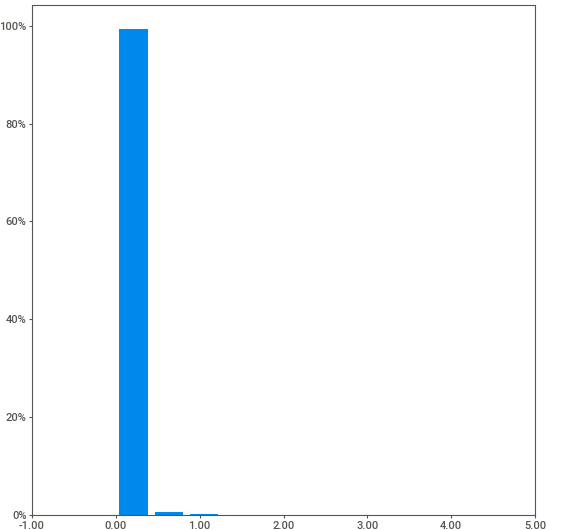
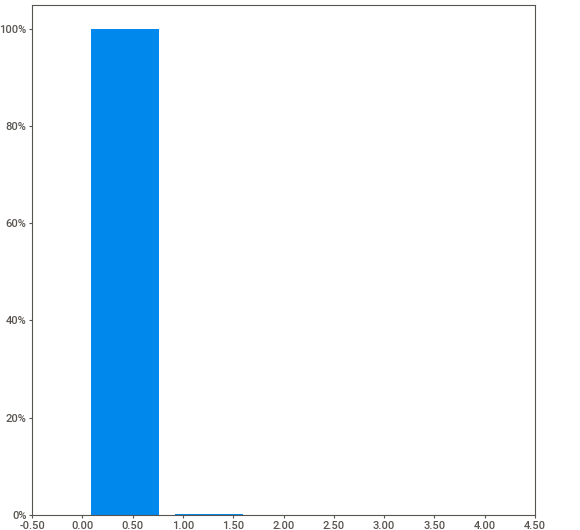
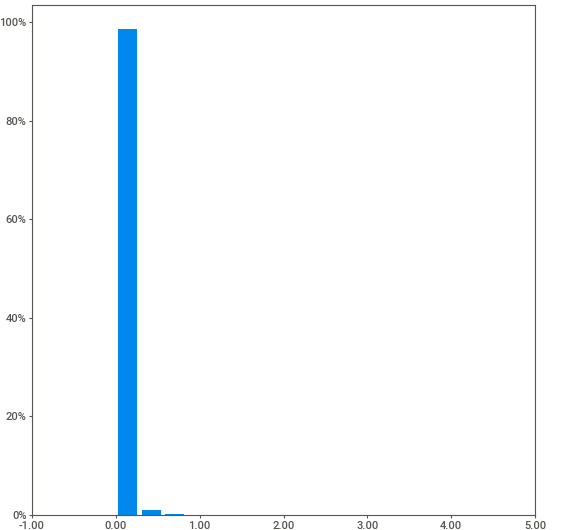
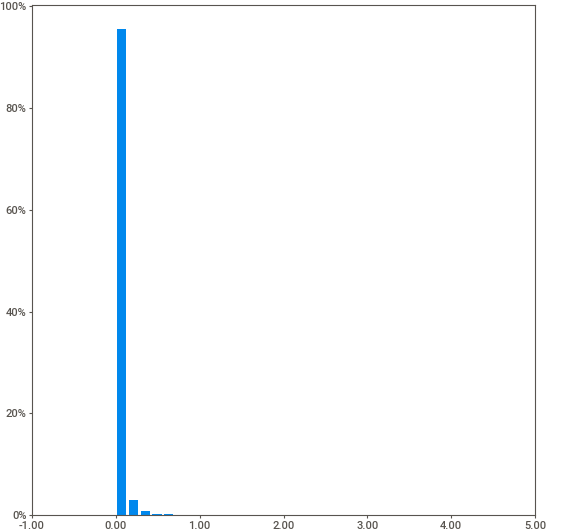
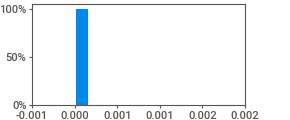
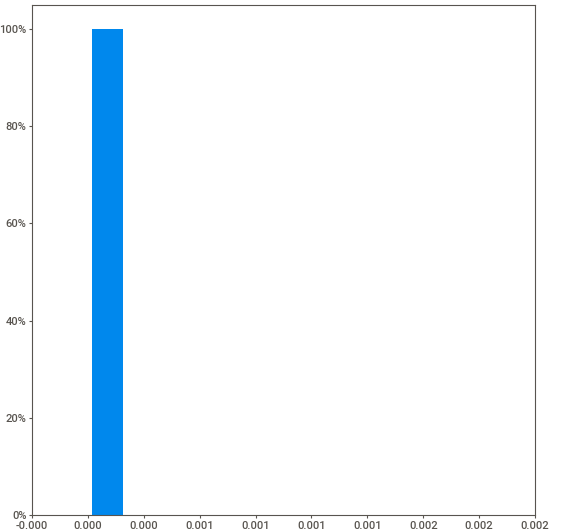
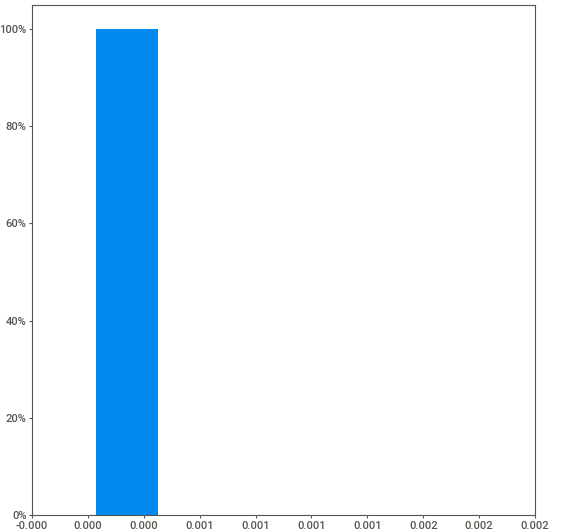
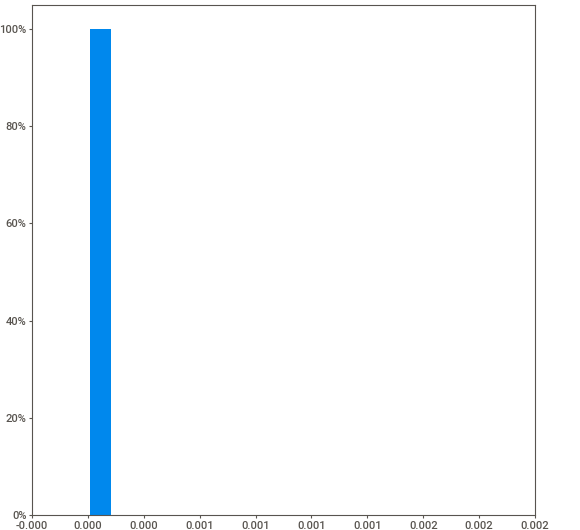
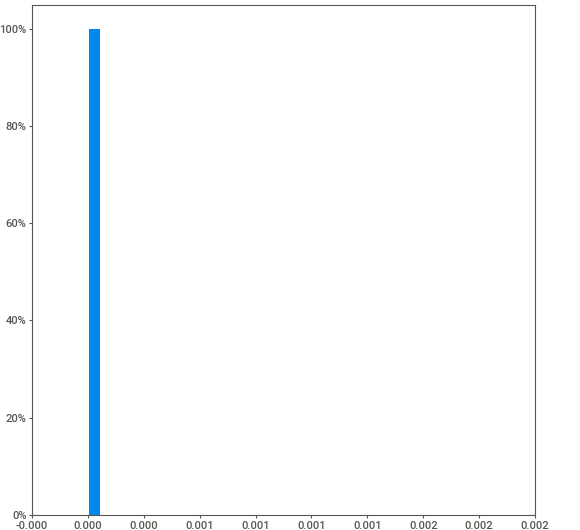
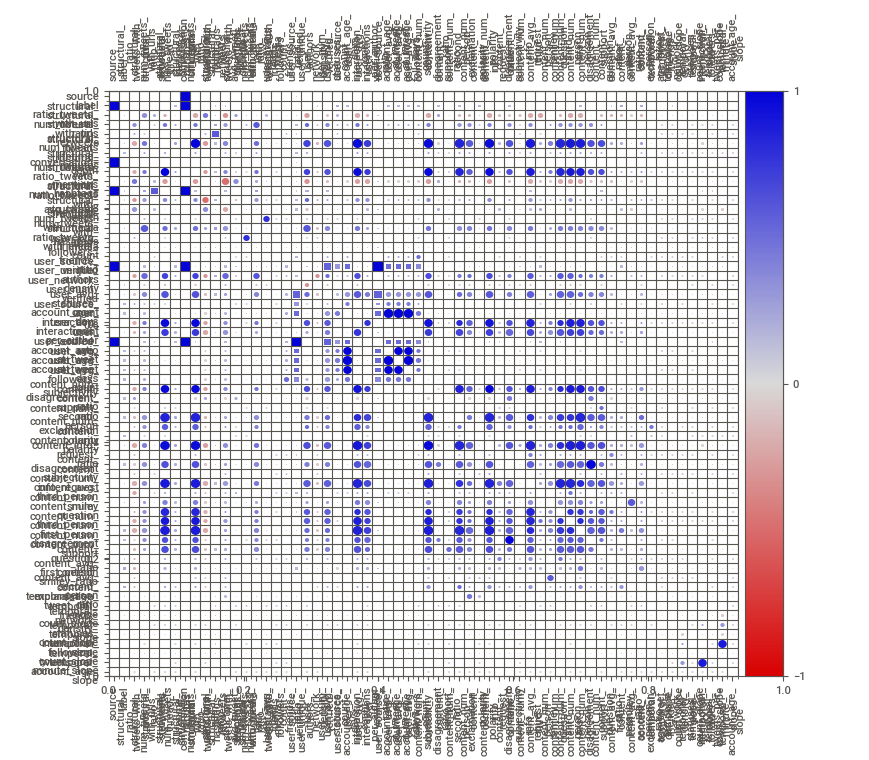
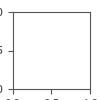

In [ ]:
import sweetviz as sv
sweet_report = sv.analyze(analysis_df)
sweet_report.show_notebook()

In [ ]:
report_path = os.path.join(gdrive_pheme_dir, 'pheme_analysis_report.html')
sweet_report.show_html(report_path)

Report /content/drive/MyDrive/fake_news/data/pheme/pheme_analysis_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [ ]:
print("\nDataset processing complete!")
print(f"Raw dataset components: {len(raw_dataset)}")
print(f"Extended dataset shape: {extended_df.shape}")
print(f"Paper features shape: {paper_features_df.shape}")
print(f"All features shape: {all_features_df.shape}")


Dataset processing complete!
Raw dataset components: 5
Extended dataset shape: (5802, 96)
Paper features shape: (5802, 47)
All features shape: (5802, 62)


# PHEME dataset: Loading Features

Loading raw features:

In [20]:
# PHEME dataset: Loading RAW dataset
gdrive_pheme_raw_backup = os.path.join(gdrive_pheme_dir, 'pheme_raw_dataset.csv')

# Check if backup exists in Google Drive
if os.path.exists(gdrive_pheme_raw_backup):
    print("Using existing PHEME raw dataset backup from Google Drive")
    dataset_path = "data/pheme/pheme_raw_dataset.csv"
    os.makedirs(os.path.dirname(dataset_path), exist_ok=True)
    !cp "{gdrive_pheme_raw_backup}" "{dataset_path}"

Using existing PHEME raw dataset backup from Google Drive


Loading extended features:

In [21]:
# PHEME dataset: Loading extended dataset
gdrive_pheme_extended_backup = os.path.join(gdrive_pheme_dir, 'pheme_extended_dataset.csv')

# Check if backup exists in Google Drive
if os.path.exists(gdrive_pheme_extended_backup):
    print("Using existing PHEME extended dataset backup from Google Drive")
    dataset_path = "data/pheme/pheme_extended_dataset.csv"
    os.makedirs(os.path.dirname(dataset_path), exist_ok=True)
    !cp "{gdrive_pheme_extended_backup}" "{dataset_path}"

Using existing PHEME extended dataset backup from Google Drive


Loading paper features and all features:

In [22]:
# PHEME dataset: Loading Features
gdrive_pheme_pf_backup = os.path.join(gdrive_pheme_dir, 'pheme_paper_features.csv')
gdrive_pheme_af_backup = os.path.join(gdrive_pheme_dir, 'pheme_all_features.csv')

# Check if backup exists in Google Drive
if os.path.exists(gdrive_pheme_pf_backup):
    print("Using existing PHEME paper features backup from Google Drive")
    dataset_path = "data/pheme/pheme_paper_features.csv"
    os.makedirs(os.path.dirname(dataset_path), exist_ok=True)
    !cp "{gdrive_pheme_pf_backup}" "{dataset_path}"

# Check if backup exists in Google Drive
if os.path.exists(gdrive_pheme_af_backup):
    print("Using existing PHEME all features backup from Google Drive")
    dataset_path = "data/pheme/pheme_all_features.csv"
    os.makedirs(os.path.dirname(dataset_path), exist_ok=True)
    !cp "{gdrive_pheme_af_backup}" "{dataset_path}"

Using existing PHEME paper features backup from Google Drive
Using existing PHEME all features backup from Google Drive


In [23]:
# Load raw dataset
print("Loading raw dataset...")
raw_df = pd.read_csv('data/pheme/pheme_raw_dataset.csv')

Loading raw dataset...


In [24]:
raw_df.head()

,event,category,thread_id,num_reactions,source_tweet_contributors,source_tweet_truncated,source_tweet_text,source_tweet_in_reply_to_status_id,source_tweet_id,source_tweet_favorite_count,...,source_tweet_place_country,source_tweet_place_place_type,source_tweet_place_bounding_box,source_tweet_place_country_code,source_tweet_place_attributes,source_tweet_place_id,source_tweet_place_name,source_tweet_metadata_iso_language_code,source_tweet_metadata_result_type,source_tweet_place_contained_within
0,charliehebdo,rumours,553529101659566080,18,NaN,False,BREAKING: Armed man takes hostage in kosher gr...,NaN,553529101659566080,14,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,charliehebdo,rumours,553587735613952001,7,NaN,False,"#CharlieHebdo killers dead, confirmed by genda...",NaN,553587735613952001,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,charliehebdo,rumours,552816932643405824,6,NaN,False,"Top French cartoonists Charb, Cabu, Wolinski, ...",NaN,552816932643405824,23,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,charliehebdo,rumours,553515399438811136,9,NaN,False,Police have surrounded the area where the #Cha...,NaN,553515399438811136,329,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,charliehebdo,rumours,552808620187217920,4,NaN,False,PHOTO: Armed gunmen face police officers near ...,NaN,552808620187217920,27,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
# Load extended dataset
print("Loading extended dataset...")
extended_df = pd.read_csv('data/pheme/pheme_extended_dataset.csv')

Loading extended dataset...


In [26]:
# Load paper features dataset
print("Loading paper features dataset...")
paper_features_df = pd.read_csv('data/pheme/pheme_paper_features.csv')

Loading paper features dataset...


In [27]:
paper_features_df.head()

,source,label,structural_ratio_tweets_with_mentions,structural_ratio_tweets_with_hashtags,structural_num_tweets_with_urls,structural_num_retweets,structural_conversation_depth,structural_thread_lifetime_minutes,structural_avg_tweet_length,structural_num_tweets,...,content_num_question,content_polarity,content_subjectivity,temporal_age_tweet_diff_slope,temporal_interaction_slope,temporal_friends_count_slope,temporal_followers_count_slope,temporal_tweets_per_minute_slope,temporal_statuses_count_slope,temporal_account_age_slope
0,pheme,1,0.947368,0.000000,5.0,1.0,1.0,75.550000,116.947368,19.0,...,4.0,0.041921,0.225723,0.001336,0.034937,-5.782649e-18,7.497505e-19,0.020620,-2.800992e-19,-3.744899e-18
1,pheme,1,0.875000,0.250000,1.0,1.0,1.0,404.516667,92.750000,8.0,...,0.0,0.156250,0.534375,0.014013,0.002677,-8.618975e-19,-2.119691e-18,0.001941,-1.021417e-18,-1.094542e-18
2,pheme,1,0.857143,0.285714,1.0,0.0,1.0,272.950000,104.714286,7.0,...,0.0,-0.215357,0.536786,0.015463,0.004790,1.334290e-18,-3.483867e-18,0.003798,6.812980e-19,1.826151e-06
3,pheme,1,0.900000,0.500000,4.0,1.0,1.0,1844.233333,103.300000,10.0,...,4.0,0.005863,0.275238,0.002474,0.000495,-2.038172e-19,-5.133670e-19,0.000454,-2.397567e-20,1.908230e-07
4,pheme,1,0.800000,0.400000,3.0,0.0,1.0,22.166667,115.800000,5.0,...,1.0,-0.030000,0.180000,0.194432,0.073144,-1.096397e-16,3.005790e-16,0.044724,9.668537e-17,-9.570538e-17


# PHEME dataset: Visualization

In [ ]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Set style for all plots
plt.style.use('classic')
sns.set_palette("husl")

In [ ]:
# Enable inline plotting
%matplotlib inline

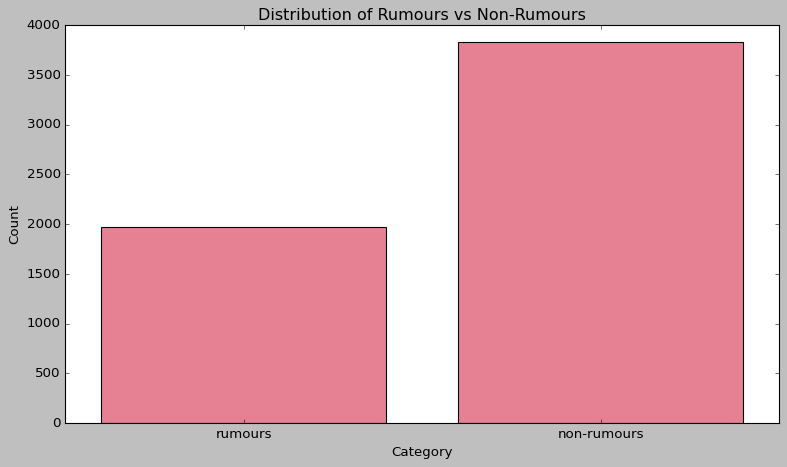

In [ ]:
# Rumours vs Non-Rumours Distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=raw_df, x='category')
plt.title('Distribution of Rumours vs Non-Rumours')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
plt.savefig('data/pheme/rumours_distribution.png')
plt.close()

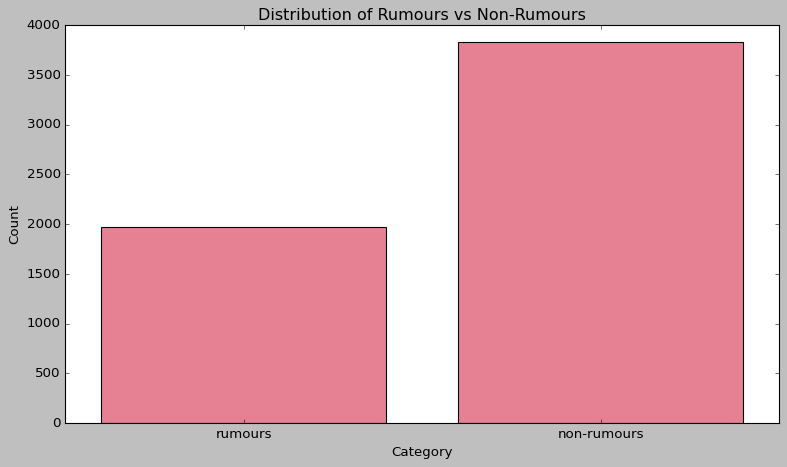

In [ ]:
# Rumours vs Non-Rumours Distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=raw_df, x='category')
plt.title('Distribution of Rumours vs Non-Rumours')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
plt.savefig('data/pheme/rumours_distribution.png')
plt.close()

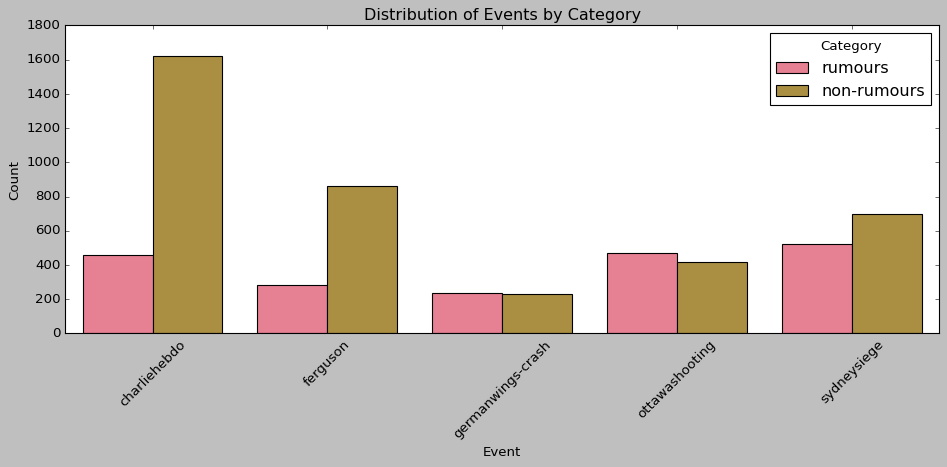

In [ ]:
# Event Distribution
plt.figure(figsize=(12, 6))
sns.countplot(data=raw_df, x='event', hue='category')
plt.title('Distribution of Events by Category')
plt.xlabel('Event')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Category')
plt.tight_layout()
plt.show()
plt.savefig('data/pheme/event_distribution.png')
plt.close()

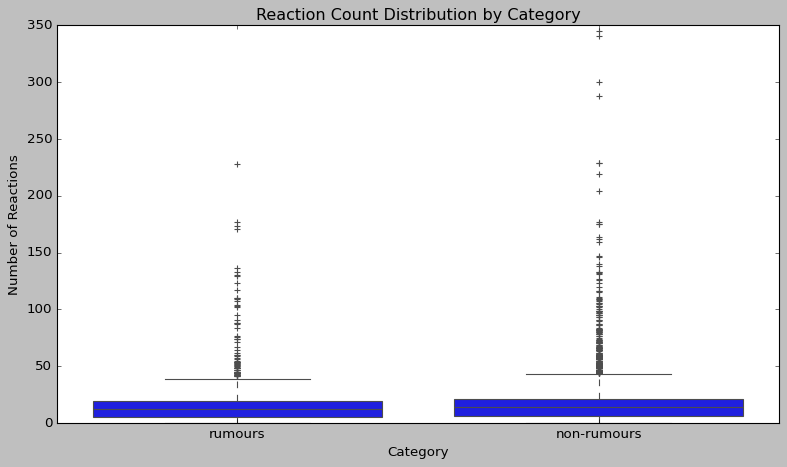

In [ ]:
# Reaction Count Distribution
plt.figure(figsize=(10, 6))
sns.boxplot(data=raw_df, x='category', y='num_reactions')
plt.title('Reaction Count Distribution by Category')
plt.xlabel('Category')
plt.ylabel('Number of Reactions')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
plt.savefig('data/pheme/reaction_distribution.png')
plt.close()

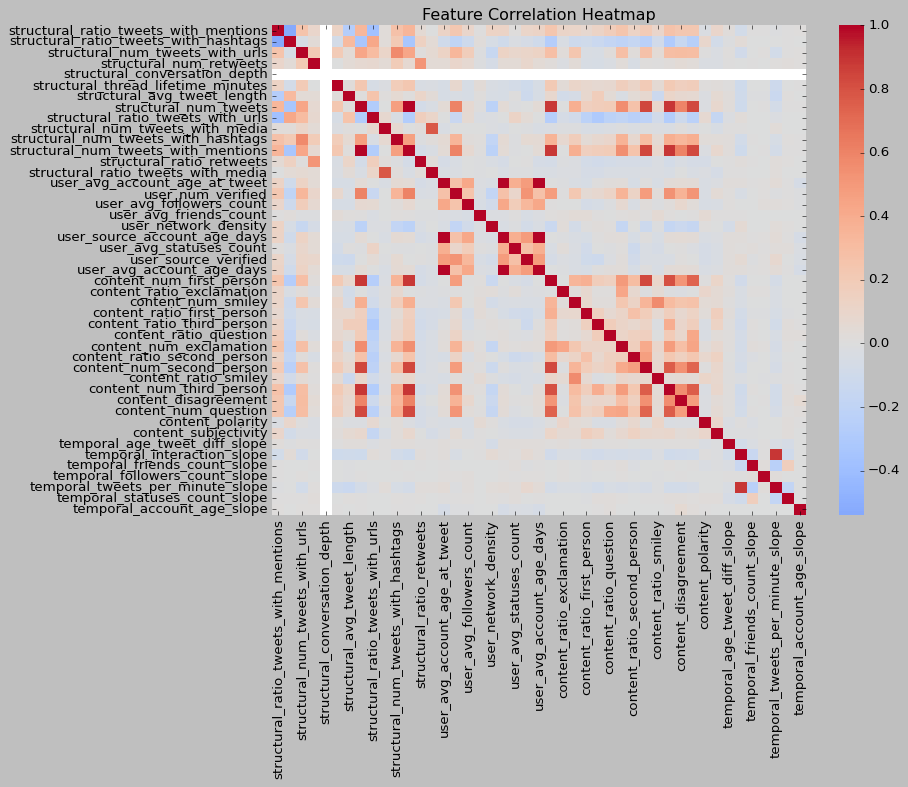

In [ ]:
# Feature Correlation Heatmap
plt.figure(figsize=(12, 10))
feature_cols = [col for col in paper_features_df.columns if col not in ['source', 'label']]
correlation = paper_features_df[feature_cols].corr()
sns.heatmap(correlation, cmap='coolwarm', center=0, annot=False)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()
plt.savefig('data/pheme/feature_correlation.png')
plt.close()

In [ ]:
from wordcloud import WordCloud
def create_pheme_wordclouds(df):
    """Create and display word clouds for rumor and non-rumor tweets in PHEME dataset"""

    # Separate rumor and non-rumor tweets
    rumor_texts = df[df['category'] == 'rumours']['source_tweet_text'].str.cat(sep=' ')
    non_rumor_texts = df[df['category'] == 'non-rumours']['source_tweet_text'].str.cat(sep=' ')

    # Create word clouds
    plt.figure(figsize=(20,10))

    # Rumor word cloud
    plt.subplot(1,2,1)
    wordcloud_rumor = WordCloud(width=800, height=400,
                              background_color='white',
                              max_words=100).generate(rumor_texts)
    plt.imshow(wordcloud_rumor, interpolation='bilinear')
    plt.axis('off')
    plt.title('Most Common Words in Rumor Tweets', fontsize=16)

    # Non-rumor word cloud
    plt.subplot(1,2,2)
    wordcloud_non_rumor = WordCloud(width=800, height=400,
                                  background_color='white',
                                  max_words=100).generate(non_rumor_texts)
    plt.imshow(wordcloud_non_rumor, interpolation='bilinear')
    plt.axis('off')
    plt.title('Most Common Words in Non-Rumor Tweets', fontsize=16)

    plt.tight_layout()
    plt.show()

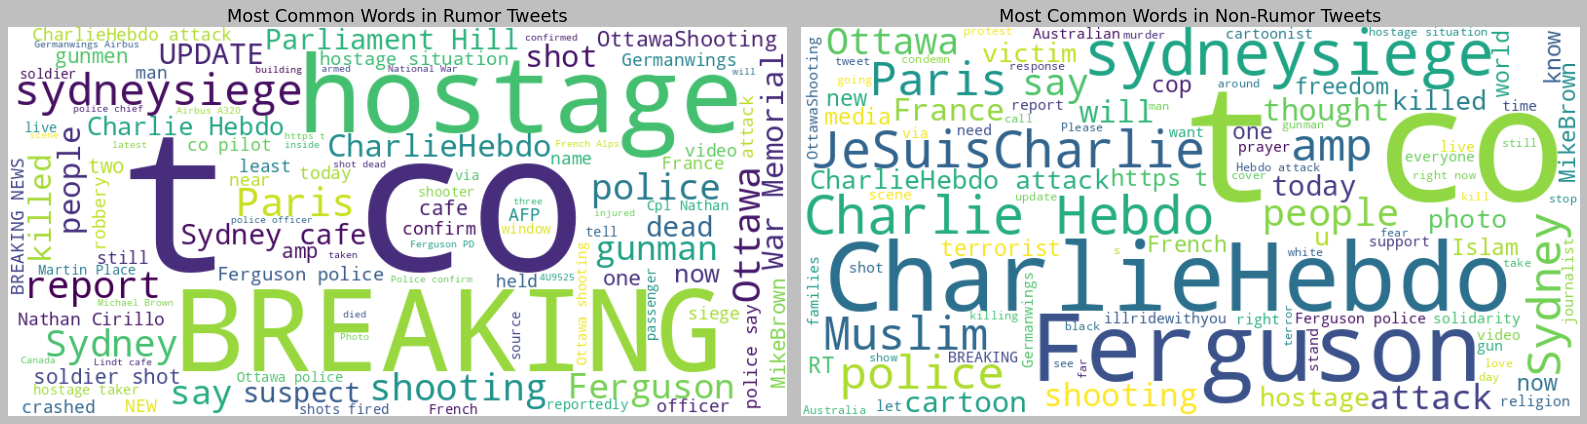

In [ ]:
create_pheme_wordclouds(extended_df)

# CREDBANK dataset: Loading

In [ ]:
import os

Setting Up Kaggle (Only if needed):

In [ ]:
# Setting Up Kaggle (only if needed)
def setup_kaggle_if_needed():
    """Set up Kaggle only if we need to download the dataset"""
    gdrive_backup = os.path.join(gdrive_credbank_dir, 'credbank-dataset.zip')

    if os.path.exists(gdrive_backup):
        return False

    from google.colab import files
    files.upload()

    !pip install -q kaggle
    !mkdir -p ~/.kaggle
    !cp kaggle.json ~/.kaggle/
    !chmod 600 /root/.kaggle/kaggle.json
    return True

Loading:

In [ ]:
# CREDBANK dataset: Loading
def backup_and_download_credbank():
    """Download CREDBANK dataset if not already in Google Drive"""
    gdrive_backup = os.path.join(gdrive_credbank_dir, 'credbank-dataset.zip')

    # Check if backup exists in Google Drive
    if os.path.exists(gdrive_backup):
        print("Using existing CREDBANK backup from Google Drive")
        dataset_path = "data/credbank/credbank-dataset.zip"
        os.makedirs(os.path.dirname(dataset_path), exist_ok=True)
        !cp "{gdrive_backup}" "{dataset_path}"
        return True

    # If no backup exists, set up Kaggle and download
    if setup_kaggle_if_needed():
        # Download using Kaggle API
        !kaggle datasets download fabliha6459345398/credbank-dataset -p data/credbank

        # Create backup in Google Drive
        dataset_path = "data/credbank/credbank-dataset.zip"
        !cp "{dataset_path}" "{gdrive_backup}"
        print("Created backup in Google Drive")

    return True

Downloading from the source or using the backup:

In [ ]:
# Download and process
if backup_and_download_credbank():
    # Proceed with CREDBANK dataset processing
    pass

Using existing CREDBANK backup from Google Drive


Unzipping:

In [ ]:
# Unzip CREDBANK dataset
!unzip data/credbank/credbank-dataset.zip -d data/credbank

Archive:  data/credbank/credbank-dataset.zip
  inflating: data/credbank/CREDBANK/cred_event_SearchTweets.data  
  inflating: data/credbank/CREDBANK/cred_event_TurkRatings.data  
  inflating: data/credbank/CREDBANK/eventNonEvent_annotations.data  
  inflating: data/credbank/CREDBANK/stream_tweets_byTimestamp.data  


Deleting archive files:

In [ ]:
# Delete CREDBANK archive
archive_path = 'data/credbank/credbank-dataset.zip'
if os.path.exists(archive_path):
    os.remove(archive_path)
    print(f"Deleted archive file: {archive_path}")

Deleted archive file: data/credbank/credbank-dataset.zip


# CREDBANK dataset: Requirements

In [ ]:
import json
import os
import pandas as pd
import sweetviz as sv
import numpy as np
from typing import Dict, List, Tuple, Any, Union
from collections import defaultdict
import warnings
import multiprocessing as mp
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor
from tqdm import tqdm
from utils.features import (
    CredbankStructuralFeatureExtractor,
    CredbankUserFeatureExtractor,
    CredbankContentFeatureExtractor,
    CredbankTemporalFeatureExtractor
)
from utils.dataset_alignment import save_feature_sets

In [ ]:
# CREDBANK dataset processor for credibility assessment using social media features
def process_list_column(column_data):
    """Process a string representation of a list into an actual list."""
    try:
        return eval(column_data)
    except:
        return []

In [ ]:
# Loads raw CREDBANK dataset from multiple data files containing credibility ratings and tweets
def load_credbank_dataset_raw(base_path: str = 'data/credbank/CREDBANK', output_dir: str = None, save_csv: bool = False) -> pd.DataFrame:
    """Load the raw CREDBANK dataset files and combine them into a single DataFrame.

    Args:
        base_path: Path to the CREDBANK dataset directory
        output_dir: Directory to save output files (defaults to base_path if None)
        save_csv: Whether to save intermediate CSV files

    Returns:
        DataFrame containing the combined raw dataset
    """
    # Use base_path as output_dir if not specified
    output_dir = output_dir or base_path

    # Define file paths
    credibility_ratings_path = os.path.join(base_path, 'cred_event_TurkRatings.data')
    event_annotations_path = os.path.join(base_path, 'eventNonEvent_annotations.data')
    search_tweets_path = os.path.join(base_path, 'cred_event_SearchTweets.data')

    # Verify paths
    for path in [credibility_ratings_path, event_annotations_path, search_tweets_path]:
        if not os.path.exists(path):
            raise FileNotFoundError(f"File not found: {path}")

    print("Loading CREDBANK datasets...")

    # Load credibility ratings
    cred_ratings_df = pd.read_csv(
        credibility_ratings_path,
        sep='\t',
        names=['topic_key', 'topic_terms', 'Cred_Ratings', 'Reasons'],
        skiprows=1  # Skip header row
    )

    # Load event annotations
    event_annotations_df = pd.read_csv(
        event_annotations_path,
        sep='\t',
        names=['timespan_key', 'topic_terms', 'isEvent'],
        skiprows=1  # Skip header row
    )

    # Process tweets line by line
    print("Processing search tweets...")
    tweet_metrics = []

    with tqdm(total=sum(1 for _ in open(search_tweets_path)), desc="Processing tweets") as pbar:
        with open(search_tweets_path, 'r') as f:
            for line in f:
                try:
                    parts = line.strip().split('\t')
                    if len(parts) >= 4:  # Ensure we have all required columns
                        topic_key = parts[0]
                        tweet_list_str = parts[3]  # The tweet list is in the fourth column
                        tweet_list = process_list_column(tweet_list_str)
                        unique_authors = set(tuple_item[1].split('AUTHOR=')[1] for tuple_item in tweet_list)

                        # Extract additional metrics
                        tweet_metrics.append({
                            'topic_key': topic_key,
                            'tweet_count': int(len(tweet_list)),
                            'unique_authors': int(len(unique_authors))
                        })
                except Exception as e:
                    print(f"\nError processing line: {str(e)}")
                finally:
                    pbar.update(1)

    search_tweets_df = pd.DataFrame(tweet_metrics)

    # Merge all DataFrames
    merged_df = pd.merge(
        cred_ratings_df,
        event_annotations_df,
        left_on='topic_key',
        right_on='timespan_key',
        how='left',
        suffixes=('', '_event')  # Keep original column names, add _event suffix for duplicates
    )

    # Drop duplicate topic_terms column
    if 'topic_terms_event' in merged_df.columns:
        merged_df.drop('topic_terms_event', axis=1, inplace=True)

    # Merge with tweets data
    merged_df = pd.merge(
        merged_df,
        search_tweets_df,
        on='topic_key',
        how='left'
    )

    # Save if requested
    if save_csv:
        os.makedirs(output_dir, exist_ok=True)
        output_path = os.path.join(output_dir, 'credbank_raw_dataset.csv')
        merged_df.to_csv(output_path, index=False, header=True)
        print(f"Saved raw dataset to: {output_path}")

    return merged_df

In [ ]:
# Processes raw CREDBANK data into a structured DataFrame with basic credibility features
def load_credbank_dataset_extended(raw_dataset: Union[Dict, str, None] = None, base_path: str = 'data/credbank/CREDBANK', output_dir: str = None, save_csv: bool = False) -> pd.DataFrame:
    """Load and process the CREDBANK dataset with basic features but without the feature extractors.
    Can either take a raw dataset dict or load from a CSV file.

    Args:
        raw_dataset: Either a raw dataset dict from load_credbank_dataset_raw or a path to a CSV file
        base_path: Path to the CREDBANK dataset directory (used if raw_dataset is None)
        output_dir: Directory to save output files (defaults to base_path if None)
        save_csv: Whether to save intermediate CSV files

    Returns:
        DataFrame containing the processed dataset with basic features
    """
    # Use base_path as output_dir if not specified
    output_dir = output_dir or base_path

    if isinstance(raw_dataset, str) and os.path.exists(raw_dataset):
        # Load from specified CSV path
        print(f"Loading extended dataset from CSV: {raw_dataset}")
        return pd.read_csv(raw_dataset)

    if raw_dataset is None:
        raw_dataset = load_credbank_dataset_raw(base_path)

    # Process list columns in ratings DataFrame
    list_columns = ['topic_terms', 'Cred_Ratings', 'Reasons']
    for col in list_columns:
        raw_dataset[col] = raw_dataset[col].apply(process_list_column)

    # Create a more robust mapping function that handles different formats
    def normalize_topic_terms(terms):
        """Normalize topic terms for consistent matching"""
        if isinstance(terms, str):
            # Handle string format from event annotations
            terms = terms.lower().replace('[', '').replace(']', '').replace("'", '').replace('"', '')
            return sorted(term.strip() for term in terms.split(','))
        elif isinstance(terms, list):
            # Handle list format from credibility ratings
            return sorted(str(term).lower().strip() for term in terms)
        return []

    # Create mapping with normalized terms
    topic_event_map = defaultdict(list)
    for _, row in raw_dataset.iterrows():
        normalized_terms = tuple(normalize_topic_terms(row['topic_terms']))
        if normalized_terms and pd.notna(row.get('isEvent')):  # Only add if we have valid terms and isEvent
            topic_event_map[normalized_terms].append({
                'time_key': row['timespan_key'],
                'isEvent': int(row['isEvent']) if pd.notna(row['isEvent']) else 0  # Default to 0 if NaN
            })

    # Modified matching function
    def get_event_info(topic_terms):
        normalized_terms = tuple(normalize_topic_terms(topic_terms))
        # Try exact match first
        if normalized_terms in topic_event_map:
            return topic_event_map[normalized_terms]

        # If no exact match, try partial matching
        normalized_terms_set = set(normalized_terms)
        for stored_terms, values in topic_event_map.items():
            stored_terms_set = set(stored_terms)
            if len(normalized_terms_set & stored_terms_set) >= 2:  # At least 2 terms match
                return values
        return []

    # Apply the matching to get event info
    raw_dataset['event_info'] = raw_dataset['topic_terms'].apply(get_event_info)

    # Extract time_keys and isEvent from event_info
    raw_dataset['time_keys'] = raw_dataset['event_info'].apply(
        lambda x: [item['time_key'] for item in x] if x else []
    )
    raw_dataset['isEvent'] = raw_dataset['event_info'].apply(
        lambda x: [item['isEvent'] for item in x] if x else [0]  # Default to [0] for no events
    )

    # Clean up temporary column
    raw_dataset.drop('event_info', axis=1, inplace=True)

    # Calculate average credibility rating
    raw_dataset['avg_credibility'] = raw_dataset['Cred_Ratings'].apply(
        lambda x: sum(map(float, x)) / len(x) if x else 0
    )

    # Add additional fields
    raw_dataset['num_credibility_ratings'] = raw_dataset['Cred_Ratings'].apply(len)
    raw_dataset['num_reasons'] = raw_dataset['Reasons'].apply(len)

    # Add credibility distribution columns
    for rating in ['certainly_inaccurate', 'probably_inaccurate', 'uncertain', 'probably_accurate', 'certainly_accurate']:
        raw_dataset[f'num_{rating}'] = raw_dataset['Cred_Ratings'].apply(
            lambda x: [int(r) for r in x].count({'certainly_inaccurate': -2, 'probably_inaccurate': -1,
                                                'uncertain': 0, 'probably_accurate': 1,
                                                'certainly_accurate': 2}[rating])
        )

    # Calculate agreement metrics
    def calculate_agreement(ratings):
        ratings = [int(r) for r in ratings]
        total = len(ratings)
        if total == 0:
            return 0
        mode_count = max(ratings.count(r) for r in set(ratings))
        return mode_count / total

    raw_dataset['rater_agreement'] = raw_dataset['Cred_Ratings'].apply(calculate_agreement)

    # Save if requested
    if save_csv:
        os.makedirs(output_dir, exist_ok=True)
        output_path = os.path.join(output_dir, 'credbank_extended_dataset.csv')
        raw_dataset.to_csv(output_path, index=False, header=True)
        print(f"Saved extended dataset to: {output_path}")

    return raw_dataset

In [ ]:
# Extracts advanced features from CREDBANK data using specialized feature extractors
def load_credbank_features_dataset(extended_dataset: Union[pd.DataFrame, str, None] = None, base_path: str = 'data/credbank', output_dir: str = None, save_csv: bool = False, include_additional_features: bool = False) -> pd.DataFrame:
    """Load or create the CREDBANK features dataset with all feature extractors applied.
    Can either take an extended dataset DataFrame or load from a CSV file.

    Args:
        extended_dataset: Either a DataFrame from load_credbank_dataset_extended or a path to a CSV file
        base_path: Path to the CREDBANK dataset directory (used if extended_dataset is None)
        output_dir: Directory to save output files (defaults to base_path if None)
        save_csv: Whether to save intermediate CSV files
        include_additional_features: Whether to include additional features

    Returns:
        DataFrame containing only the extracted features, source, and label
    """
    # Use base_path as output_dir if not specified
    output_dir = output_dir or base_path

    if isinstance(extended_dataset, str) and os.path.exists(extended_dataset):
        # Load from specified CSV path
        print(f"Loading features dataset from CSV: {extended_dataset}")
        return pd.read_csv(extended_dataset)

    if extended_dataset is None:
        extended_dataset = load_credbank_dataset_extended(base_path=base_path, output_dir=output_dir, save_csv=save_csv)

    # Add binary label (1 for low credibility/potentially fake, 0 for high credibility/real)
    extended_dataset['label'] = (extended_dataset['avg_credibility'] < 0).astype(int)

    # Extract all features
    df_with_features = extract_all_features(extended_dataset, include_additional_features)

    # Get feature columns
    feature_columns = [col for col in df_with_features.columns if any(
        col.startswith(prefix) for prefix in
        ['structural_', 'user_', 'content_', 'temporal_']
    )]

    # Create features DataFrame
    features_df = df_with_features[feature_columns].copy()
    features_df.insert(0, 'source', 'credbank')
    features_df['label'] = df_with_features['label']

    # Save if requested
    if save_csv:
        os.makedirs(output_dir, exist_ok=True)
        save_feature_sets(features_df, output_dir, 'credbank')

    return features_df

In [ ]:
# Applies all CREDBANK-specific feature extractors to generate the complete feature set
def extract_all_features(df: pd.DataFrame, include_additional_features: bool = False) -> pd.DataFrame:
    """Extract all CREDBANK-specific features from the dataset.

    Args:
        df: Input DataFrame
        include_additional_features: Whether to include additional features not in the paper

    Returns:
        DataFrame with all extracted features
    """
    # Make a copy of the input DataFrame to avoid modifying the original
    result_df = df.copy()

    # Initialize feature extractors
    extractors = [
        CredbankStructuralFeatureExtractor(result_df),
        CredbankUserFeatureExtractor(result_df, include_additional_features),
        CredbankContentFeatureExtractor(result_df, include_additional_features),
        CredbankTemporalFeatureExtractor(result_df, include_additional_features)
    ]

    # Apply each extractor and update the DataFrame
    for extractor in extractors:
        # Get features from the current extractor
        updated_df = extractor.extract_features()

        # Add any new columns from the updated DataFrame
        new_columns = set(updated_df.columns) - set(result_df.columns)
        for col in new_columns:
            result_df[col] = updated_df[col]

    return result_df

In [ ]:
# Prepares DataFrame for Sweetviz analysis by converting complex data types to simple ones
def prepare_df_for_analysis(df: pd.DataFrame) -> pd.DataFrame:
    """Prepare DataFrame for Sweetviz analysis by handling complex data types"""
    analysis_df = df.copy()
    for column in analysis_df.columns:
        # Convert list columns to their lengths
        if analysis_df[column].apply(lambda x: isinstance(x, list)).any():
            analysis_df[column] = analysis_df[column].apply(lambda x: len(x) if isinstance(x, list) else x)
        # Convert unhashable types to strings
        elif analysis_df[column].apply(lambda x: isinstance(x, (dict, set))).any():
            analysis_df[column] = analysis_df[column].apply(str)
    return analysis_df

# CREDBANK dataset: Reading

In [ ]:
# Save and analyze results
output_dir = 'data/credbank'
os.makedirs(output_dir, exist_ok=True)

# Define the output directory in Google Drive
gdrive_credbank_dir = '/content/drive/MyDrive/fake_news/data/credbank'

Reading:

In [ ]:
# Load raw dataset
print("Loading raw dataset...")
raw_df = load_credbank_dataset_raw(output_dir=output_dir, save_csv=True)

Loading raw dataset...
Loading CREDBANK datasets...
Processing search tweets...


Processing tweets:  64%|██████▍   | 882/1378 [10:04<05:39,  1.46it/s]

In [ ]:
# Load extended dataset
print("\nCreating extended dataset...")
extended_df = load_credbank_dataset_extended(raw_df, output_dir=output_dir, save_csv=True)


Creating extended dataset...


NameError: name 'load_credbank_dataset_extended' is not defined

In [ ]:
# Extract all features once
print("\nExtracting features...")
all_features_df = load_credbank_features_dataset(extended_df, output_dir=output_dir, save_csv=False, include_additional_features=True)

In [ ]:
# Split into paper and all features using dataset_alignment.save_feature_sets
paper_features_df, all_features_df = save_feature_sets(all_features_df, output_dir, 'credbank')

NameError: name 'save_feature_sets' is not defined

Saving backups:

In [ ]:
# Save backups to Google Drive
print("\nSaving backups to Google Drive...")

raw_df.to_csv(f"{gdrive_credbank_dir}/credbank_raw_dataset.csv", index=False)
extended_df.to_csv(f"{gdrive_credbank_dir}/credbank_extended_dataset.csv", index=False)
paper_features_df.to_csv(f"{gdrive_credbank_dir}/credbank_paper_features.csv", index=False)
all_features_df.to_csv(f"{gdrive_credbank_dir}/credbank_all_features.csv", index=False)
print(f"Features saved to: {gdrive_credbank_dir}")

Preparing dataset for Sweetviz analysis:

In [ ]:
# Prepare dataset for Sweetviz analysis
analysis_df = prepare_df_for_analysis(all_features_df)

In [ ]:
import sweetviz as sv
sweet_report = sv.analyze(analysis_df)
sweet_report.show_notebook()

In [ ]:
report_path = os.path.join(gdrive_credbank_dir, 'credbank_analysis_report.html')
sweet_report.show_html(report_path)

In [ ]:
print("\nDataset processing complete!")
print(f"Raw dataset components: {len(raw_dataset)}")
print(f"Extended dataset shape: {extended_df.shape}")
print(f"Paper features shape: {paper_features_df.shape}")
print(f"All features shape: {all_features_df.shape}")

# CREDBANK dataset: Loading Features

Loading raw features:

In [28]:
# CREDBANK dataset: Loading RAW dataset
gdrive_credbank_raw_backup = os.path.join(gdrive_credbank_dir, 'credbank_raw_dataset.csv')

# Check if backup exists in Google Drive
if os.path.exists(gdrive_credbank_raw_backup):
    print("Using existing CREDBANK raw dataset backup from Google Drive")
    dataset_path = "data/credbank/credbank_raw_dataset.csv"
    os.makedirs(os.path.dirname(dataset_path), exist_ok=True)
    !cp "{gdrive_credbank_raw_backup}" "{dataset_path}"

Using existing CREDBANK raw dataset backup from Google Drive


Loading extended features:

In [29]:
# CREDBANK dataset: Loading extended dataset
gdrive_credbank_extended_backup = os.path.join(gdrive_credbank_dir, 'credbank_extended_dataset.csv')

# Check if backup exists in Google Drive
if os.path.exists(gdrive_credbank_extended_backup):
    print("Using existing CREDBANK extended dataset backup from Google Drive")
    dataset_path = "data/credbank/credbank_extended_dataset.csv"
    os.makedirs(os.path.dirname(dataset_path), exist_ok=True)
    !cp "{gdrive_credbank_extended_backup}" "{dataset_path}"

Using existing CREDBANK extended dataset backup from Google Drive


Loading paper features and all features:

In [30]:
# CREDBANK dataset: Loading Features
gdrive_credbank_pf_backup = os.path.join(gdrive_credbank_dir, 'credbank_paper_features.csv')
gdrive_credbank_af_backup = os.path.join(gdrive_credbank_dir, 'credbank_all_features.csv')

# Check if backup exists in Google Drive
if os.path.exists(gdrive_credbank_pf_backup):
    print("Using existing CREDBANK paper features backup from Google Drive")
    dataset_path = "data/credbank/credbank_paper_features.csv"
    os.makedirs(os.path.dirname(dataset_path), exist_ok=True)
    !cp "{gdrive_credbank_pf_backup}" "{dataset_path}"

# Check if backup exists in Google Drive
if os.path.exists(gdrive_credbank_af_backup):
    print("Using existing CREDBANK all features backup from Google Drive")
    dataset_path = "data/credbank/credbank_all_features.csv"
    os.makedirs(os.path.dirname(dataset_path), exist_ok=True)
    !cp "{gdrive_credbank_af_backup}" "{dataset_path}"

Using existing CREDBANK paper features backup from Google Drive
Using existing CREDBANK all features backup from Google Drive


In [31]:
# Load raw dataset
print("Loading raw dataset...")
raw_df = pd.read_csv('data/credbank/credbank_raw_dataset.csv')

Loading raw dataset...


In [32]:
raw_df.head()

,topic_key,topic_terms,Cred_Ratings,Reasons,timespan_key,isEvent,tweet_count,unique_authors
0,everything_royals_rain-20141015_161647-2014101...,"[u'everything', u'royals', u'rain']","['2', '1', '0', '2', '1', '1', '2', '2', '2', ...","['Game suspended due to rain', 'It is true tha...",NaN,NaN,NaN,NaN
1,host_patrick_neil-20141015_161647-20141015_172214,"[u'host', u'patrick', u'neil']","['2', '2', '2', '2', '2', '2', '2', '2', '2', ...",['Neil Patrick Harris will host the 2015 Oscar...,NaN,NaN,34694.0,28672.0
2,royals_game_series-20141015_203526-20141015_21...,"[u'royals', u'game', u'series']","['2', '1', '2', '2', '2', '0', '2', '2', '1', ...",['The Royals did win last night and are indeed...,NaN,NaN,22111.0,18845.0
3,giants_game_win-20141015_230140-20141016_000502,"[u'giants', u'game', u'win']","['2', '2', '2', '2', '2', '2', '2', '2', '0', ...","['They did win the game.', 'Major news sources...",NaN,NaN,9990.0,7890.0
4,october_ebola_house-20141015_230140-20141016_0...,"[u'october', u'ebola', u'house']","['1', '2', '2', '1', '2', '1', '1', '2', '2', ...","['Accurate news story, some opinion.', 'USA To...",NaN,NaN,147.0,127.0


In [33]:
# Load extended dataset
print("Loading extended dataset...")
extended_df = pd.read_csv('data/credbank/credbank_extended_dataset.csv')

Loading extended dataset...


In [34]:
# Load paper features dataset
print("Loading paper features dataset...")
paper_features_df = pd.read_csv('data/credbank/credbank_paper_features.csv')

Loading paper features dataset...


In [35]:
paper_features_df.head()

,source,label,structural_avg_tweet_length,structural_thread_lifetime_minutes,structural_num_tweets,structural_conversation_depth,structural_num_retweets,structural_ratio_tweets_with_urls,structural_num_tweets_with_hashtags,structural_num_tweets_with_media,...,content_ratio_question,content_ratio_exclamation,content_num_smiley,temporal_tweets_per_minute_slope,temporal_friends_count_slope,temporal_statuses_count_slope,temporal_followers_count_slope,temporal_age_tweet_diff_slope,temporal_interaction_slope,temporal_account_age_slope
0,credbank,0,57.033333,0.0,30.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,credbank,0,59.366667,0.0,30.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,credbank,0,54.066667,0.0,30.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.033333,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,credbank,0,56.366667,0.0,30.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,credbank,0,63.766667,0.0,30.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# CREDBANK dataset: Visualization

In [ ]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Set style for all plots
plt.style.use('classic')
sns.set_palette("husl")

In [ ]:
# Enable inline plotting
%matplotlib inline

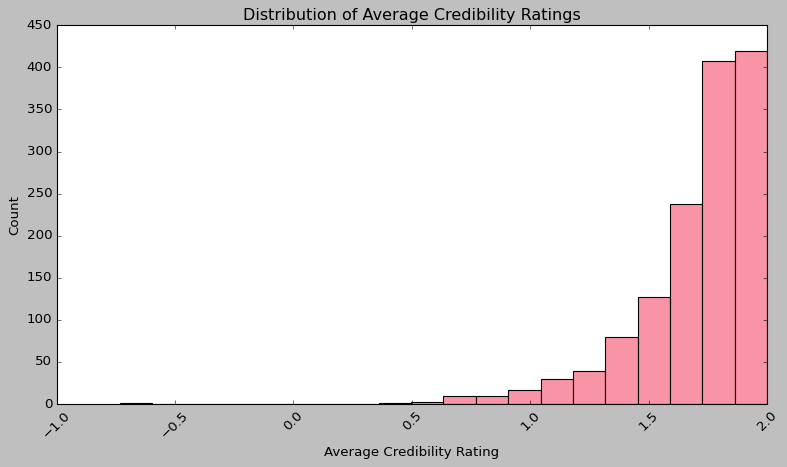

In [ ]:
# Credibility Rating Distribution
plt.figure(figsize=(10, 6))

# Convert Cred_Ratings to numeric values and calculate average
credibility_scores = raw_df['Cred_Ratings'].apply(lambda x: sum(map(float, eval(x))) / len(eval(x)) if isinstance(x, str) else 0)

sns.histplot(data=credibility_scores, bins=20)
plt.title('Distribution of Average Credibility Ratings')
plt.xlabel('Average Credibility Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.savefig('data/credbank/credibility_distribution.png')
plt.close()

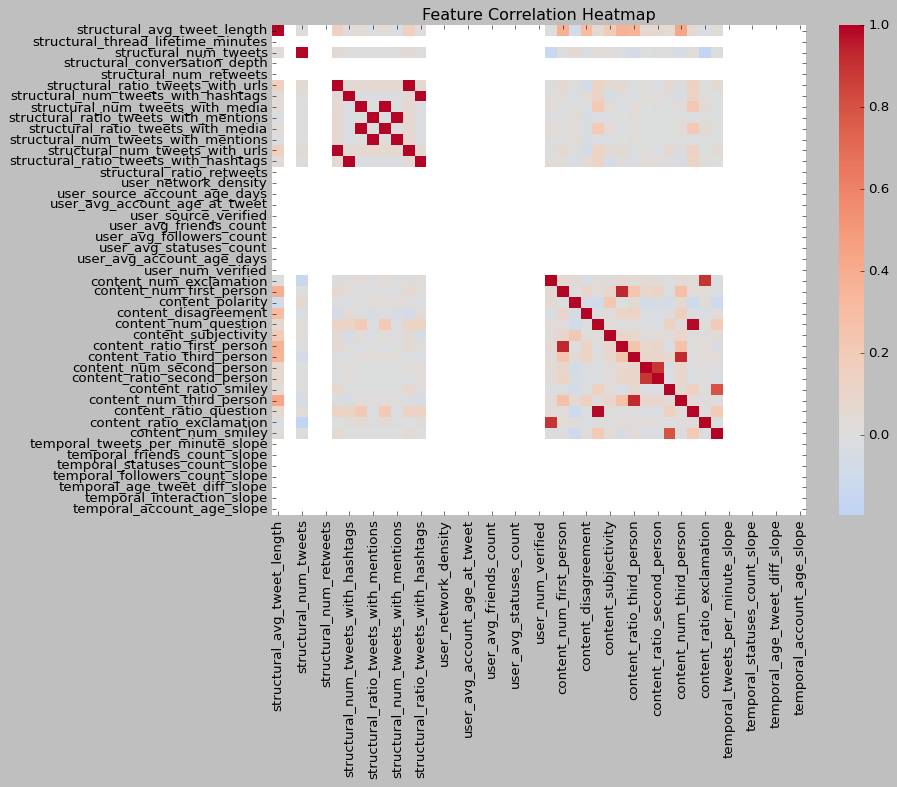

In [ ]:
# Feature Correlation Heatmap
plt.figure(figsize=(12, 10))
feature_cols = [col for col in paper_features_df.columns if col not in ['source', 'label']]
correlation = paper_features_df[feature_cols].corr()
sns.heatmap(correlation, cmap='coolwarm', center=0, annot=False)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()
plt.savefig('data/credbank/feature_correlation.png')
plt.close()

# Train dataset: Creating

Creating:

In [36]:
import os
import pandas as pd
import numpy as np
from typing import Dict, List, Tuple, Any, Union
import warnings

In [37]:
def load_and_combine_datasets(pheme_path: str = 'data/pheme',
                            credbank_path: str = 'data/credbank',
                            output_dir: str = 'data/train',
                            save_csv: bool = True) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Load and combine PHEME and CREDBANK feature datasets.

    Args:
        pheme_path: Path to PHEME dataset directory
        credbank_path: Path to CREDBANK dataset directory
        output_dir: Directory to save output files
        save_csv: Whether to save CSV files

    Returns:
        Tuple of (paper_features_df, all_features_df)
    """
    # Create output directory
    os.makedirs(output_dir, exist_ok=True)

    # Load PHEME features
    print("Loading PHEME features...")
    pheme_paper = pd.read_csv(os.path.join(pheme_path, 'pheme_paper_features.csv'))
    pheme_all = pd.read_csv(os.path.join(pheme_path, 'pheme_all_features.csv'))

    # Load CREDBANK features
    print("\nLoading CREDBANK features...")
    credbank_paper = pd.read_csv(os.path.join(credbank_path, 'credbank_paper_features.csv'))
    credbank_all = pd.read_csv(os.path.join(credbank_path, 'credbank_all_features.csv'))

    # Combine datasets
    print("\nCombining datasets...")
    paper_features_df = pd.concat([pheme_paper, credbank_paper], axis=0, ignore_index=True)
    all_features_df = pd.concat([pheme_all, credbank_all], axis=0, ignore_index=True)

    # Save if requested
    if save_csv:
        # Save paper features
        paper_path = os.path.join(output_dir, 'train_paper.csv')
        paper_features_df.to_csv(paper_path, index=False)
        print(f"Saved paper features to: {paper_path}")

        # Save all features
        complete_path = os.path.join(output_dir, 'train_complete.csv')
        all_features_df.to_csv(complete_path, index=False)
        print(f"Saved complete features to: {complete_path}")

    return paper_features_df, all_features_df

In [38]:
# Load and combine datasets
paper_df, complete_df = load_and_combine_datasets(save_csv=True)

# Print dataset statistics
print("\nDataset Statistics:")
print(f"Paper features shape: {paper_df.shape}")
print(f"Complete features shape: {complete_df.shape}")

# Print source distribution
print("\nSource Distribution:")
print(paper_df['source'].value_counts())

# Print label distribution
print("\nLabel Distribution:")
print(paper_df['label'].value_counts())

Loading PHEME features...

Loading CREDBANK features...

Combining datasets...
Saved paper features to: data/train/train_paper.csv
Saved complete features to: data/train/train_complete.csv

Dataset Statistics:
Paper features shape: (7180, 47)
Complete features shape: (7180, 62)

Source Distribution:
source
pheme       5802
credbank    1378
Name: count, dtype: int64

Label Distribution:
label
0    5207
1    1973
Name: count, dtype: int64


In [39]:
paper_df.head()

,source,label,structural_ratio_tweets_with_mentions,structural_ratio_tweets_with_hashtags,structural_num_tweets_with_urls,structural_num_retweets,structural_conversation_depth,structural_thread_lifetime_minutes,structural_avg_tweet_length,structural_num_tweets,...,content_num_question,content_polarity,content_subjectivity,temporal_age_tweet_diff_slope,temporal_interaction_slope,temporal_friends_count_slope,temporal_followers_count_slope,temporal_tweets_per_minute_slope,temporal_statuses_count_slope,temporal_account_age_slope
0,pheme,1,0.947368,0.000000,5.0,1.0,1.0,75.550000,116.947368,19.0,...,4.0,0.041921,0.225723,0.001336,0.034937,-5.782649e-18,7.497505e-19,0.020620,-2.800992e-19,-3.744899e-18
1,pheme,1,0.875000,0.250000,1.0,1.0,1.0,404.516667,92.750000,8.0,...,0.0,0.156250,0.534375,0.014013,0.002677,-8.618975e-19,-2.119691e-18,0.001941,-1.021417e-18,-1.094542e-18
2,pheme,1,0.857143,0.285714,1.0,0.0,1.0,272.950000,104.714286,7.0,...,0.0,-0.215357,0.536786,0.015463,0.004790,1.334290e-18,-3.483867e-18,0.003798,6.812980e-19,1.826151e-06
3,pheme,1,0.900000,0.500000,4.0,1.0,1.0,1844.233333,103.300000,10.0,...,4.0,0.005863,0.275238,0.002474,0.000495,-2.038172e-19,-5.133670e-19,0.000454,-2.397567e-20,1.908230e-07
4,pheme,1,0.800000,0.400000,3.0,0.0,1.0,22.166667,115.800000,5.0,...,1.0,-0.030000,0.180000,0.194432,0.073144,-1.096397e-16,3.005790e-16,0.044724,9.668537e-17,-9.570538e-17


In [40]:
paper_df.describe()

,label,structural_ratio_tweets_with_mentions,structural_ratio_tweets_with_hashtags,structural_num_tweets_with_urls,structural_num_retweets,structural_conversation_depth,structural_thread_lifetime_minutes,structural_avg_tweet_length,structural_num_tweets,structural_ratio_tweets_with_urls,...,content_num_question,content_polarity,content_subjectivity,temporal_age_tweet_diff_slope,temporal_interaction_slope,temporal_friends_count_slope,temporal_followers_count_slope,temporal_tweets_per_minute_slope,temporal_statuses_count_slope,temporal_account_age_slope
count,7180.000000,7180.000000,7180.000000,7180.000000,7180.000000,7180.0,7180.000000,7180.000000,7180.000000,7180.000000,...,7180.000000,7180.000000,7180.000000,5802.000000,5.802000e+03,5.802000e+03,5.802000e+03,5802.000000,5.802000e+03,5.802000e+03
mean,0.274791,0.692408,0.245305,2.557799,0.103203,1.0,780.829578,88.067226,20.131616,0.208023,...,2.983565,0.038123,0.310246,-0.049748,4.959695e-02,-4.776318e-20,2.024836e-17,0.028633,2.972147e-18,1.057650e-06
std,0.446440,0.393193,0.267509,3.215677,0.419029,0.0,2226.778710,23.196337,18.692349,0.252013,...,6.119146,0.125724,0.143855,2.987695,1.817454e-01,1.517073e-16,1.668046e-15,0.095243,2.816218e-16,2.820528e-05
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000,29.833333,1.000000,0.000000,...,0.000000,-1.000000,0.000000,-193.180511,-1.335579e-16,-4.178877e-15,-3.671131e-14,0.000000,-8.278302e-15,-9.394902e-11
25%,0.000000,0.500000,0.000000,0.000000,0.000000,1.0,3.825000,72.053984,8.000000,0.000000,...,0.000000,-0.022290,0.227911,0.001118,1.303510e-03,-1.298194e-18,-1.585691e-18,0.001014,-1.816189e-18,-7.424559e-19
50%,0.000000,0.900000,0.166667,2.000000,0.000000,1.0,103.491667,91.129167,19.000000,0.111111,...,1.000000,0.034224,0.305412,0.008319,7.010907e-03,0.000000e+00,0.000000e+00,0.005329,0.000000e+00,3.052370e-18
75%,1.000000,0.956522,0.363636,4.000000,0.000000,1.0,520.287500,104.030721,30.000000,0.320645,...,4.000000,0.098944,0.387918,0.028072,2.950078e-02,1.260636e-18,1.832393e-18,0.020896,1.558530e-18,3.044827e-07
max,1.000000,1.000000,1.000000,69.000000,18.000000,1.0,43725.366667,151.000000,346.000000,1.000000,...,184.000000,0.900000,1.000000,2.833310,4.764288e+00,3.858433e-15,1.012685e-13,4.209547,1.351614e-14,1.742393e-03


# Train dataset: Feature Elimination

Recreating "Figure 1" from the paper

In [41]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Tuple
import os
from joblib import dump

In [42]:
def load_dataset(file_path: str) -> Tuple[np.ndarray, np.ndarray, List[str]]:
    """Load and preprocess the dataset."""
    df = pd.read_csv(file_path)
    feature_cols = [col for col in df.columns if col not in ['source', 'label']]
    X = df[feature_cols].fillna(df[feature_cols].median()).values
    y = df['label'].values
    return X, y, feature_cols

def evaluate_feature_set(X: np.ndarray, y: np.ndarray, clf) -> float:
    """Evaluate feature set using 5-fold cross-validation."""
    # Use StratifiedKFold to maintain class distribution
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(clf, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

def recursive_feature_elimination(X: np.ndarray, y: np.ndarray, feature_names: List[str],
                               output_dir: str) -> None:
    """Perform recursive feature elimination with early stopping but continue afterwards."""
    os.makedirs(output_dir, exist_ok=True)
    n_features = X.shape[1]

    # Initialize results tracking
    results = {
        'n_features': [],
        'removed_feature': [],
        'roc_auc': [],
        'remaining_features': [],
        'roc_auc_std': [],
        'phase': []  # Track whether feature was removed before or after early stopping
    }

    # Initialize classifier with fixed parameters
    clf = RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    )

    # Keep track of current feature set
    current_features = list(range(n_features))
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    initial_scores = cross_val_score(clf, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    best_score = initial_scores.mean()
    best_score_std = initial_scores.std()
    best_feature_set = current_features.copy()
    best_classifier = None

    # Save initial state
    clf.fit(X, y)
    dump(clf, f"{output_dir}/initial_classifier.joblib")

    print(f"Initial ROC-AUC with {n_features} features: {best_score:.4f} ± {best_score_std:.4f}")

    early_stopping_triggered = False
    early_stopping_features = None

    # Main elimination loop
    while len(current_features) > 1:
        scores = []
        # Try removing each feature
        for idx in current_features:
            features_without_current = [f for f in current_features if f != idx]
            cv_scores = cross_val_score(clf, X[:, features_without_current], y, cv=cv, scoring='roc_auc', n_jobs=-1)
            scores.append((cv_scores.mean(), cv_scores.std(), idx))

        # Find feature whose removal gives best score
        best_iteration_score, best_iteration_std, worst_feature = max(scores, key=lambda x: x[0])

        # Remove the feature
        current_features.remove(worst_feature)

        # Store results
        results['n_features'].append(len(current_features))
        results['removed_feature'].append(feature_names[worst_feature])
        results['roc_auc'].append(best_iteration_score)
        results['roc_auc_std'].append(best_iteration_std)
        results['remaining_features'].append([feature_names[i] for i in current_features])
        results['phase'].append('pre_stopping' if not early_stopping_triggered else 'post_stopping')

        print(f"Removed: {feature_names[worst_feature]} | ROC-AUC: {best_iteration_score:.4f} ± {best_iteration_std:.4f} | Remaining: {len(current_features)}")

        # Update best score and feature set if improved
        if best_iteration_score > best_score:
            best_score = best_iteration_score
            best_score_std = best_iteration_std
            best_feature_set = current_features.copy()
            # Train and save the best classifier
            clf.fit(X[:, best_feature_set], y)
            best_classifier = clf
            dump(clf, f"{output_dir}/best_classifier.joblib")

        # Early stopping if performance drops significantly
        if best_iteration_score < best_score - 0.01:
            print("Early stopping point reached - saving state")

            # Save early stopping state
            with open(f"{output_dir}/early_stopping_state.txt", 'w') as f:
                f.write(f"Early stopping triggered at {len(current_features)} features\n")
                f.write(f"ROC-AUC at stopping: {best_iteration_score:.4f} ± {best_iteration_std:.4f}\n")
                f.write("\nRemaining features at early stopping:\n")
                f.write('\n'.join([feature_names[i] for i in current_features]))

            # Save classifier at early stopping point
            clf_at_stopping = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
            clf_at_stopping.fit(X[:, current_features], y)
            dump(clf_at_stopping, f"{output_dir}/early_stopping_classifier.joblib")

            # Create plot at early stopping point
            plt.figure(figsize=(12, 6))
            plt.errorbar(results['n_features'], results['roc_auc'],
                        yerr=results['roc_auc_std'], fmt='o-', capsize=5)
            plt.axvline(x=len(current_features), color='r', linestyle='--', label='Early Stopping Point')
            plt.xlabel('Number of Features')
            plt.ylabel('ROC-AUC Score')
            plt.title('Feature Elimination Performance at Early Stopping')
            plt.grid(True)
            plt.legend()
            plt.savefig(f"{output_dir}/early_stopping_plot.png")
            plt.close()

            # Continue with feature elimination instead of breaking
            early_stopping_triggered = True
            early_stopping_features = current_features.copy()

    # Save final results
    results_df = pd.DataFrame(results)
    results_df.to_csv(f"{output_dir}/elimination_results.csv", index=False)

    # Plot 1: ROC-AUC vs Number of Features with confidence intervals and early stopping point
    plt.figure(figsize=(12, 6))
    plt.errorbar(results['n_features'], results['roc_auc'],
                yerr=results['roc_auc_std'], fmt='o-', capsize=5)
    if early_stopping_features:
        plt.axvline(x=len(early_stopping_features), color='r', linestyle='--', label='Early Stopping Point')
    plt.xlabel('Number of Features')
    plt.ylabel('ROC-AUC Score')
    plt.title('Complete Feature Elimination Performance')
    plt.grid(True)
    plt.legend()
    plt.savefig(f"{output_dir}/complete_elimination_plot.png")
    plt.close()

    # Plot 1b: Paper-style plot (similar to Figure 1)
    plt.figure(figsize=(7, 6))
    plt.plot(range(len(results['roc_auc'])-1, -1, -1), results['roc_auc'], '-', color='blue', linewidth=1.5, label='Model Performance')

    # Configure grid
    plt.grid(True, linestyle=':', color='gray', alpha=0.5)
    plt.gca().set_axisbelow(True)  # Put grid behind the plot

    # Configure axes
    plt.xlabel('Deleted Feature Count')
    plt.ylabel('ROC-AUC')

    # Set precise limits and ticks
    plt.ylim(0.62, 0.76)
    plt.xlim(0, 45)
    plt.yticks(np.arange(0.62, 0.77, 0.02))
    plt.xticks(np.arange(0, 46, 5))

    # Remove top and right spines
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    # Adjust legend
    plt.legend(loc='upper right', frameon=False)

    # Save with high DPI and tight layout
    plt.tight_layout()
    plt.savefig(f"{output_dir}/feature_elimination_paper_style.png", dpi=300, bbox_inches='tight')
    plt.close()

    # Plot 2: Feature Removal Impact
    plt.figure(figsize=(15, 8))
    removal_impact = pd.DataFrame({
        'Feature': results['removed_feature'],
        'ROC-AUC': results['roc_auc'],
        'Phase': results['phase']
    })
    sns.barplot(data=removal_impact, x='Feature', y='ROC-AUC', hue='Phase')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(f"{output_dir}/feature_removal_impact_with_phases.png")
    plt.close()

    # Plot 3: Feature Importance of Best Model
    if best_classifier is not None:
        plt.figure(figsize=(12, 6))
        importances = pd.DataFrame({
            'Feature': [feature_names[i] for i in best_feature_set],
            'Importance': best_classifier.feature_importances_
        })
        importances = importances.sort_values('Importance', ascending=False)
        sns.barplot(data=importances, x='Feature', y='Importance')
        plt.xticks(rotation=45, ha='right')
        plt.title('Feature Importance in Best Model')
        plt.tight_layout()
        plt.savefig(f"{output_dir}/feature_importance.png")
        plt.close()

    # Save comprehensive results
    with open(f"{output_dir}/complete_results.txt", 'w') as f:
        f.write("=== Feature Elimination Results ===\n\n")

        f.write("Initial State:\n")
        f.write(f"- Features: {len(feature_names)}\n")
        f.write(f"- Initial ROC-AUC: {np.mean(initial_scores):.4f} ± {np.std(initial_scores):.4f}\n\n")

        if early_stopping_features:
            f.write("Early Stopping Point:\n")
            f.write(f"- Features remaining: {len(early_stopping_features)}\n")
            f.write("- Features at early stopping:\n")
            f.write('\n'.join([feature_names[i] for i in early_stopping_features]) + '\n\n')

        f.write("Best Model:\n")
        f.write(f"- Number of features: {len(best_feature_set)}\n")
        f.write(f"- Best ROC-AUC: {best_score:.4f} ± {best_score_std:.4f}\n")
        f.write("- Best feature set:\n")
        f.write('\n'.join([feature_names[i] for i in best_feature_set]) + '\n\n')

        f.write("Feature Importance in Best Model:\n")
        if best_classifier is not None:
            for feat, imp in zip([feature_names[i] for i in best_feature_set],
                               best_classifier.feature_importances_):
                f.write(f"{feat}: {imp:.4f}\n")

        f.write("\nFinal State:\n")
        f.write(f"- Features remaining: {len(current_features)}\n")
        f.write("- Final features:\n")
        f.write('\n'.join([feature_names[i] for i in current_features]))

In [43]:
print("Starting feature elimination...")
# input_file = "data/train/train_paper.csv"
input_file = "data/pheme/pheme_paper_features.csv"
output_dir = "results/elimination"
X, y, feature_names = load_dataset(input_file)
print(f"Loaded dataset with {X.shape[0]} samples and {X.shape[1]} features")
recursive_feature_elimination(X, y, feature_names, output_dir)

Starting feature elimination...
Loaded dataset with 5802 samples and 45 features
Initial ROC-AUC with 45 features: 0.7343 ± 0.0060
Removed: temporal_friends_count_slope | ROC-AUC: 0.7399 ± 0.0086 | Remaining: 44
Removed: temporal_tweets_per_minute_slope | ROC-AUC: 0.7416 ± 0.0081 | Remaining: 43
Removed: temporal_followers_count_slope | ROC-AUC: 0.7418 ± 0.0065 | Remaining: 42
Removed: temporal_statuses_count_slope | ROC-AUC: 0.7447 ± 0.0065 | Remaining: 41
Removed: content_num_exclamation | ROC-AUC: 0.7462 ± 0.0077 | Remaining: 40
Removed: structural_thread_lifetime_minutes | ROC-AUC: 0.7441 ± 0.0055 | Remaining: 39
Removed: content_num_second_person | ROC-AUC: 0.7466 ± 0.0098 | Remaining: 38
Removed: user_network_density | ROC-AUC: 0.7471 ± 0.0082 | Remaining: 37
Removed: content_ratio_smiley | ROC-AUC: 0.7479 ± 0.0076 | Remaining: 36
Removed: content_ratio_exclamation | ROC-AUC: 0.7482 ± 0.0043 | Remaining: 35
Removed: content_ratio_question | ROC-AUC: 0.7490 ± 0.0063 | Remaining: 3

# BuzzFeed dataset: Loading

In [ ]:
import os
import requests
import zipfile
from tqdm import tqdm

Dataset details:

In [ ]:
# Dataset directory
buzzfeed_dataset_directory = "data/buzzfeed"

# URL for the dataset
buzzfeed_url = "https://zenodo.org/api/records/1239675/files-archive"

# File name to save the dataset
buzzfeed_dataset_path = buzzfeed_dataset_directory + "/archive.zip"

Loading:

In [ ]:
# BuzzFeed dataset: Loading
def backup_and_download_buzzfeed():
    """Download BuzzFeed dataset if not already in Google Drive"""
    gdrive_backup = os.path.join(gdrive_buzzfeed_dir, 'archive.zip')

    # Check if backup exists in Google Drive
    if os.path.exists(gdrive_backup):
        print("Using existing BuzzFeed backup from Google Drive")
        dataset_path = "data/buzzfeed/archive.zip"
        os.makedirs(os.path.dirname(dataset_path), exist_ok=True)
        !cp "{gdrive_backup}" "{dataset_path}"
        return True

    # If no backup exists, download and create backup

    # URL for the dataset
    url = buzzfeed_url

    # File name to save the dataset
    dataset_path = buzzfeed_dataset_path

    # Create directories
    os.makedirs(os.path.dirname(dataset_path), exist_ok=True)

    # Download file with progress bar
    response = requests.get(url, stream=True)
    total_size = int(response.headers.get('content-length', 0))

    with open(dataset_path, "wb") as file, tqdm(
        desc="Downloading BuzzFeed dataset",
        total=total_size,
        unit="B",
        unit_scale=True,
        unit_divisor=1024,
    ) as bar:
        for chunk in response.iter_content(chunk_size=1024):
            size = file.write(chunk)
            bar.update(size)

    # Create backup in Google Drive
    !cp "{dataset_path}" "{gdrive_backup}"
    print("Created backup in Google Drive")
    return True

Downloading from the source or using the backup:

In [ ]:
# Download and process
if backup_and_download_buzzfeed():
    # Proceed with BuzzFeed dataset processing
    pass

Unzipping:

In [ ]:
# Unzip BuzzFeed dataset (main archive)
with zipfile.ZipFile(buzzfeed_dataset_path, 'r') as zip_ref:
    zip_ref.extractall(buzzfeed_dataset_directory)
print("Main BuzzFeed archive extracted successfully!")

In [ ]:
from pathlib import Path

def extract_nested_zips(directory):
    """Extract all zip files found in the given directory"""
    # Get all zip files in the directory
    zip_files = list(Path(directory).rglob('*.zip'))

    for zip_path in zip_files:
        # Skip the original archive.zip
        if zip_path.name == 'archive.zip':
            continue

        # Create extraction directory
        extract_dir = zip_path.parent

        print(f"Extracting: {zip_path.name} -> {extract_dir}")

        # Create directory and extract
        os.makedirs(extract_dir, exist_ok=True)
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_dir)

        # Delete the zip file after extraction
        zip_path.unlink()
        print(f"Deleted: {zip_path.name}")

# Extract all nested zip files
extract_nested_zips(dataset_directory)
print("All nested archives extracted successfully!")

Deleting archive files:

In [ ]:
# Delete BuzzFeed archive
archive_path = 'data/buzzfeed/archive.zip'
if os.path.exists(archive_path):
    os.remove(archive_path)
    print(f"Deleted archive file: {archive_path}")

# BuzzFeed dataset: Requirements

In [ ]:
import json
import os
import pandas as pd
import sweetviz as sv
import numpy as np
from typing import Dict, List, Tuple, Any, Union
from collections import defaultdict
import warnings
import multiprocessing as mp
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor
from tqdm import tqdm
import xml.etree.ElementTree as ET
from utils.features import (
    BuzzFeedStructuralFeatureExtractor,
    BuzzFeedUserFeatureExtractor,
    BuzzFeedContentFeatureExtractor,
    BuzzFeedTemporalFeatureExtractor
)
from utils.dataset_alignment import save_feature_sets

In [ ]:
# Global constants
NUM_PROCESSES = mp.cpu_count()

In [ ]:
# Parses a single XML article file and extracts its content, metadata, and social media reactions
def parse_article_xml(file_path: str) -> Dict:
    """Parse a single XML article file and extract relevant data"""
    try:
        tree = ET.parse(file_path)
        root = tree.getroot()

        article_data = {
            'article_id': os.path.splitext(os.path.basename(file_path))[0],
            'title': root.find('title').text if root.find('title') is not None else '',
            'author': root.find('author').text if root.find('author') is not None else '',
            'orientation': root.find('orientation').text if root.find('orientation') is not None else '',
            'veracity': root.find('veracity').text if root.find('veracity') is not None else '',
            'mainText': root.find('mainText').text if root.find('mainText') is not None else '',
            'uri': root.find('uri').text if root.find('uri') is not None else '',
            'tweet_count': 0,  # Initialize tweet-related fields
            'unique_authors': 0,
            'reaction_texts': [],  # Store tweet replies
            'reaction_authors': [],  # Store authors of replies
            'reaction_timestamps': []  # Store timestamps of replies
        }

        # Extract hyperlinks
        hyperlinks = root.findall('hyperlink')
        article_data['hyperlink_count'] = len(hyperlinks)

        # Extract paragraphs
        paragraphs = root.findall('paragraph')
        article_data['paragraph_count'] = len(paragraphs)

        # Extract Twitter thread data
        twitter_threads = root.findall('twitter_thread')
        if twitter_threads:
            for thread in twitter_threads:
                # Extract tweet replies
                replies = thread.findall('reply')
                for reply in replies:
                    if reply.find('text') is not None:
                        article_data['reaction_texts'].append(reply.find('text').text)
                    if reply.find('author') is not None:
                        article_data['reaction_authors'].append(reply.find('author').text)
                    if reply.find('timestamp') is not None:
                        article_data['reaction_timestamps'].append(reply.find('timestamp').text)

            article_data['tweet_count'] = len(article_data['reaction_texts'])
            article_data['unique_authors'] = len(set(article_data['reaction_authors']))

        return article_data
    except Exception as e:
        print(f"Error processing {file_path}: {str(e)}")
        return None

In [ ]:
# BuzzFeed dataset processor for fake news detection using article and social media features
def load_buzzfeed_dataset_raw(base_path: str = 'data/buzzfeed', output_dir: str = None, save_csv: bool = False) -> pd.DataFrame:
    """Load and process the raw BuzzFeed dataset from XML files.
    Returns the raw dataset structure as a DataFrame.

    Args:
        base_path: Path to the BuzzFeed dataset directory
        output_dir: Directory to save output files (defaults to base_path if None)
        save_csv: Whether to save intermediate CSV files

    Returns:
        DataFrame containing raw article data
    """
    # Use base_path as output_dir if not specified
    output_dir = output_dir or base_path

    # Define paths
    articles_path = os.path.join(base_path, 'articles')

    # Verify paths
    if not os.path.exists(articles_path):
        raise FileNotFoundError(f"Articles directory not found at: {articles_path}")

    print("Loading BuzzFeed dataset from XML files...")

    # Process XML files in parallel
    articles_data = []
    xml_files = [f for f in os.listdir(articles_path) if f.endswith('.xml')]

    with ProcessPoolExecutor(max_workers=NUM_PROCESSES) as executor:
        futures = []
        for xml_file in xml_files:
            file_path = os.path.join(articles_path, xml_file)
            futures.append(executor.submit(parse_article_xml, file_path))

        for future in tqdm(futures, desc="Processing articles"):
            article_data = future.result()
            if article_data:
                articles_data.append(article_data)

    # Convert to DataFrame
    df = pd.DataFrame(articles_data)

    # Save if requested
    if save_csv:
        os.makedirs(output_dir, exist_ok=True)
        output_path = os.path.join(output_dir, 'buzzfeed_raw_dataset.csv')
        df.to_csv(output_path, index=False)
        print(f"Saved raw dataset to: {output_path}")

    return df

In [ ]:
# Processes raw BuzzFeed data into a structured DataFrame with basic article and reaction features
def load_buzzfeed_dataset_extended(raw_dataset: Union[List[Dict], str, None] = None, base_path: str = 'data/buzzfeed', output_dir: str = None, save_csv: bool = False) -> pd.DataFrame:
    """Load and process the BuzzFeed dataset with basic features but without the feature extractors.
    Can either take a raw dataset list or load from a CSV file.

    Args:
        raw_dataset: Either a raw dataset list from load_buzzfeed_dataset_raw or a path to a CSV file
        base_path: Path to the BuzzFeed dataset directory (used if raw_dataset is None)
        output_dir: Directory to save output files (defaults to base_path if None)
        save_csv: Whether to save intermediate CSV files

    Returns:
        DataFrame containing the processed dataset with basic features
    """
    # Use base_path as output_dir if not specified
    output_dir = output_dir or base_path

    if isinstance(raw_dataset, str) and os.path.exists(raw_dataset):
        # Load from specified CSV path
        print(f"Loading extended dataset from CSV: {raw_dataset}")
        return pd.read_csv(raw_dataset)

    if raw_dataset is None:
        raw_dataset = load_buzzfeed_dataset_raw(base_path)

    # Create DataFrame from raw data
    df = pd.DataFrame(raw_dataset)

    # Map veracity values to binary labels
    veracity_map = {
        'mostly true': 'real',
        'mixture of true and false': 'fake',
        'mostly false': 'fake',
        'no factual content': 'fake'
    }
    df['rating'] = df['veracity'].map(veracity_map)

    # Save if requested
    if save_csv:
        os.makedirs(output_dir, exist_ok=True)
        output_path = os.path.join(output_dir, 'buzzfeed_extended_dataset.csv')
        df.to_csv(output_path, index=False)
        print(f"Saved extended dataset to: {output_path}")

    return df

In [ ]:
# Extracts advanced features from BuzzFeed articles using specialized feature extractors
def load_buzzfeed_features_dataset(extended_dataset: Union[pd.DataFrame, str, None] = None, base_path: str = 'data/buzzfeed', output_dir: str = None, save_csv: bool = False, include_additional_features: bool = False) -> pd.DataFrame:
    """Load or create the BuzzFeed features dataset with all feature extractors applied.
    Can either take an extended dataset DataFrame or load from a CSV file.

    Args:
        extended_dataset: Either a DataFrame from load_buzzfeed_dataset_extended or a path to a CSV file
        base_path: Path to the BuzzFeed dataset directory (used if extended_dataset is None)
        output_dir: Directory to save output files (defaults to base_path if None)
        save_csv: Whether to save intermediate CSV files
        include_additional_features: Whether to include additional features

    Returns:
        DataFrame containing only the extracted features, source, and label
    """
    # Use base_path as output_dir if not specified
    output_dir = output_dir or base_path

    if isinstance(extended_dataset, str) and os.path.exists(extended_dataset):
        # Load from specified CSV path
        print(f"Loading features dataset from CSV: {extended_dataset}")
        return pd.read_csv(extended_dataset)

    if extended_dataset is None:
        extended_dataset = load_buzzfeed_dataset_extended(base_path=base_path, output_dir=output_dir, save_csv=save_csv)

    # Add binary label (1 for fake, 0 for real)
    extended_dataset['label'] = (extended_dataset['rating'] == 'fake').astype(int)

    # Extract all features
    df_with_features = extract_all_features(extended_dataset, include_additional_features)

    # Get feature columns
    feature_columns = [col for col in df_with_features.columns if any(
        col.startswith(prefix) for prefix in
        ['structural_', 'user_', 'content_', 'temporal_']
    )]

    # Create features DataFrame
    features_df = df_with_features[feature_columns].copy()
    features_df.insert(0, 'source', 'buzzfeed')
    features_df['label'] = df_with_features['label']

    # Save if requested
    if save_csv:
        os.makedirs(output_dir, exist_ok=True)
        save_feature_sets(features_df, output_dir, 'buzzfeed')

    return features_df

In [ ]:
# Applies all BuzzFeed-specific feature extractors to generate the complete feature set
def extract_all_features(df: pd.DataFrame, include_additional_features: bool = False) -> pd.DataFrame:
    """Extract all BuzzFeed-specific features from the dataset.

    Args:
        df: Input DataFrame
        include_additional_features: Whether to include additional features not in the paper

    Returns:
        DataFrame with all extracted features
    """
    # Make a copy of the input DataFrame to avoid modifying the original
    result_df = df.copy()

    # Initialize feature extractors
    extractors = [
        BuzzFeedStructuralFeatureExtractor(result_df),
        BuzzFeedUserFeatureExtractor(result_df, include_additional_features),
        BuzzFeedContentFeatureExtractor(result_df, include_additional_features),
        BuzzFeedTemporalFeatureExtractor(result_df, include_additional_features)
    ]

    # Apply each extractor and update the DataFrame
    for extractor in extractors:
        # Get features from the current extractor
        updated_df = extractor.extract_features()

        # Add any new columns from the updated DataFrame
        new_columns = set(updated_df.columns) - set(result_df.columns)
        for col in new_columns:
            result_df[col] = updated_df[col]

    return result_df

In [ ]:
# Prepares DataFrame for Sweetviz analysis by converting complex data types to simple ones
def prepare_df_for_analysis(df: pd.DataFrame) -> pd.DataFrame:
    """Prepare DataFrame for Sweetviz analysis by handling complex data types"""
    analysis_df = df.copy()
    for column in analysis_df.columns:
        # Convert list columns to their lengths
        if analysis_df[column].apply(lambda x: isinstance(x, list)).any():
            analysis_df[column] = analysis_df[column].apply(lambda x: len(x) if isinstance(x, list) else x)
        # Convert unhashable types to strings
        elif analysis_df[column].apply(lambda x: isinstance(x, (dict, set))).any():
            analysis_df[column] = analysis_df[column].apply(str)
    return analysis_df

# BuzzFeed dataset: Reading

In [ ]:
# Save and analyze results
output_dir = 'data/buzzfeed'
os.makedirs(output_dir, exist_ok=True)

# Define the output directory in Google Drive
gdrive_buzzfeed_dir = '/content/drive/MyDrive/fake_news/data/buzzfeed'

Reading:

In [ ]:
# Load raw dataset
print("Loading raw dataset...")
raw_df = load_buzzfeed_dataset_raw(output_dir=output_dir, save_csv=True)

In [ ]:
# Load extended dataset
print("\nCreating extended dataset...")
extended_df = load_buzzfeed_dataset_extended(raw_df, output_dir=output_dir, save_csv=True)

In [ ]:
# Extract all features once
print("\nExtracting features...")
all_features_df = load_buzzfeed_features_dataset(extended_df, output_dir=output_dir, save_csv=False, include_additional_features=True)

Saving backups:

In [ ]:
# Save backups to Google Drive
print("\nSaving backups to Google Drive...")

raw_df.to_csv(f"{gdrive_buzzfeed_dir}/buzzfeed_raw_dataset.csv", index=False)
extended_df.to_csv(f"{gdrive_buzzfeed_dir}/buzzfeed_extended_dataset.csv", index=False)
paper_features_df.to_csv(f"{gdrive_buzzfeed_dir}/buzzfeed_paper_features.csv", index=False)
all_features_df.to_csv(f"{gdrive_buzzfeed_dir}/buzzfeed_all_features.csv", index=False)
print(f"Features saved to: {gdrive_buzzfeed_dir}")

Preparing dataset for Sweetviz analysis:

In [ ]:
# Prepare dataset for Sweetviz analysis
analysis_df = prepare_df_for_analysis(all_features_df)

In [ ]:
import sweetviz as sv
sweet_report = sv.analyze(analysis_df)
sweet_report.show_notebook()

In [ ]:
report_path = os.path.join(gdrive_buzzfeed_dir, 'buzzfeed_analysis_report.html')
sweet_report.show_html(report_path)

In [ ]:
print("\nDataset processing complete!")
print(f"Raw dataset components: {len(raw_dataset)}")
print(f"Extended dataset shape: {extended_df.shape}")
print(f"Paper features shape: {paper_features_df.shape}")
print(f"All features shape: {all_features_df.shape}")

# BuzzFeed dataset: Loading Features

Loading raw features:

In [ ]:
# BuzzFeed dataset: Loading RAW dataset
gdrive_buzzfeed_raw_backup = os.path.join(gdrive_buzzfeed_dir, 'buzzfeed_raw_dataset.csv')

# Check if backup exists in Google Drive
if os.path.exists(gdrive_buzzfeed_raw_backup):
    print("Using existing BuzzFeed raw dataset backup from Google Drive")
    dataset_path = "data/buzzfeed/buzzfeed_raw_dataset.csv"
    os.makedirs(os.path.dirname(dataset_path), exist_ok=True)
    !cp "{gdrive_buzzfeed_raw_backup}" "{dataset_path}"

Loading extended features:

In [ ]:
# BuzzFeed dataset: Loading extended dataset
gdrive_buzzfeed_extended_backup = os.path.join(gdrive_buzzfeed_dir, 'buzzfeed_extended_dataset.csv')

# Check if backup exists in Google Drive
if os.path.exists(gdrive_buzzfeed_extended_backup):
    print("Using existing BuzzFeed extended dataset backup from Google Drive")
    dataset_path = "data/buzzfeed/buzzfeed_extended_dataset.csv"
    os.makedirs(os.path.dirname(dataset_path), exist_ok=True)
    !cp "{gdrive_buzzfeed_extended_backup}" "{dataset_path}"

Loading paper features and all features:

In [ ]:
# BuzzFeed dataset: Loading Features
gdrive_buzzfeed_pf_backup = os.path.join(gdrive_buzzfeed_dir, 'buzzfeed_paper_features.csv')
gdrive_buzzfeed_af_backup = os.path.join(gdrive_buzzfeed_dir, 'buzzfeed_all_features.csv')

# Check if backup exists in Google Drive
if os.path.exists(gdrive_buzzfeed_pf_backup):
    print("Using existing BuzzFeed paper features backup from Google Drive")
    dataset_path = "data/buzzfeed/buzzfeed_paper_features.csv"
    os.makedirs(os.path.dirname(dataset_path), exist_ok=True)
    !cp "{gdrive_buzzfeed_pf_backup}" "{dataset_path}"

# Check if backup exists in Google Drive
if os.path.exists(gdrive_buzzfeed_af_backup):
    print("Using existing BuzzFeed all features backup from Google Drive")
    dataset_path = "data/buzzfeed/buzzfeed_all_features.csv"
    os.makedirs(os.path.dirname(dataset_path), exist_ok=True)
    !cp "{gdrive_buzzfeed_af_backup}" "{dataset_path}"

In [ ]:
# Load raw dataset
print("Loading raw dataset...")
raw_df = pd.read_csv('data/buzzfeed/buzzfeed_raw_dataset.csv')

In [ ]:
raw_df.head()

In [ ]:
# Load paper features dataset
print("Loading paper features dataset...")
paper_features_df = pd.read_csv('data/buzzfeed/buzzfeed_paper_features.csv')

In [ ]:
paper_features_df.head()

# Application

Installing flask-ngrok:

In [ ]:
!pip install flask-ngrok

Loading classifier (Run all "Train dataset" cells before this):

In [ ]:
from flask import Flask, request, jsonify
from flask_ngrok import run_with_ngrok
import pandas as pd
import numpy as np
from joblib import load
import os

app = Flask(__name__)
run_with_ngrok(app)

# Load the trained model
model = load('results/elimination/best_classifier.joblib')

In [ ]:
# Load feature names from the original dataset
def get_feature_names():
    # Using the same file path as in feature_elimination.py
    df = pd.read_csv("data/pheme/pheme_paper_features.csv")
    return [col for col in df.columns if col not in ['source', 'label']]

feature_names = get_feature_names()

@app.route('/')
def home():
    return '''
    <h1>Fake News Classification API</h1>
    <p>Use POST /classify with a CSV file and row index to get classification.</p>
    '''

@app.route('/classify', methods=['POST'])
def classify():
    try:
        # Get the CSV file path and row index from the request
        data = request.get_json()
        if not data or 'csv_path' not in data or 'row_index' not in data:
            return jsonify({'error': 'Please provide csv_path and row_index'}), 400

        csv_path = data['csv_path']
        row_index = int(data['row_index'])

        # Check if file exists
        if not os.path.exists(csv_path):
            return jsonify({'error': 'CSV file not found'}), 404

        # Load the CSV file
        df = pd.read_csv(csv_path)

        # Check if row index is valid
        if row_index < 0 or row_index >= len(df):
            return jsonify({'error': 'Invalid row index'}), 400

        # Extract features for the specified row
        row_data = df.iloc[row_index]
        features = row_data[feature_names].fillna(df[feature_names].median())

        # Make prediction
        prediction = model.predict_proba([features])[0]

        # Prepare response
        result = {
            'row_index': row_index,
            'probability_fake': float(prediction[1]),
            'probability_real': float(prediction[0]),
            'classification': 'FAKE' if prediction[1] > 0.5 else 'REAL',
            'confidence': float(max(prediction))
        }

        return jsonify(result)

    except Exception as e:
        return jsonify({'error': str(e)}), 500

Running the application:

In [ ]:
app.run()

To classify a row from a CSV file, send a POST request to the /classify endpoint with JSON data in this format:

In [ ]:
# {
#     "csv_path": "path/to/your/csv/file.csv",
#     "row_index": 0  // The index of the row you want to classify
# }

Example:

In [ ]:
# curl -X POST http://your-ngrok-url/classify \
#      -H "Content-Type: application/json" \
#      -d '{"csv_path": "data/pheme/pheme_paper_features.csv", "row_index": 0}'